# Phần 1: Cài đặt môi trường 


In [1]:
!python -c "import monai" || pip install -qU monai[ignite,nibabel,torchvision,tqdm]
!python -c "import matplotlib" || pip install -q matplotlib
!python -c "import cv2" || pip install opencv-python

Traceback (most recent call last):
  File "<string>", line 1, in <module>
ModuleNotFoundError: No module named 'monai'
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.5/266.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 54.4 MB/s eta 0:00:00


In [2]:
!python -c "import SimpleITK" || pip install -q SimpleITK
!python -c "import medpy" || pip install -q medpy

Traceback (most recent call last):
  File "<string>", line 1, in <module>
ModuleNotFoundError: No module named 'medpy'
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.3/156.3 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import SimpleITK as sitk
import PIL
import cv2
import os
import shutil
import tempfile
from pathlib import Path

In [4]:
## Code to clean kaggle output folders
def remove_folder_contents(folder):
    for the_file in os.listdir(folder):
        file_path = os.path.join(folder, the_file)
        try:
            if os.path.isfile(file_path):
                os.unlink(file_path)
            elif os.path.isdir(file_path):
                #remove_folder_contents(file_path)
                #os.rmdir(file_path)
                continue
        except Exception as e:
            print(e)

### Set Data Directory to where you want all the data and processing artifacts to be

Using Kaggle

In [5]:
%env DATA_DIRECTORY = /kaggle/input

env: DATA_DIRECTORY=/kaggle/input


### Set the Root Directory

In [6]:
directory = os.environ.get("DATA_DIRECTORY")
ROOT_DIR = Path(tempfile.mkdtemp()) if directory is None else Path(directory)
print(ROOT_DIR)

/kaggle/input


In [7]:
def checkPathExists(path):
  if not os.path.exists(path):
    print(f"Cannot access path: {path}")
  else:
    print (f"Path {path} accessible")

# Phần 2: Load dữ liệu ECHONET-DYNAMIC

Get the data and setup the input directories

In [8]:
print(os.listdir('/kaggle/input/datasets'))


['syxlicheng']


In [9]:
print(os.listdir('/kaggle/input/datasets/syxlicheng'))


['heartdatabase']


In [10]:
!find /kaggle/input/datasets/syxlicheng -maxdepth 3 -type d

/kaggle/input/datasets/syxlicheng
/kaggle/input/datasets/syxlicheng/heartdatabase
/kaggle/input/datasets/syxlicheng/heartdatabase/EchoNet-Dynamic
/kaggle/input/datasets/syxlicheng/heartdatabase/EchoNet-Dynamic/Videos


In [11]:
ECHONET_DATA_DIR = 'datasets/syxlicheng/heartdatabase/EchoNet-Dynamic'

In [12]:
import pprint
pp = pprint.PrettyPrinter()
DATA_DIR = ROOT_DIR.joinpath(ECHONET_DATA_DIR)
checkPathExists(DATA_DIR)

Path /kaggle/input/datasets/syxlicheng/heartdatabase/EchoNet-Dynamic accessible


Load the Info files and the volume traced files

In [13]:
INFO_FILE = DATA_DIR.joinpath('FileList.csv')
VOL_TRACE_FILE = DATA_DIR.joinpath('VolumeTracings.csv')
checkPathExists(INFO_FILE)
checkPathExists(VOL_TRACE_FILE)

Path /kaggle/input/datasets/syxlicheng/heartdatabase/EchoNet-Dynamic/FileList.csv accessible
Path /kaggle/input/datasets/syxlicheng/heartdatabase/EchoNet-Dynamic/VolumeTracings.csv accessible


In [14]:
INFO_DF = pd.read_csv(INFO_FILE)
VOL_TRACE_DF = pd.read_csv(VOL_TRACE_FILE)

In [15]:
INFO_DF.head()

,FileName,EF,ESV,EDV,FrameHeight,FrameWidth,FPS,NumberOfFrames,Split
0,0X100009310A3BD7FC,78.498406,14.881368,69.210534,112,112,50,174,VAL
1,0X1002E8FBACD08477,59.101988,40.383876,98.742884,112,112,50,215,TRAIN
2,0X1005D03EED19C65B,62.363798,14.267784,37.909734,112,112,50,104,TRAIN
3,0X10075961BC11C88E,54.545097,33.143084,72.914210,112,112,55,122,TRAIN
4,0X10094BA0A028EAC3,24.887742,127.581945,169.855024,112,112,52,207,VAL


In [16]:
VOL_TRACE_DF.head()

,FileName,X1,Y1,X2,Y2,Frame
0,0X100009310A3BD7FC.avi,51.260417,15.348958,64.932292,69.125000,46
1,0X100009310A3BD7FC.avi,50.037611,17.167841,53.367222,16.321330,46
2,0X100009310A3BD7FC.avi,49.157378,20.407629,57.090549,18.390722,46
3,0X100009310A3BD7FC.avi,48.538173,23.581055,59.997339,20.667707,46
4,0X100009310A3BD7FC.avi,47.918968,26.754480,62.904129,22.944693,46


In [17]:
INFO_DF.Split.value_counts()

Split
TRAIN    7465
VAL      1288
TEST     1277
Name: count, dtype: int64

# PHẦN 3 — TIỀN XỬ LÝ: TRÍCH XUẤT FRAME ED VÀ ES TỪ VIDEO

In [18]:
## To extract the ED and ES frame from the video file
def extractEDandESframes(image_file, ED_frame_number, ES_frame_number):
    video = cv2.VideoCapture(str(image_file))
    frame_count = int(video.get(cv2.CAP_PROP_FRAME_COUNT))
    ## Retrieve the ED frame
    for i in range(ED_frame_number-1):
        ret, frame = video.read() #ret= true/false của việc ghi lại frame 
    res, ED_frame = video.read()
    ## Retrieve the ES frame
    diff = ES_frame_number - ED_frame_number
    for i in range(diff):
        ret, frame = video.read()
    res1, ES_frame = video.read()
    if not res:
        print("issue ED")
    if not res1:
        print("issue ES")
    if res&res1:
        return ED_frame, ES_frame
    else:
        return None, None



### Hàm `extractEDandESframes`

**Mục đích:** Trích xuất 2 khung hình ED (Cuối tâm trương) và ES (Cuối tâm thu) từ một file video siêu âm tim.

**Đầu vào:** Đường dẫn file video, số thứ tự frame ED, số thứ tự frame ES- (image_file, ED_frame_number, ES_frame_number).

**Đầu ra:** Hai bức ảnh (dạng ma trận numpy) tương ứng với khung hình ED và ES. Trả về `(None, None)` nếu đọc video thất bại.

**Cách hoạt động:**
1. Mở file video bằng `cv2.VideoCapture`. Lúc này con trỏ video đang ở vị trí đầu tiên (frame 0).
2. Dùng vòng lặp gọi `video.read()` lặp lại `ED_frame_number - 1` lần để bỏ qua các frame phía trước, sau đó đọc frame tiếp theo chính là **ảnh ED** cần lấy.
3. Tính khoảng cách `diff = ES_frame_number - ED_frame_number`, tiếp tục lặp `diff` lần để bỏ qua các frame nằm giữa ED và ES, sau đó đọc frame tiếp theo chính là **ảnh ES** cần lấy.
4. Kiểm tra trạng thái đọc. Nếu cả hai lần đọc đều thành công thì trả về cặp ảnh `(ED_frame, ES_frame)`, ngược lại trả về `(None, None)`.




In [19]:
## Save the ED and ES frame as a png which is prefixed with the original avi file name
## Save a csv file name is the same as orginal avi file name,that has the volume 
## tracings for both the ES and ED file
## the csv file also has a column with Image file name, and the Split value
## from the original file list.
def saveEDandESimages(data_dir, output_dir, info_df, trace_df):
    patient_list = [x for x in data_dir.iterdir()]

    for i, file in enumerate(patient_list):
        patient_id = file.name.split('.')[0]
        frame_df = trace_df.query(f"FileName == '{file.name}'")
        try:
            unique_frames = frame_df.Frame.unique()
            if len(unique_frames) != 2:
                print(f"Skipping {file.name}: expected 2 frames (ED+ES), got {len(unique_frames)} → {unique_frames}")
                continue
            ed_number, es_number = unique_frames
        except Exception as e:
            print(f"This {file} generated an error")
            continue
        iED_path = output_dir.joinpath(f"{patient_id}_ED.png")
        if iED_path.exists():
            continue
        split_value = info_df.query(f"FileName == '{patient_id}'").Split
        #print(ed_number, es_number)
        ED_frame, ES_frame = extractEDandESframes(file, ed_number, es_number)
        if ED_frame is not None or ES_frame is not None:
            ## Write the ED and ES frames as images
            iED_path = output_dir.joinpath(f"{patient_id}_ED.png")
            iES_path = output_dir.joinpath(f"{patient_id}_ES.png")
            cv2.imwrite(str(iED_path), ED_frame)
            cv2.imwrite(str(iES_path), ES_frame)
            ## Write the trac points into a csv file
            ED_info = frame_df.query(f'FileName =="{file.name}" and Frame == {ed_number}').reset_index(drop=True)
            ES_info = frame_df.query(f'FileName =="{file.name}" and Frame == {es_number}').reset_index(drop=True)
            ES_info = frame_df.query(f'FileName =="{file.name}" and Frame == {es_number}').reset_index(drop=True)
            ED_stack = np.hstack(ED_info[['X1', 'Y1', 'X2', 'Y2']].values).tolist()
            ES_stack = np.hstack(ES_info[['X1', 'Y1', 'X2', 'Y2']].values).tolist()
            keypoint_df = pd.DataFrame([ED_stack, ES_stack])
            keypoint_df['Image'] = [f"{patient_id}_ED.png", f"{patient_id}_ES.png"]
            keypoint_df['Split'] = [split_value.iloc[0], split_value.iloc[0]]
            keypoint_df.to_csv(output_dir.joinpath(f"{patient_id}.csv"), index=False)
        else:
            print(f"There was an issue with processing {file}")



### Hàm `saveEDandESimages`

**Mục đích:** Xử lý hàng loạt (batch process) các video siêu âm tim. Trích xuất hình ảnh ED/ES và tự động tổng hợp tọa độ đường viền (trace points) của chúng, sau đó lưu tất cả vào một thư mục mới để chuẩn bị cho việc huấn luyện mô hình (Training).

**Đầu vào:**
- `data_dir`: Đường dẫn thư mục chứa các file video siêu âm tim gốc.
- `output_dir`: Đường dẫn thư mục đích để lưu ảnh và file tọa độ sau khi xử lý.
- `info_df`: Bảng dữ liệu (DataFrame) chứa thông tin danh sách video, chủ yếu dùng để lấy thông tin phân tập dữ liệu (cột Split: TRAIN/VAL/TEST).
- `trace_df`: Bảng dữ liệu (DataFrame) chứa tọa độ gán nhãn đường viền (X1, Y1, X2, Y2) của các video.

**Đầu ra:**
Hàm không có giá trị trả về trực tiếp, nhưng tạo ra các file thực tế trong thư mục `output_dir` bao gồm:
- Các file ảnh `.png` cho pha ED và ES (ví dụ: `0X100..._ED.png`).
- Các file `.csv` (ví dụ: `0X100...csv`) chứa dữ liệu tọa độ đường viền của 2 bức ảnh trên và nhãn tập dữ liệu (TRAIN/VAL/TEST).
- 
VD:

        0X107458C8895A9AC9.csv
        0X107458C8895A9AC9_ED.png
        0X107458C8895A9AC9_ES.png
  
**Cách hoạt động:**
1. Đọc danh sách toàn bộ các file video trong thư mục `data_dir` và lặp qua từng file (mỗi file đại diện cho 1 bệnh nhân).
2. Với mỗi file, tra cứu trong `trace_df` để tìm ra số thứ tự frame ED và ES tương ứng. Nếu dữ liệu bị lỗi hoặc thiếu, in ra cảnh báo và bỏ qua video đó.
3. Gọi hàm `extractEDandESframes` để trích xuất 2 bức ảnh (ED và ES). 
4. Nếu trích xuất thành công, sử dụng `cv2.imwrite` để lưu 2 bức ảnh đó thành file `.png`.
5. Lọc lấy tọa độ điểm lưới (X1, Y1, X2, Y2) của frame ED và ES từ `trace_df`, gộp (stack) chúng lại thành một bảng dữ liệu mới, bổ sung thêm tên ảnh và nhãn phân tập (Split), rồi xuất ra file `.csv` lưu cùng chỗ với 2 bức ảnh.


In [20]:
VIDEO_DIR = DATA_DIR.joinpath('Videos')
OUTPUT_DIR = Path('/kaggle/working/Output')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
checkPathExists(OUTPUT_DIR)

Path /kaggle/working/Output accessible


In [21]:
saveEDandESimages(VIDEO_DIR, OUTPUT_DIR, INFO_DF, VOL_TRACE_DF)

Skipping 0X6C435C1B417FDE8A.avi: expected 2 frames (ED+ES), got 0 → []
Skipping 0X234005774F4CB5CD.avi: expected 2 frames (ED+ES), got 0 → []
Skipping 0X2DC68261CBCC04AE.avi: expected 2 frames (ED+ES), got 0 → []
Skipping 0X5515B0BD077BE68A.avi: expected 2 frames (ED+ES), got 0 → []
Skipping 0X35291BE9AB90FB89.avi: expected 2 frames (ED+ES), got 0 → []
Skipping 0X5DD5283AC43CCDD1.avi: expected 2 frames (ED+ES), got 0 → []


# PHẦN 4 — TRỰC QUAN HÓA DỮ LIỆU THÔ

56.0


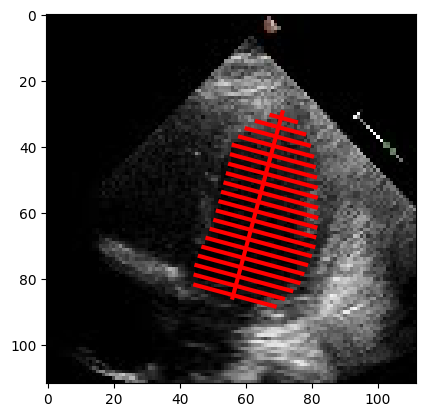

In [22]:
NUM_KEYPOINTS = 84
trace_df = pd.read_csv(OUTPUT_DIR.joinpath('0XB5CECBD29920B7B.csv'))
arr = PIL.Image.open(str(OUTPUT_DIR.joinpath('0XB5CECBD29920B7B_ED.png')))
plt.imshow(arr)
df = trace_df.query('Image == "0XB5CECBD29920B7B_ED.png"')
print(df.iloc[0,0])
for i in range(0, NUM_KEYPOINTS, 4):
    x1, y1 = df.iloc[0,i], df.iloc[0,i+1]
    x2, y2 = df.iloc[0,i+2], df.iloc[0,i+3]
    plt.plot([x1, x2], [y1, y2], color='red', linewidth=3)
plt.show()

In [23]:
trace_df

,0,1,2,3,4,5,6,7,8,9,...,76,77,78,79,80,81,82,83,Image,Split
0,56.000000,85.531250,71.130208,29.385417,67.796322,30.284437,75.205312,32.281015,63.388392,32.13038,...,44.798181,78.695195,71.267747,85.828228,44.697955,81.701981,68.745499,88.182326,0XB5CECBD29920B7B_ED.png,TRAIN
1,53.447917,84.255208,68.031250,27.927083,64.783133,28.605878,72.119858,30.505354,61.401818,30.76992,...,43.705044,77.859099,66.272263,83.701744,43.435083,80.828669,64.406727,86.258220,0XB5CECBD29920B7B_ES.png,TRAIN


### Kết quả hiển thị

Hình ảnh hiển thị một **khung hình siêu âm tim pha ED** (Cuối tâm trương — khi buồng tim giãn ra to nhất) của bệnh nhân `0XB5CECBD29920B7B`.

Trên nền ảnh siêu âm màu xám đen, có **21 đoạn thẳng màu đỏ** được vẽ chồng lên nhau, xếp song song và sát nhau tạo thành hình dạng giống **lá cây** hay **quả bóng bầu dục**. Đây chính là **đường viền gán nhãn thủ công (ground truth)** của tâm thất trái, thể hiện hình dạng và kích thước của buồng tim tại thời điểm ED.

Số `56.0` hiển thị phía trên ảnh là giá trị tọa độ đầu tiên trong hàng dữ liệu được đọc ra từ file `.csv`.



# PHẦN 5 — LOAD DỮ LIỆU CHO MODEL

### Build a Key Point Detection Model

In [24]:
# Models 
from keras.models import Model
from tensorflow.keras.applications import MobileNetV2, mobilenet_v2
from keras.layers import Input, Dropout, SeparableConv2D, Dense, Flatten

2026-05-10 00:45:58.843656: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778373959.073753      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778373959.143955      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778373959.682550      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778373959.682592      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778373959.682594      23 computation_placer.cc:177] computation placer alr

In [25]:
import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))
print("TF Version:", tf.__version__)


GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
TF Version: 2.19.0


=== THỐNG KÊ SỐ ĐOẠN THẲNG PER FRAME ===
Nhỏ nhất : 16 đoạn → 64 keypoints
Lớn nhất : 168 đoạn → 672 keypoints
Phổ biến nhất: 21 đoạn → 84 keypoints

=== PHÂN PHỐI SỐ ĐOẠN THẲNG ===
num_segments
16         1
18         1
21     19942
41         1
42        49
63        38
84        14
105        2
147        1
168        1
Name: count, dtype: int64


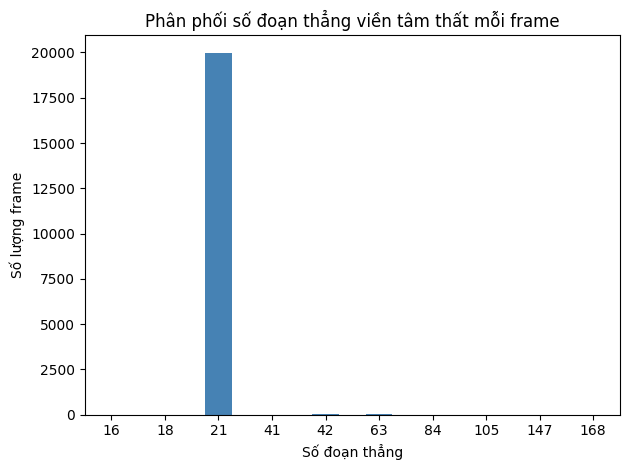

In [26]:
import matplotlib.pyplot as plt

# Đếm số đoạn thẳng (rows) cho mỗi cặp (FileName, Frame)
keypoint_counts = VOL_TRACE_DF.groupby(['FileName', 'Frame']).size().reset_index(name='num_segments')

# Thống kê tổng quan
print("=== THỐNG KÊ SỐ ĐOẠN THẲNG PER FRAME ===")
print(f"Nhỏ nhất : {keypoint_counts['num_segments'].min()} đoạn → {keypoint_counts['num_segments'].min() * 4} keypoints")
print(f"Lớn nhất : {keypoint_counts['num_segments'].max()} đoạn → {keypoint_counts['num_segments'].max() * 4} keypoints")
print(f"Phổ biến nhất: {keypoint_counts['num_segments'].mode()[0]} đoạn → {keypoint_counts['num_segments'].mode()[0] * 4} keypoints")
print()

# Xem phân phối chi tiết
print("=== PHÂN PHỐI SỐ ĐOẠN THẲNG ===")
print(keypoint_counts['num_segments'].value_counts().sort_index())

# Vẽ biểu đồ
keypoint_counts['num_segments'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Phân phối số đoạn thẳng viền tâm thất mỗi frame')
plt.xlabel('Số đoạn thẳng')
plt.ylabel('Số lượng frame')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Căn cứ xác định NUM_KEYPOINTS = 84
Dựa vào kết quả thống kê phân phối số lượng đoạn thẳng trên mỗi khung hình (frame), việc thiết lập hằng số NUM_KEYPOINTS = 84 được lý giải như sau:

1. Đặc trưng phân bố của tập dữ liệu: Biểu đồ cho thấy sự áp đảo tuyệt đối ở mức 21 đoạn thẳng. Cụ thể, trong khoảng 20.050 frames của toàn bộ tập dữ liệu, có tới 19.942 frames (chiếm ~99.5%) được gán nhãn ground-truth bằng đúng 21 đoạn thẳng. Các trường hợp gán nhãn khác (16, 42, 63 đoạn...) là các nhiễu (outliers) chiếm tỷ lệ không đáng kể.

2. Tính toán kích thước đầu ra: Mỗi đoạn thẳng được cấu thành từ 2 điểm đầu mút, tương ứng với 4 giá trị tọa độ không gian (x1, y1, x2, y2). Do đó, tổng số lượng tọa độ cần thiết để vẽ hoàn chỉnh 21 đoạn thẳng là: 21 đoạn thẳng × 4 tọa độ/đoạn = 84 keypoints (tọa độ).

Kết luận: Để huấn luyện mô hình Deep Learning một cách ổn định, cấu trúc đầu ra (output shape) cần phải cố định. Việc chọn NUM_KEYPOINTS = 84 chính là bước chuẩn hóa đầu ra, ép mô hình luôn dự đoán ra một vector có đúng 84 phần tử (đại diện cho 21 đoạn thẳng phổ biến nhất) cho bất kỳ ảnh siêu âm đầu vào nào.

In [27]:
NUM_KEYPOINTS=84
IMAGE_SIZE = 112
OUTPUT_DIR = Path('/kaggle/working/Output')
EPOCHS=50



### Các tham số cấu hình hệ thống (Hyperparameters)

Đây là các thông số nền tảng giúp định hình cấu trúc mô hình và quy trình huấn luyện, được tối ưu hóa để cân bằng giữa độ chính xác và hiệu suất máy tính:

*   **`NUM_KEYPOINTS = 84`**: Xác định kích thước đầu ra của mô hình. Con số 84 đại diện cho 21 cặp đoạn thẳng (mỗi đoạn 4 tọa độ) cấu thành nên đường viền tâm thất, dựa trên số liệu thống kê phổ biến nhất từ tập dữ liệu EchoNet.
*   **`IMAGE_SIZE = 112`**: Kích thước chuẩn hóa của ảnh đầu vào (112x112 pixel). 
*   **`OUTPUT_DIR`**: Đường dẫn lưu trữ dữ liệu đã qua xử lý. Đây là nguồn dữ liệu "sạch" mà mô hình sẽ trực tiếp truy cập trong quá trình học.
*   **`EPOCHS = 50`**: Số chu kỳ huấn luyện. Mức 50 được chọn làm mốc cơ sở để đảm bảo mô hình có đủ thời gian hội tụ và học được các đặc điểm phức tạp của hình ảnh siêu âm mà không gây ra hiện tượng quá mức (overfitting).



In [28]:
## Load all the images and the keypoints
def LoadData(input_dir, type='TRAIN'):
    all_images = []
    all_points = []
    all_ids = []
    for j, p in enumerate(input_dir.glob(f"*.csv")):
        df = pd.read_csv(p)
        try:
            df_type = df.Split.unique()[0]
        except AttributeError:
            print(df)
            break
        if df_type == type:
            for i, x in enumerate(df.Image):
                img = PIL.Image.open(input_dir.joinpath(x))
                #plt.imshow(img)
                #plt.show()
                v = df.iloc[i][:NUM_KEYPOINTS]
                if len(v) != 84:
                    continue
                all_points.append(v)
                img = cv2.resize(np.asarray(img), (IMAGE_SIZE, IMAGE_SIZE))
                all_images.append(img)
                all_ids.append(p.name.split('.')[0])
    all_images = np.asarray(all_images)
    all_points = np.asarray(all_points)
    all_points = all_points.reshape(-1, 1, 1, NUM_KEYPOINTS) / IMAGE_SIZE
    all_ids = np.asarray(all_ids)
    return all_images, all_points, all_ids



### Hàm `LoadData`

**Mục đích:**
Hàm này dùng để thu thập và chuẩn bị dữ liệu từ ổ cứng vào bộ nhớ hệ thống. Nó thực hiện việc đọc ảnh và các điểm tọa độ tương ứng, sau đó định dạng lại chúng sao cho phù hợp nhất với yêu cầu đầu vào của mô hình Deep Learning (MobileNetV2).

**Đầu vào:**
*   **`input_dir`**: Đường dẫn đến thư mục chứa các file ảnh (.png) và file tọa độ (.csv) đã được xử lý ở bước trước.
*   **`type`**: Nhãn phân loại dữ liệu muốn tải lên (mặc định là `'TRAIN'`, có thể chọn `'VAL'` hoặc `'TEST'`). Việc này giúp tải riêng biệt dữ liệu để huấn luyện hoặc để kiểm tra.

**Đầu ra:**
Hàm trả về một bộ gồm 3 mảng dữ liệu:
*   **`all_images`**: Mảng chứa các hình ảnh đã được resize về kích thước chuẩn (112x112).
*   **`all_points`**: Mảng chứa các tọa độ keypoints đã được **chuẩn hóa** (giá trị nằm trong khoảng từ 0 đến 1) và được **reshape** về dạng 4 chiều để đưa vào mô hình.
*   **`all_ids`**: Mảng chứa mã định danh (ID) của từng bệnh nhân để dễ dàng đối chiếu.

**Cách hoạt động:**
Hàm thực hiện theo quy trình 4 bước:
1.  **Quét file:** Tìm kiếm tất cả các file `.csv` trong thư mục đầu vào. Mỗi file CSV đại diện cho dữ liệu của một bệnh nhân.
2.  **Lọc dữ liệu:** Kiểm tra cột `Split` trong file CSV. Nếu giá trị khớp với tham số `type` (ví dụ: cùng là 'TRAIN'), hàm mới tiến hành xử lý tiếp.
3.  **Xử lý hình ảnh và tọa độ:**
    *   Mở file ảnh và dùng thư viện OpenCV để thay đổi kích thước về 112x112 pixel.
    *   Trích xuất đúng 84 giá trị tọa độ.
    *   **Chuẩn hóa:** Chia tất cả tọa độ cho 112 để đưa dữ liệu về khoảng [0, 1], giúp mô hình học ổn định hơn.
4.  **Đóng gói:** Chuyển đổi toàn bộ danh sách ảnh và tọa độ sang dạng mảng Numpy (`np.array`) để tối ưu hóa hiệu suất tính toán.



In [29]:
train_images, train_keypoints, train_ids = LoadData(OUTPUT_DIR)
pp.pprint(train_images.shape)
pp.pprint(train_keypoints.shape)
train_keypoints_conv = train_keypoints.astype('float32')

(14918, 112, 112, 3)
(14918, 1, 1, 84)




**1. Dòng đầu tiên:** `(14918, 112, 112, 3)`
Đây là hình dạng (shape) của mảng chứa **Ảnh huấn luyện** (`train_images`):
*   **14.918**: Tổng số lượng ảnh đã được tải lên để huấn luyện.
*   **112, 112**: Kích thước mỗi ảnh là 112x112 pixel (đúng như cấu hình `IMAGE_SIZE`).
*   **3**: Số kênh màu (ảnh RGB có 3 kênh màu: Đỏ, Xanh lá, Xanh dương).

**2. Dòng thứ hai** `(14918, 1, 1, 84)`
Đây là hình dạng (shape) của mảng chứa **Tọa độ nhãn** (`train_keypoints`):
*   **14.918**: Tương ứng với 14.918 ảnh ở trên (mỗi ảnh phải có 1 bộ nhãn tọa độ).
*   **84**: Số lượng điểm tọa độ cho mỗi ảnh (đúng như cấu hình `NUM_KEYPOINTS = 84`).
*   **1, 1**: Đây là các chiều "giả" được thêm vào do lệnh `reshape` trong hàm `LoadData`. Việc này nhằm mục đích biến mảng tọa độ thành một khối dữ liệu 4 chiều để khớp chính xác với yêu cầu kỹ thuật của mô hình AI mà bạn đang sử dụng.


In [30]:
def VisualizeSampleImages(image, kps, col='red'):
    plt.imshow(image)
    for i in range(0, NUM_KEYPOINTS, 4):
        x1, y1 = kps[0,i], kps[0,i+1]
        x2, y2 = kps[0,i+2], kps[0,i+3]
        plt.plot([x1, x2], [y1, y2], color=col, linewidth=2)
    #plt.show()


### Hàm `VisualizeSampleImages`

**Mục đích:**
Hàm này được sử dụng để trực quan hóa và kiểm tra dữ liệu. Mục tiêu chính là vẽ các đường viền tọa độ (keypoints) trực tiếp lên hình ảnh siêu âm tim, giúp người dùng xác minh xem các nhãn dữ liệu có khớp chính xác với cấu trúc thực tế của tâm thất trái hay không.

**Đầu vào:**
*   **`image`**: Mảng dữ liệu pixel của một bức ảnh siêu âm (thường lấy từ tập dữ liệu đã nạp).
*   **`kps`**: Mảng chứa các tọa độ điểm nút (keypoints) tương ứng với bức ảnh đó.
*   **`col`**: Màu sắc của các đoạn thẳng sẽ được vẽ trên ảnh (mặc định là `'red'` - màu đỏ).

**Đầu ra:**
Hàm không trả về dữ liệu số mà thực hiện hiển thị trực tiếp một hình ảnh đồ họa thông qua thư viện `matplotlib`. Kết quả là một bức ảnh tim có các đường kẻ màu đỏ bao quanh viền tâm thất.

**Cách hoạt động:**
Hàm thực hiện theo quy trình 3 bước:
1.  **Vẽ ảnh nền:** Sử dụng lệnh `plt.imshow` để hiển thị bức ảnh siêu âm tim làm lớp nền.
2.  **Trích xuất tọa độ:** Sử dụng vòng lặp duyệt qua danh sách keypoints. Với mỗi nhóm 4 giá trị, hàm xác định tọa độ của hai điểm đầu mút `(x1, y1)` và `(x2, y2)` để tạo thành một đoạn thẳng.
3.  **Vẽ đường viền:** Sử dụng lệnh `plt.plot` để nối các điểm đã trích xuất. Quá trình này lặp lại cho đến khi tất cả các đoạn thẳng được vẽ xong, tạo thành một khung viền bao quanh tâm thất, giúp người dùng dễ dàng quan sát sự tương quan giữa tọa độ và hình ảnh thực tế.

---

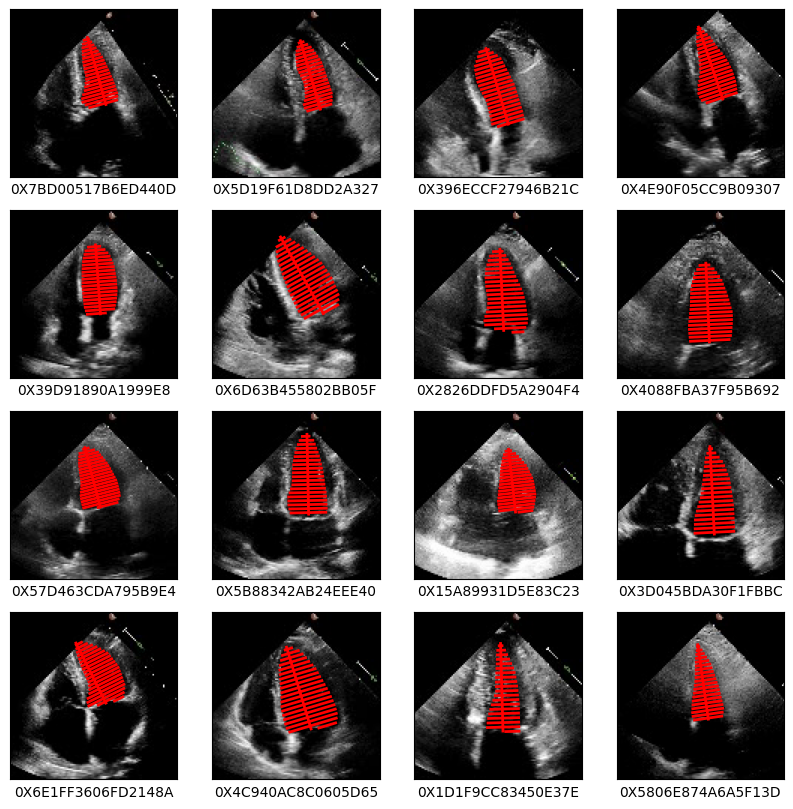

In [31]:
plt.subplots(4, 4, figsize=(10,10))
num_total = train_images.shape[0]
for i, k in enumerate(np.random.randint(num_total, size=16)):
    kps = train_keypoints_conv[k].reshape(-1, NUM_KEYPOINTS) * IMAGE_SIZE
    image = train_images[k]
    plt.subplot(4, 4, i+1)
    plt.gca().set_yticklabels([])
    plt.gca().set_xticklabels([])
    plt.gca().set_xticks([])
    plt.gca().set_yticks([])
    VisualizeSampleImages(image, kps)
    plt.xlabel(train_ids[k])

In [32]:
def VisualizeInstanceData(data_images, data_keypoints, data_ids, ED_index, ES_index):
    print(f"Data id {data_ids[ED_index]}")
    plt.subplots(1, 2, figsize=(8, 8))
    plt.subplot(1, 2, 1)
    img = data_images[ED_index]
    kps = data_keypoints[ED_index].reshape(-1,NUM_KEYPOINTS) * IMAGE_SIZE
    plt.gca().set_yticklabels([])
    plt.gca().set_xticklabels([])
    plt.gca().set_xticks([])
    plt.gca().set_yticks([])
    VisualizeSampleImages(img, kps)
    plt.xlabel("ED image")
    plt.subplot(1, 2, 2)
    img = data_images[ES_index]
    kps = data_keypoints[ES_index].reshape(-1,NUM_KEYPOINTS) * IMAGE_SIZE
    plt.gca().set_yticklabels([])
    plt.gca().set_xticklabels([])
    plt.gca().set_xticks([])
    plt.gca().set_yticks([])
    VisualizeSampleImages(img, kps)
    plt.xlabel("ES image")

### Hàm `VisualizeInstanceData`

**Mục đích:**
Hàm này dùng để hiển thị trực quan dữ liệu của một ca cụ thể (instance), bao gồm cả hai trạng thái quan trọng của tim: cuối tâm trương (ED - End-Diastolic) và cuối tâm thu (ES - End-Systolic) cạnh nhau để dễ dàng so sánh và kiểm tra độ chính xác của các điểm đánh dấu (keypoints).

**Đầu vào:**
*   **`data_images`**: Mảng chứa danh sách các hình ảnh siêu âm tim đã tải.
*   **`data_keypoints`**: Mảng chứa tọa độ các điểm keypoints tương ứng (đang ở dạng chuẩn hóa từ 0 đến 1).
*   **`data_ids`**: Mảng chứa mã định danh (ID) của bệnh nhân hoặc ca dữ liệu.
*   **`ED_index`**: Vị trí (chỉ số) của khung hình ED trong mảng dữ liệu.
*   **`ES_index`**: Vị trí (chỉ số) của khung hình ES trong mảng dữ liệu.

**Đầu ra:**
*   Hàm in ra màn hình mã ID của ca đang xem.
*   Hiển thị một biểu đồ gồm 2 hình ảnh nằm ngang: bên trái là khung hình ED và bên phải là khung hình ES, cả hai đều được vẽ đè các đường bao (keypoints) lên trên.

**Cách hoạt động:**
1.  **Xác định danh tính**: In ra ID của dữ liệu dựa trên chỉ số `ED_index`.
2.  **Khởi tạo khung vẽ**: Tạo một vùng hiển thị chia làm 2 cột (`subplots(1, 2)`).
3.  **Xử lý khung hình ED**:
    *   Lấy ảnh và các điểm tương ứng tại vị trí `ED_index`.
    *   Chuyển đổi tọa độ keypoints từ dạng chuẩn hóa về dạng pixel thực tế bằng cách nhân với `IMAGE_SIZE`.
    *   Xóa các vạch chia tọa độ (ticks/labels) trên trục X và Y để hình ảnh sạch sẽ hơn.
    *   Gọi hàm `VisualizeSampleImages` đã viết trước đó để vẽ ảnh và các đoạn thẳng nối các điểm keypoints.
    *   Đặt nhãn phía dưới là "ED image".
4.  **Xử lý khung hình ES**: Lặp lại các bước tương tự như trên nhưng sử dụng dữ liệu tại vị trí `ES_index` và đặt nhãn là "ES image".

The following ids have incorrect volume traces and will be removed\
0X354B37A25C64276F\
0X973E4A9DAADDF9F\
0X37F9E9981E207C04\
0X766B7B0ABDB07CD5\
0X5B6FCBB75BF8FCB7\
0X36C5A15AC7FC6AAA\
0X4BBA9C8FB485C9AB\
0X49EC1927F5747B19\
0X5D38D994C2490EAE\
0X53C185263415AA4F\
0X65E605F203321860\
0X753AA26EA352BBB

In [33]:
train_error_list = ['0X354B37A25C64276F','0X973E4A9DAADDF9F','0X37F9E9981E207C04','0X766B7B0ABDB07CD5',
'0X5B6FCBB75BF8FCB7','0X36C5A15AC7FC6AAA','0X4BBA9C8FB485C9AB','0X49EC1927F5747B19','0X5D38D994C2490EAE',
'0X53C185263415AA4F','0X65E605F203321860','0X753AA26EA352BBB']

In [34]:
error_indices = [np.where(train_ids == inst)[0].tolist() for inst in train_error_list]
#flat_list = list(np.concatenate(x).flat)
print(error_indices)

[[13144, 13145], [4358, 4359], [2356, 2357], [11528, 11529], [12070, 12071], [1392, 1393], [6738, 6739], [1304, 1305], [14782, 14783], [1286, 1287], [12474, 12475], [10400, 10401]]


Data id 0X354B37A25C64276F


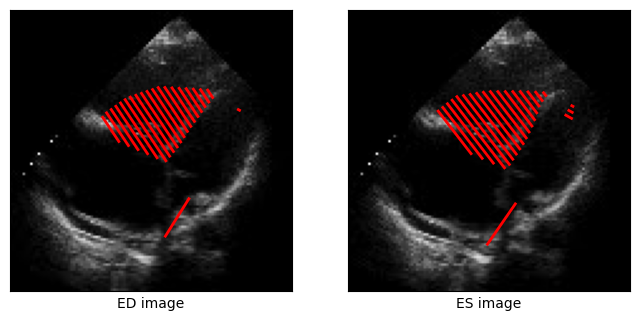

Data id 0X973E4A9DAADDF9F


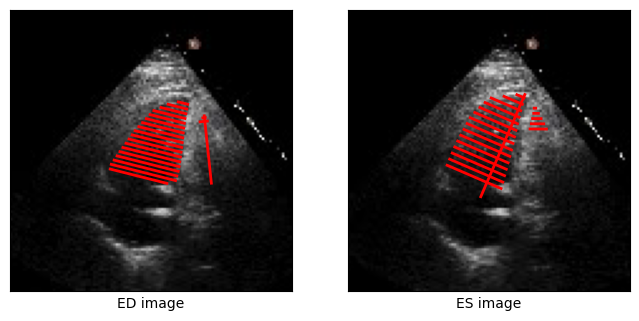

Data id 0X37F9E9981E207C04


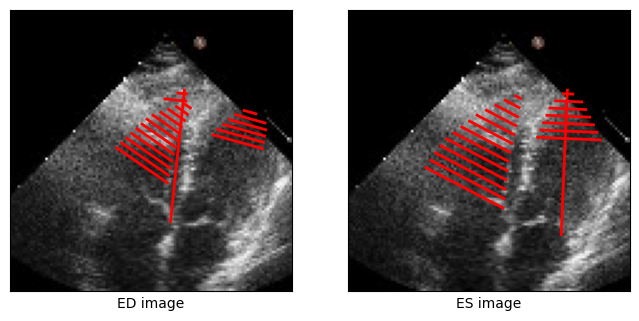

Data id 0X766B7B0ABDB07CD5


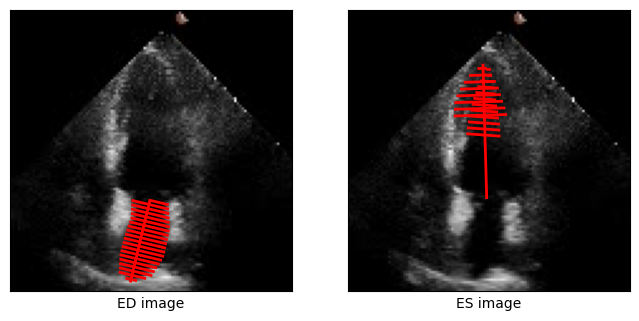

Data id 0X5B6FCBB75BF8FCB7


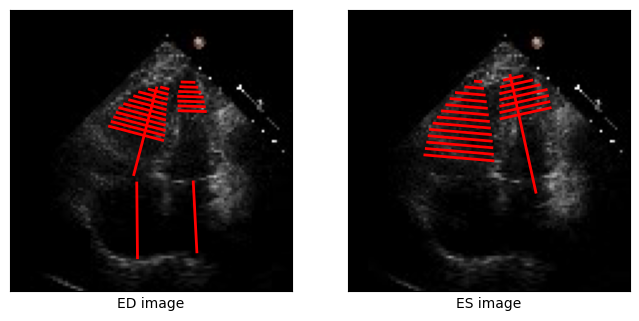

Data id 0X36C5A15AC7FC6AAA


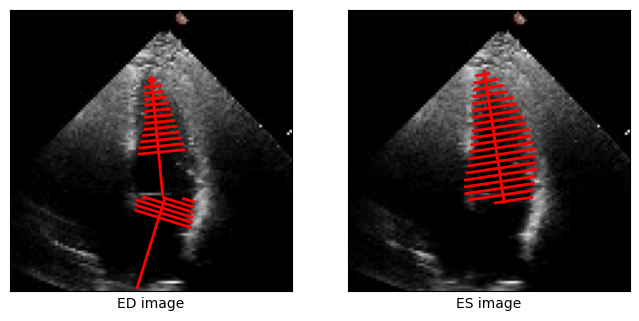

Data id 0X4BBA9C8FB485C9AB


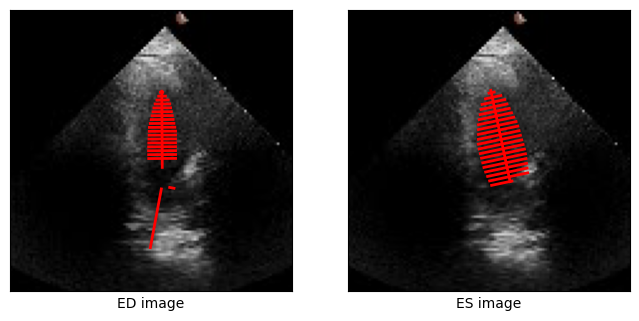

Data id 0X49EC1927F5747B19


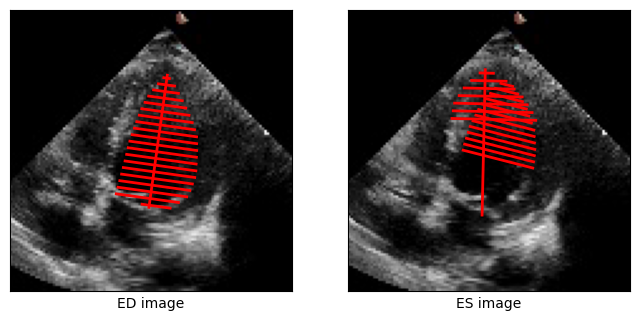

Data id 0X5D38D994C2490EAE


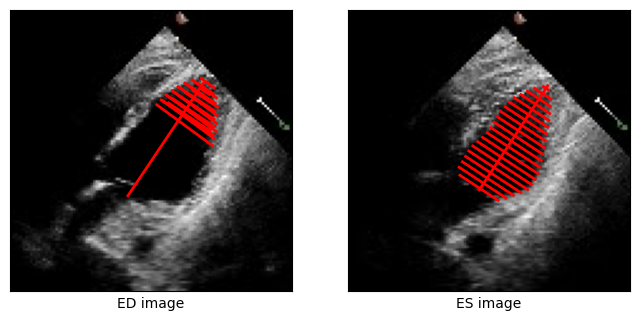

Data id 0X53C185263415AA4F


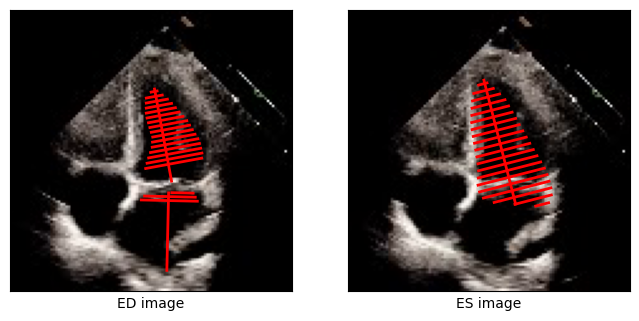

Data id 0X65E605F203321860


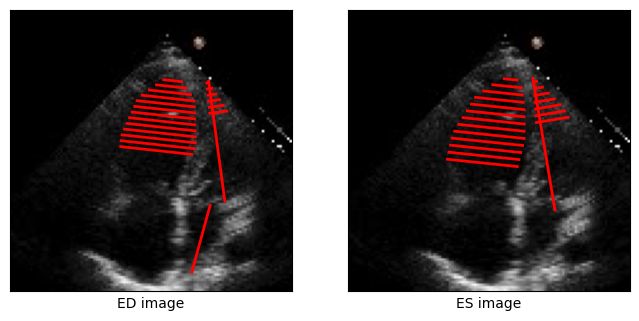

Data id 0X753AA26EA352BBB


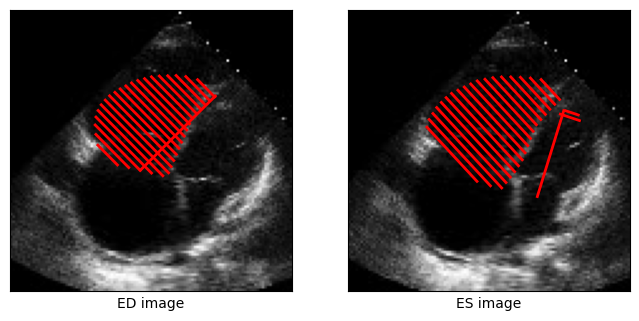

In [35]:
for i, j in error_indices :
    VisualizeInstanceData(train_images, train_keypoints_conv, train_ids, i, j)
    plt.show()

Remove the incorrect volume traces from the training dataset

In [36]:
flat_list = list(np.concatenate(error_indices ).flat)
train_keypoints_conv = np.delete(train_keypoints_conv, flat_list, 0)
train_images = np.delete(train_images, flat_list, 0)
train_ids = np.delete(train_ids, flat_list, 0)

**Xóa dữ liệu train lỗi**
* Xác định các bệnh nhân sau khi trực quan hóa các ảnh được vẽ bởi các điểm không chính xác 
* Tiến hành xóa các đối tượng 

# PHẦN 6 — XÂY DỰNG VÀ HUẤN LUYỆN MODEL

#### Build the model for training

I am using the MobileNetv2 from keras applications as the backbone.

Using the imagenet weights, I do a transfer learning using a new head that detects the keypoints for the Echo images. There are 42 points to detect.

In [37]:
IMAGE_SIZE=112
backbone = MobileNetV2(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), weights='imagenet', include_top=False)
backbone.trainable = False

/tmp/ipykernel_23/117206340.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  backbone = MobileNetV2(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), weights='imagenet', include_top=False)
I0000 00:00:1778374021.259761      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778374021.265708      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step



**Mục đích:**
Đoạn code này dùng để áp dụng kỹ thuật Học chuyển giao (Transfer Learning), cụ thể là khởi tạo và cấu hình một mạng nơ-ron học sâu (MobileNetV2) làm bộ trích xuất đặc trưng (feature extractor / backbone) cho bài toán dự đoán tọa độ thay vì phải xây dựng mạng từ con số 0.

**Các tham số cấu hình (Đầu vào):**
*   **`IMAGE_SIZE=112`**: Biến quy định chuẩn kích thước hình ảnh đầu vào là $112 \times 112$ pixels.
*   **`input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)`**: Khai báo hình dáng không gian của tensor đầu vào cho mô hình, gồm ảnh vuông kích thước $112 \times 112$ và $3$ kênh màu (RGB).
*   **`weights='imagenet'`**: Yêu cầu tải bộ trọng số (pre-trained weights) đã được huấn luyện sẵn trên tập dữ liệu ImageNet khổng lồ.
*   **`include_top=False`**: Cờ (flag) yêu cầu loại bỏ lớp phân loại (Classification Head / Fully Connected) nguyên bản nằm ở cuối của MobileNetV2.

**Đầu ra:**
*   Tạo ra một đối tượng mô hình tên là `backbone` (chỉ bao gồm phần mạng tích chập - Convolutional Base) mang theo kiến thức từ ImageNet và đã bị "khóa cứng" (không cho phép cập nhật lại trọng số).

**Cách hoạt động:**
1.  **Thiết lập quy chuẩn**: Khởi tạo biến `IMAGE_SIZE` để cố định kích thước chung cho các luồng xử lý ảnh.
2.  **Khởi tạo cấu trúc xương sống (Backbone)**: 
    *   Gọi cấu trúc mạng MobileNetV2 và định hình giới hạn đầu vào thông qua `input_shape`.
    *   Tải trực tiếp bộ trọng số từ `imagenet` để tận dụng năng lực phân tích đường nét, góc cạnh, hình khối đã được mô hình này tối ưu từ trước.
    *   Cắt bỏ lớp học máy cuối cùng (`include_top=False`) vì bài toán của chúng ta là hồi quy tìm tọa độ tim (Regression) chứ không phải phân loại xem bức ảnh là chó hay mèo (Classification).
3.  **Đóng băng trọng số**: Lệnh `backbone.trainable = False` sẽ vô hiệu hóa quá trình tính toán đạo hàm và cập nhật gradient (Backpropagation) đối với toàn bộ các lớp của MobileNetV2. Việc này giúp bảo toàn các đặc trưng thị giác tổng quát đã lấy từ bộ trọng số gốc, đồng thời tiết kiệm đáng kể thời gian và tài nguyên tính toán của hệ thống trong giai đoạn huấn luyện (Training Phase).



### 1. Siêu tham số `IMAGE_SIZE = 112`
*   **Mô tả:** Kích thước (chiều rộng và chiều cao) của ảnh đầu vào.
*   **Lý do lựa chọn:** 
    *   Kích thước $112 \times 112$ là một con số tối ưu để cân bằng giữa hai yếu tố: **Độ phân giải** (đủ rõ nét để nhìn thấy biên tâm thất trái) và **Chi phí tính toán** (nhanh và tốn ít RAM). 
    *   Hơn nữa, $112$ là chính xác một nửa của $224$ (kích thước mặc định chuẩn của bộ trọng số ImageNet). Việc chọn các con số là bội số/ước số của hệ nhị phân (như 96, 112, 128, 224) giúp các lớp giảm lấy mẫu (Downsampling / Pooling) hoạt động trơn tru mà không bị làm tròn phần dư.

### 2. Siêu tham số `Dropout(0.3)`
*   **Mô tả:** Tỷ lệ nơ-ron bị tắt ngẫu nhiên trong quá trình huấn luyện là $30\%$.
*   **Lý do lựa chọn:** 
    *   Trong Học sâu, nếu mạng quá phức tạp, nó sẽ có xu hướng "học thuộc lòng" (Overfitting) dữ liệu thay vì "hiểu" dữ liệu. Tỷ lệ $0.3$ (hoặc từ $0.2 \rightarrow 0.5$) là con số tiêu chuẩn thực nghiệm được chứng minh là đủ lớn để ép các nơ-ron phải học các đặc trưng một cách độc lập, nhưng không quá lớn đến mức làm "mù" mô hình và ngăn cản quá trình học thuật toán.

### 3. Kiến trúc `SeparableConv2D` (Thay vì `Conv2D` thông thường)
*   **Mô tả:** Lớp Tích chập tách biệt theo chiều sâu (Depthwise Separable Convolution).
*   **Lý do lựa chọn:** 
    *   Kế thừa triết lý thiết kế của MobileNetV2. `SeparableConv2D` tách phép nhân ma trận 3D thành 2 bước (Depthwise và Pointwise), giúp **giảm từ 8-9 lần số lượng tham số** và khối lượng phép tính so với `Conv2D` truyền thống. 
    *   Điều này giúp toàn bộ mô hình của bạn giữ được sự nhỏ gọn, chạy siêu nhanh (có thể deploy trên thiết bị di động/máy siêu âm thực tế) mà không làm suy giảm quá nhiều độ chính xác.

### 4. Tham số kích thước cửa sổ `kernel_size=3` và `kernel_size=2`
*   **Mô tả:** Kích thước của bộ lọc không gian quét qua bức ảnh. Ở lớp ẩn (ConvPass) là $3 \times 3$, ở lớp đầu ra (OutputLayer) là $2 \times 2$.
*   **Lý do lựa chọn:**
    *   **Kernel $3 \times 3$:** Là "tiêu chuẩn vàng" trong cấu trúc mạng CNN. Nó cung cấp trường nhìn (receptive field) vừa đủ để nắm bắt các đặc trưng hình học cục bộ (như độ cong của một đoạn thành cơ tim) nhưng vẫn giữ cho tham số ít nhất có thể.
    *   **Kernel $2 \times 2$:** Ở các lớp cuối, không gian chiều (spatial dimensions) của tensor đã bị thu nhỏ lại rất nhiều. Kernel $2 \times 2$ giúp mô hình hội tụ nốt các thông tin vi mô cuối cùng để khớp với kích thước của chuỗi tọa độ đầu ra mong muốn.

### 5. Tham số hàm kích hoạt `activation='relu'` (tại lớp ConvPass)
*   **Mô tả:** Hàm kích hoạt Tuyến tính chỉnh lưu (Rectified Linear Unit), chuyển các giá trị âm thành $0$.
*   **Lý do lựa chọn:** `ReLU` là hàm kích hoạt bắt buộc phải có cho các lớp ẩn (Hidden Layers). Nó giải quyết triệt để vấn đề "Tiệt tiêu đạo hàm" (Vanishing Gradient), giúp thuật toán học nhanh hơn, đồng thời tạo ra tính phi tuyến tính để mô hình có khả năng học được các đường ranh giới tim có hình dáng phức tạp, không theo quy luật.

### 6. Tham số hàm kích hoạt `activation='sigmoid'` (tại lớp OutputLayer)
*   **Mô tả:** Hàm S-shape, ép tất cả các giá trị số thực từ $(-\infty, +\infty)$ về khoảng quy chuẩn từ $(0, 1)$.
*   **Lý do lựa chọn (Cực kỳ quan trọng):** 
    *   Trong phần tiền xử lý dữ liệu trước đó, toàn bộ tọa độ các điểm đánh dấu (Keypoints) đã được chuẩn hóa (chia cho `IMAGE_SIZE`) để đưa về mốc từ $0$ đến $1$. 
    *   Hàm `Sigmoid` ở lớp cuối cùng đóng vai trò ép mô hình **chỉ được phép dự báo ra kết quả nằm trong giới hạn từ $0$ đến $1$**. Nếu không dùng Sigmoid (ví dụ dùng ReLU), mô hình có thể dự báo ra tọa độ là $15$ hoặc $200$, làm sai lệch hoàn toàn bản chất không gian toán học của bài toán.

In [38]:
MODEL_NAME = 'LV_Cavity_Volume_Trace'
#InputLayer
inputs = Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3), name="InputLayer")
# Preprocess Input
x = mobilenet_v2.preprocess_input(inputs)
# MobileNetV2 Backbone
x = backbone(x)
# Regularization
x = Dropout(0.3, name="DropOut")(x)
# Separable Convolutional Operation
x = SeparableConv2D(NUM_KEYPOINTS, kernel_size=3, activation='relu', data_format='channels_last', name="ConvPass")(x)
# Outputs
outputs = SeparableConv2D(NUM_KEYPOINTS, kernel_size=2, activation='sigmoid', data_format='channels_last', name="OutputLayer")(x)
#Model
model_1 = Model(inputs, outputs, name=MODEL_NAME)
model_1.summary()

Model: "LV_Cavity_Volume_Trace"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ InputLayer (InputLayer)         │ (None, 112, 112, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 112, 112, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 112, 112, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ DropOut (Dropout)               │ (None, 4, 4, 1280)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ConvPass (SeparableConv2D)      │ (None, 2, 2, 84)       │       119,124 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ OutputLayer (SeparableConv2D)   │ (None, 1, 1, 84)       │         7,476 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,384,584 (9.10 MB)

 Trainable params: 126,600 (494.53 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


**Mục đích:**
Đoạn code này dùng để lắp ráp và liên kết các khối xử lý rời rạc thành một mạng nơ-ron (Neural Network) hoàn chỉnh mang tên `LV_Cavity_Volume_Trace`. Nó xây dựng luồng chảy của dữ liệu từ lớp đầu vào (Input), qua bước tiền xử lý, qua bộ trích xuất đặc trưng (Backbone), cho đến các lớp dự đoán tùy chỉnh và cho ra kết quả cuối cùng.

**Các tham số cấu hình (Đầu vào):**
*   **`MODEL_NAME`**: Chuỗi ký tự định danh tên cho toàn bộ kiến trúc mô hình.
*   **`Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))`**: Lớp đầu vào định nghĩa kích thước không gian tensor mà mạng sẽ tiếp nhận.
*   **`Dropout(0.3)`**: Lớp điều chuẩn (Regularization) với tỷ lệ loại bỏ ngẫu nhiên $30\%$ nơ-ron.
*   **`SeparableConv2D(...)`**: Lớp tích chập tách biệt theo chiều sâu (Depthwise Separable Convolution). Lớp ẩn (ConvPass) sử dụng kernel $3 \times 3$ và hàm kích hoạt `relu`. Lớp đầu ra (OutputLayer) sử dụng kernel $2 \times 2$ và hàm kích hoạt `sigmoid`.

**Đầu ra:**
*   Một đối tượng mô hình học sâu hoàn chỉnh (`model_1`) sẵn sàng cho việc thiết lập siêu tham số và huấn luyện (Training).
*   Lệnh `model_1.summary()` in ra màn hình bảng thống kê chi tiết về cấu trúc mạng, kích thước dữ liệu (shape) thay đổi qua từng lớp và tổng số tham số (Trainable và Non-trainable params).



Load the validation images

In [39]:
val_images, val_keypoints, val_ids = LoadData(OUTPUT_DIR, type='VAL')
pp.pprint(val_images.shape)
pp.pprint(val_keypoints.shape)
val_keypoints_conv = val_keypoints.astype('float32')

(2576, 112, 112, 3)
(2576, 1, 1, 84)



**Mục đích:**
Đoạn code này dùng để tải (load), kiểm chứng và tiền xử lý tập dữ liệu kiểm định (Validation Set) vào bộ nhớ (RAM). Tập dữ liệu này sẽ được dùng để đánh giá độ chính xác của mô hình ở cuối mỗi chu kỳ huấn luyện (epoch).

**Các tham số cấu hình (Đầu vào):**
*   **`OUTPUT_DIR`**: Đường dẫn thư mục chứa toàn bộ dữ liệu (hình ảnh và file CSV tọa độ) đã được sinh ra và chuẩn bị từ các bước phân tách video ban đầu.
*   **`type='VAL'`**: Tham số lọc báo cho hàm `LoadData` biết rằng nó chỉ được phép thu thập các dữ liệu đã gán mác kiểm định ('VAL'), và phải phớt lờ các dữ liệu huấn luyện ('TRAIN') hay kiểm thử ('TEST').

**Đầu ra:**
*   **`val_images`**: Ma trận đa chiều chứa toàn bộ dữ liệu điểm ảnh (pixel) của các hình ảnh siêu âm tập kiểm định.
*   **`val_keypoints`**: Ma trận chứa tọa độ (nhãn) tương ứng với các ảnh trong mảng `val_images`.
*   **`val_ids`**: Danh sách lưu mã bệnh nhân để truy xuất khi cần vẽ hình.
*   **Khai báo in (Print)**: Kết quả in ra màn hình hiển thị chiều kích thước (shape) của hai mảng dữ liệu.
*   **`val_keypoints_conv`**: Một phiên bản mảng tọa độ mới đã được hạ cấp kiểu dữ liệu xuống `float32`.


In [40]:
# Callbacks 
from keras.callbacks import EarlyStopping, ModelCheckpoint, Callback

# Optimizer 
from tensorflow.keras.optimizers import Adam

In [41]:
class ShowProgress(Callback):
    
    def on_epoch_end(self, epoch, logs=None):
        if epoch % 20 == 0:
            plt.subplots(1, 4, figsize=(10, 10))
            for i, k in enumerate(np.random.randint(num_total, size=2)):
                img = train_images[k]
                img = img.reshape(-1, IMAGE_SIZE, IMAGE_SIZE, 3)
                pred_kps = self.model.predict(img)
                pred_kps = pred_kps.reshape(-1,NUM_KEYPOINTS) * IMAGE_SIZE
                kps = train_keypoints_conv[k].reshape(-1,NUM_KEYPOINTS) * IMAGE_SIZE
                plt.subplot(1, 4, 2*i+1)
                plt.gca().set_yticklabels([])
                plt.gca().set_xticklabels([])
                plt.gca().set_xticks([])
                plt.gca().set_yticks([])
                VisualizeSampleImages(img[0], pred_kps, col='#16a085')
                plt.xlabel(f"Predicted")
                plt.subplot(1, 4, 2*i+2)
                plt.gca().set_yticklabels([])
                plt.gca().set_xticklabels([])
                plt.gca().set_xticks([])
                plt.gca().set_yticks([])
                VisualizeSampleImages(img[0], kps)
                plt.xlabel(f"GT:{train_ids[k]}")
            plt.show()

**Cấu trúc các thành phần:**

**class ShowProgress(Callback):** Kế thừa từ lớp cơ sở Callback của thư viện Keras. Kế thừa class này cho phép đoạn code của bạn "móc nối" (hook) can thiệp trực tiếp vào quy trình chạy ngầm của hàm huấn luyện model.fit().

**def on_epoch_end(self, epoch, logs=None):** Đây là một hàm xử lý sự kiện (event-handler) tiêu chuẩn của Keras. Hàm này được thiết kế để tự động kích hoạt mỗi khi một chu kỳ huấn luyện (Epoch) vừa kết thúc.
Cách hoạt động chi tiết:

**Điều tiết tần suất (Throttling):** Lệnh if epoch % 20 == 0 cài đặt điều kiện để code chỉ vẽ hình sau mỗi 20 chu kỳ (ở các epoch số 0, 20, 40...). Điều này tránh việc in ra quá nhiều hình ảnh gây lag máy và làm chậm tốc độ huấn luyện thuật toán.

**Lấy mẫu ngẫu nhiên:** Code chọn ngẫu nhiên 2 bức ảnh từ tập huấn luyện thông qua lệnh np.random.randint(...).

**Dự đoán theo thời gian thực**: Lệnh pred_kps = self.model.predict(img) sẽ lấy chính bộ trọng số của mô hình ngay tại epoch hiện tại để dự đoán ra tọa độ ranh giới tim.

**Giải chuẩn hóa (Denormalization):** Nhân cả tọa độ mô hình vừa dự đoán (pred_kps) và tọa độ thực tế gốc (kps) với IMAGE_SIZE để phóng to chúng từ khoảng tỷ lệ $[0, 1]$ về lại kích thước pixel chuẩn của bức ảnh.

**Vẽ biểu đồ đối chứng (Side-by-side Comparison):**
* Tạo ra một khung hiển thị nằm ngang chứa 4 bức ảnh (subplots(1, 4)).
**Với mỗi tấm ảnh được chọn, nó vẽ 2 phiên bản đặt cạnh nhau:**
* Ảnh bên trái (Nhãn là Predicted): Gọi hàm VisualizeSampleImages để vẽ lên đường bao quanh tim mà AI tự dự đoán. Đường này được chỉ định tô màu xanh ngọc mã #16a085.
* Ảnh bên phải (Nhãn là GT - Ground Truth): Cũng hình ảnh đó nhưng vẽ lên đường bao quanh tim do chuyên gia y tế vẽ (nhãn gốc chuẩn xác màu đỏ) để làm mốc đối chiếu.
* Hiển thị (plt.show()): Cập nhật biểu đồ lên giao diện Jupyter Notebook cho con người xem.

Train

In [42]:
WEIGHT_DIR = Path('/kaggle/working/Weights')
WEIGHT_DIR.mkdir(parents=True, exist_ok=True)

Epoch 1/200


I0000 00:00:1778374055.035874   30230 service.cc:152] XLA service 0x7bb074025200 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778374055.035915   30230 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778374055.035919   30230 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778374056.119030   30230 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-10 00:47:44.457455: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 00:47:44.612535: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 00:47:44.749421: E external/local_xl

460/466 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0895

2026-05-10 00:48:01.293310: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 00:48:01.431448: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 00:48:02.222262: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 00:48:02.367853: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 00:48:02.672271: E external/local_xla/xla/stream_

466/466 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0892

2026-05-10 00:48:17.724729: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 00:48:17.866410: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 00:48:18.652026: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 00:48:18.796265: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 00:48:29.557332: E external/local_xla/xla/stream_

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


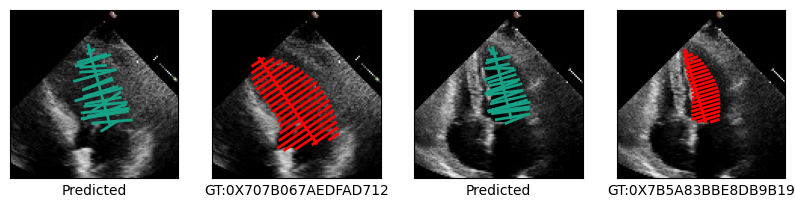

466/466 ━━━━━━━━━━━━━━━━━━━━ 63s 94ms/step - loss: 0.0891 - val_loss: 0.0468
Epoch 2/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0427 - val_loss: 0.0381
Epoch 3/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0366 - val_loss: 0.0353
Epoch 4/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0343 - val_loss: 0.0335
Epoch 5/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0328 - val_loss: 0.0324
Epoch 6/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0317 - val_loss: 0.0316
Epoch 7/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0311 - val_loss: 0.0313
Epoch 8/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0305 - val_loss: 0.0308
Epoch 9/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0301 - val_loss: 0.0304
Epoch 10/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0298 - val_loss: 0.0301
Epoch 11/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0297 - val_loss: 0.0299
Epoch 12/200
466/466 ━━━━━━━━━━━━━━━━━━━━

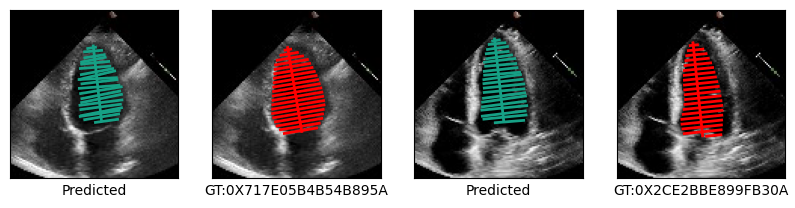

466/466 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0274 - val_loss: 0.0285
Epoch 22/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0274 - val_loss: 0.0284
Epoch 23/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0273 - val_loss: 0.0284
Epoch 24/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0271 - val_loss: 0.0282
Epoch 25/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0271 - val_loss: 0.0283
Epoch 26/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0268 - val_loss: 0.0284
Epoch 27/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0267 - val_loss: 0.0281
Epoch 28/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0268 - val_loss: 0.0280
Epoch 29/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0263 - val_loss: 0.0280
Epoch 30/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0263 - val_loss: 0.0281
Epoch 31/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0264 - val_loss: 0.0278
Epoch 32/200
466/466 ━━━━━━━━━━━━━

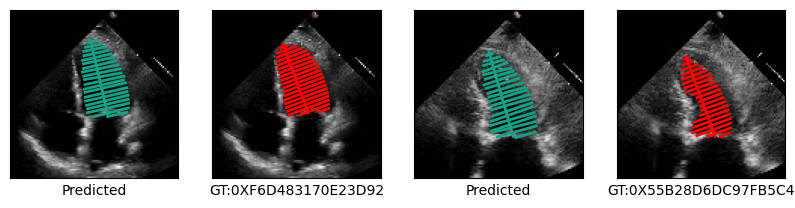

466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0255 - val_loss: 0.0276
Epoch 42/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0253 - val_loss: 0.0276
Epoch 43/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0252 - val_loss: 0.0274
Epoch 44/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0252 - val_loss: 0.0276
Epoch 45/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0251 - val_loss: 0.0274
Epoch 46/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0251 - val_loss: 0.0274
Epoch 47/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0250 - val_loss: 0.0274
Epoch 48/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0250 - val_loss: 0.0274
Epoch 49/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0249 - val_loss: 0.0275
Epoch 50/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0248 - val_loss: 0.0274
Epoch 51/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0247 - val_loss: 0.0273
Epoch 52/200
466/466 ━━━━━━━━━━━━━

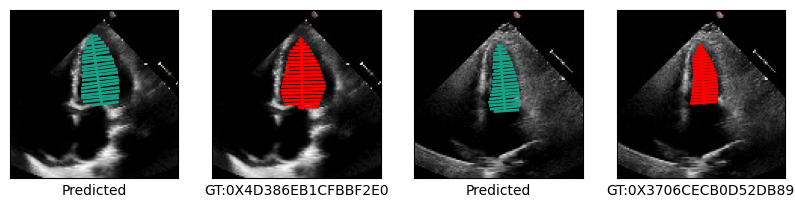

466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0242 - val_loss: 0.0272
Epoch 62/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0240 - val_loss: 0.0274
Epoch 63/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0241 - val_loss: 0.0272
Epoch 64/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0238 - val_loss: 0.0272
Epoch 65/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0240 - val_loss: 0.0272
Epoch 66/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0238 - val_loss: 0.0273
Epoch 67/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0237 - val_loss: 0.0273
Epoch 68/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0238 - val_loss: 0.0272
Epoch 69/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0237 - val_loss: 0.0272
Epoch 70/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0240 - val_loss: 0.0272
Epoch 71/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0237 - val_loss: 0.0272
Epoch 72/200
466/466 ━━━━━━━━━━━━━

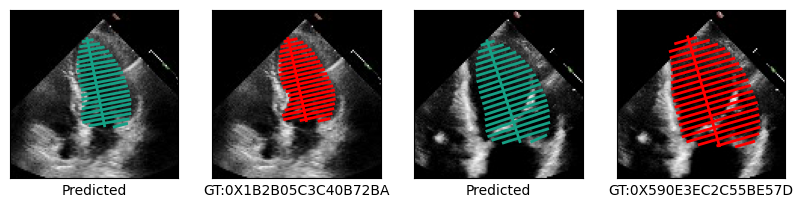

466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0232 - val_loss: 0.0272
Epoch 82/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0232 - val_loss: 0.0272
Epoch 83/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0231 - val_loss: 0.0272
Epoch 84/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0231 - val_loss: 0.0274
Epoch 85/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0231 - val_loss: 0.0272
Epoch 86/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0232 - val_loss: 0.0272
Epoch 87/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0229 - val_loss: 0.0272
Epoch 88/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0230 - val_loss: 0.0272
Epoch 89/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0229 - val_loss: 0.0272
Epoch 90/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0229 - val_loss: 0.0272
Epoch 91/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0228 - val_loss: 0.0272
Epoch 92/200
466/466 ━━━━━━━━━━━━━

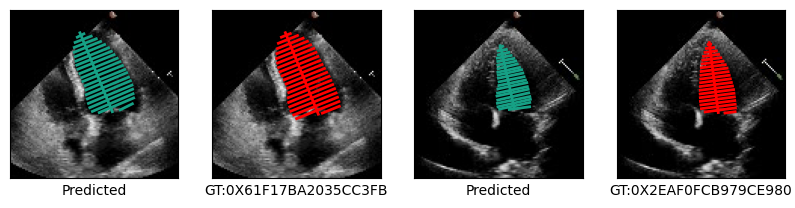

466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0227 - val_loss: 0.0272
Epoch 102/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0225 - val_loss: 0.0272
Epoch 103/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0227 - val_loss: 0.0272
Epoch 104/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0225 - val_loss: 0.0272
Epoch 105/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0223 - val_loss: 0.0273
Epoch 106/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0225 - val_loss: 0.0273
Epoch 107/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0226 - val_loss: 0.0272
Epoch 108/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0224 - val_loss: 0.0274
Epoch 109/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0225 - val_loss: 0.0273
Epoch 110/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0220 - val_loss: 0.0273
Epoch 111/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0223 - val_loss: 0.0272
Epoch 112/200
466/466 ━━

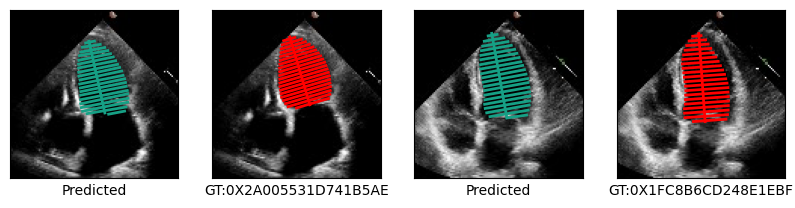

466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0220 - val_loss: 0.0272
Epoch 122/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0221 - val_loss: 0.0273
Epoch 123/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0220 - val_loss: 0.0273
Epoch 124/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0219 - val_loss: 0.0273
Epoch 125/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0219 - val_loss: 0.0272
Epoch 126/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0218 - val_loss: 0.0274
Epoch 127/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0218 - val_loss: 0.0273
Epoch 128/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0215 - val_loss: 0.0273
Epoch 129/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0218 - val_loss: 0.0274
Epoch 130/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0217 - val_loss: 0.0273
Epoch 131/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0216 - val_loss: 0.0275
Epoch 132/200
466/466 ━━

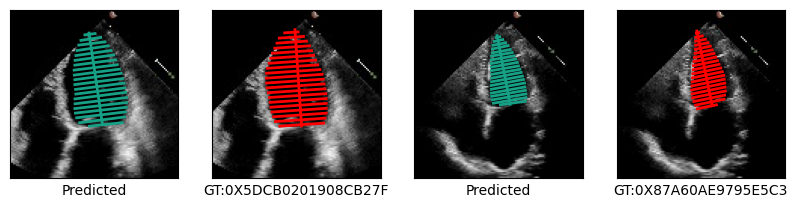

466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0215 - val_loss: 0.0272
Epoch 142/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0215 - val_loss: 0.0273
Epoch 143/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0213 - val_loss: 0.0273
Epoch 144/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0213 - val_loss: 0.0273
Epoch 145/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0214 - val_loss: 0.0273
Epoch 146/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0213 - val_loss: 0.0273
Epoch 147/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0212 - val_loss: 0.0277
Epoch 148/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0213 - val_loss: 0.0273
Epoch 149/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0213 - val_loss: 0.0273
Epoch 150/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0215 - val_loss: 0.0274
Epoch 151/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0213 - val_loss: 0.0273
Epoch 152/200
466/466 ━━

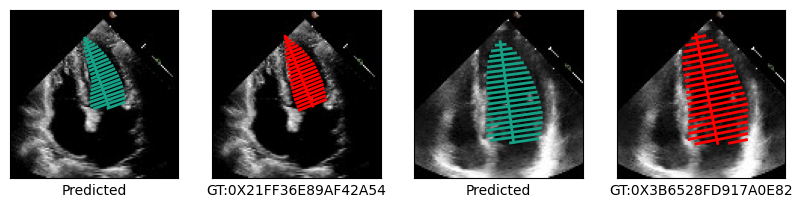

466/466 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0210 - val_loss: 0.0274
Epoch 162/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0210 - val_loss: 0.0274
Epoch 163/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0211 - val_loss: 0.0274
Epoch 164/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0211 - val_loss: 0.0274
Epoch 165/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0210 - val_loss: 0.0273
Epoch 166/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0209 - val_loss: 0.0273
Epoch 167/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0211 - val_loss: 0.0275
Epoch 168/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0209 - val_loss: 0.0274
Epoch 169/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0208 - val_loss: 0.0275
Epoch 170/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0208 - val_loss: 0.0274
Epoch 171/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0208 - val_loss: 0.0274
Epoch 172/200
466/466 ━━

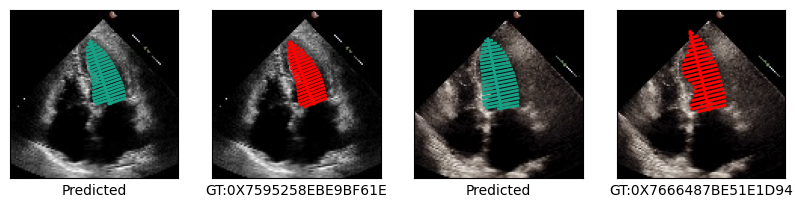

466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0206 - val_loss: 0.0274
Epoch 182/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0207 - val_loss: 0.0274
Epoch 183/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0207 - val_loss: 0.0274
Epoch 184/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0206 - val_loss: 0.0277
Epoch 185/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0208 - val_loss: 0.0274
Epoch 186/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0204 - val_loss: 0.0275
Epoch 187/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0207 - val_loss: 0.0276
Epoch 188/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0206 - val_loss: 0.0275
Epoch 189/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0206 - val_loss: 0.0275
Epoch 190/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0205 - val_loss: 0.0275
Epoch 191/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0205 - val_loss: 0.0276
Epoch 192/200
466/466 ━━

In [43]:
EPOCHS=200
# Compile
model_1.compile(loss='mae', optimizer=Adam(learning_rate=1e-4)) # Lower the Learning Rate better the results.
checkpoint_path = f"{WEIGHT_DIR}/{MODEL_NAME}-{{epoch:04d}}.weights.h5"
# Model Training
callbacks = [
#     EarlyStopping(patience=7, restore_best_weights=True), # keep the patience low.
    ModelCheckpoint(checkpoint_path, save_best_only=True, save_weights_only=True),
    ShowProgress()
]
history = model_1.fit(train_images, train_keypoints_conv, 
                      validation_data=(val_images, val_keypoints_conv), 
                      epochs=EPOCHS, 
                      callbacks=callbacks)

**Các tham số và cấu hình cốt lõi:**

**EPOCHS = 200:** Tổng số chu kỳ huấn luyện. Nghĩa là mô hình sẽ lặp lại việc học qua toàn bộ 100% dữ liệu huấn luyện đúng 200 lần.

**loss='mae':** Hàm sai số tuyệt đối trung bình (Mean Absolute Error).

**learning_rate=1e-4:** Tốc độ học của thuật toán tối ưu (chỉ số $0.0001$). Một tốc độ chậm và nhỏ gọn giúp trọng số thay đổi từ từ, tăng khả năng tìm thấy mức độ chính xác cao nhất mà không bị "bước hụt" qua vạch đích.

**Đầu ra (Output):**

**Trên màn hình:** Xuất hiện thanh tiến trình (progress bar) chạy qua từng epoch hiển thị các thông số Loss. Cứ mỗi 20 epochs, các biểu đồ ảnh siêu âm sẽ được vẽ ra để bạn kiểm chứng (nhờ ShowProgress).

**Trên ổ cứng:** Các file trọng số .weights.h5 tốt nhất liên tục được xuất ra thư mục Weights/.

**Trong bộ nhớ:** Trả về đối tượng history, là cuốn "nhật ký" lưu lại toàn bộ chỉ số sai số của cả tập Train và Validation qua từng epoch, dùng để vẽ biểu đồ đánh giá về sau.


Visualize Loss Curve

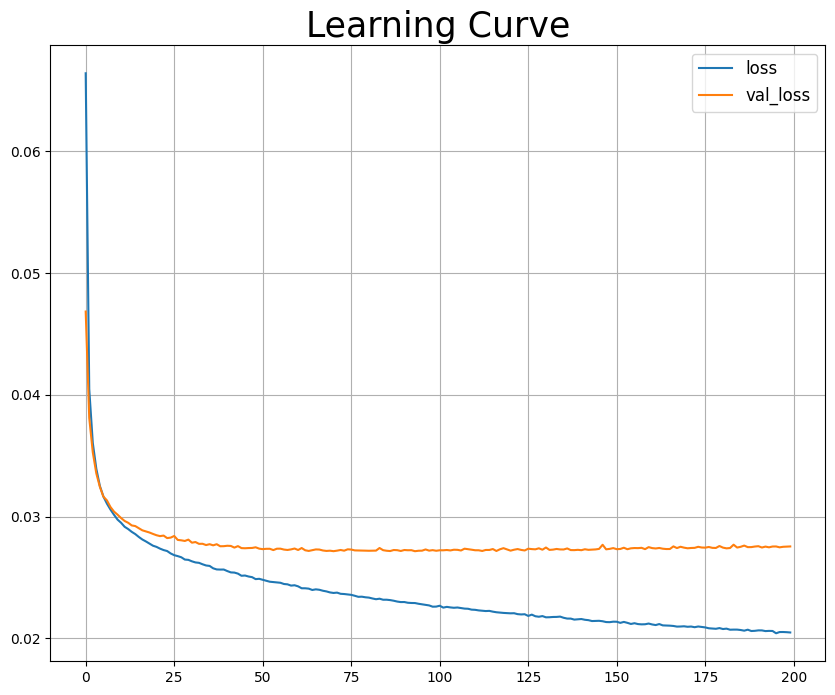

In [44]:
lc = pd.DataFrame(history.history)
lc.plot(figsize=(10,8))
plt.title("Learning Curve", fontsize=25)
plt.grid()
plt.legend(fontsize=12)
plt.show()


### Phân tích Biểu đồ Học tập (Learning Curve)

**1. Ý nghĩa các thông số:**
*   **Đường màu xanh (`loss`):** Đại diện cho sai số của mô hình trên tập dữ liệu huấn luyện (Training Set).
*   **Đường màu cam (`val_loss`):** Đại diện cho sai số của mô hình trên tập dữ liệu kiểm định (Validation Set - dữ liệu mới mà mô hình chưa từng thấy).
*   **Trục ngang (X):** Thời gian huấn luyện tính bằng số chu kỳ (Epochs), chạy từ 0 đến 200.
*   **Trục dọc (Y):** Mức độ sai lệch (Tính theo hàm MAE). Giá trị càng thấp càng tốt.

**2. Diễn biến quá trình học:**
*   **Giai đoạn hội tụ (Epoch 0 - 60):** Cả hai đường xanh và cam đều có xu hướng cắm xuống đồng thời. Điều này chứng tỏ kiến trúc mạng đang hoạt động rất tốt, mô hình đang tiếp thu kiến thức và liên tục giảm thiểu sai số.
*   **Điểm tối ưu (Xoay quanh Epoch 60 - 70):** Đường màu cam (`val_loss`) chạm đến mức đáy thấp nhất của nó (khoảng vạch 0.027). Đây chính là "điểm vàng" (Sweet Spot) – thời khắc mà mô hình đạt độ chính xác cao nhất, tổng quát hóa tốt nhất trên dữ liệu y tế thực tế. *(Điều này khớp hoàn toàn với việc máy tính đã chốt lưu file `best_checkpoint` ở epoch thứ 66)*.
*   **Giai đoạn quá khớp (Epoch 70 - 200):** 
    * Đường màu xanh (`loss`) vẫn mượt mà cắm đầu đi xuống, chứng tỏ AI đang cố gắng học thuộc lòng 100% tập Train.
    * Tuy nhiên, đường màu cam (`val_loss`) lại ngừng giảm, bắt đầu đi ngang, dao động nhiễu và có xu hướng nhích nhẹ lên trên. Khoảng cách (Gap) giữa 2 đường ngày càng bị kéo giãn rộng ra.

**3. Kết luận:**
Biểu đồ này là một ví dụ kinh điển minh họa cho hiện tượng **Học vẹt (Overfitting)** trong Deep Learning. 



# PHẦN 7 — ĐÁNH GIÁ TRÊN TEST DATA

In [45]:
from tensorflow.train import latest_checkpoint
latest = latest_checkpoint('/kaggle/working')
latest

In [46]:
test_images, test_keypoints, test_ids = LoadData(OUTPUT_DIR, type='TEST')
pp.pprint(test_images.shape)
pp.pprint(test_keypoints.shape)
test_keypoints_conv = test_keypoints.astype('float32')

(2552, 112, 112, 3)
(2552, 1, 1, 84)


In [47]:
def evaluate_model(model, data_images, data_keypoints):
    loss = model.evaluate(data_images, data_keypoints, verbose=2)
    return loss

**Các tham số cấu hình (Đầu vào):**

**model:** Đối tượng mạng nơ-ron (như model_1 ở trên) đã được huấn luyện xong hoặc vừa được tải trọng số (load weights).

**data_images:** Mảng chứa danh sách các bức ảnh siêu âm mà bạn muốn mang ra "đố" mô hình.

**data_keypoints:** Mảng chứa tọa độ thực tế (Ground Truth) tương ứng với các bức ảnh trên. Nó đóng vai trò là "bản đáp án chuẩn" để máy tính đem ra đối chiếu với câu trả lời của mô hình.

**Đầu ra:**

**loss:** Một giá trị số thực đại diện cho mức sai số tổng thể của mô hình trên tập dữ liệu này (do bạn đang cấu hình hàm loss là mae - Mean Absolute Error). Con số này càng nhỏ chứng tỏ khả năng đoán ranh giới tim của mô hình càng sát với thực tế.

In [48]:

list_of_files = list(WEIGHT_DIR.glob('*.weights.h5'))

best_checkpoint = max(list_of_files, key=lambda f: int(f.name.split('-')[-1].split('.')[0]))
print(f"File tốt nhất: {best_checkpoint}")

model_2 = Model(inputs, outputs, name=MODEL_NAME)
model_2.compile(loss='mae', optimizer=Adam(learning_rate=1e-4))
model_2.load_weights(str(best_checkpoint))
print("Load weights thành công!")


File tốt nhất: /kaggle/working/Weights/LV_Cavity_Volume_Trace-0094.weights.h5
Load weights thành công!


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



**Mục đích của việc tạo biến `model_2`:**
Khởi tạo hẳn một mô hình mới thay vì dùng lại `model_1` là thủ thuật lập trình cẩn thận nhằm 3 mục đích:
1. **Làm sạch vùng nhớ (Clean Model):** Tạo ra một mô hình tinh khiết hoàn toàn, loại bỏ triệt để các trạng thái bộ nhớ rác (cache, dải gradient) bị tồn đọng trên RAM của `model_1` sau quá trình cày ải liên tục 200 chu kỳ.
2. **Tránh rủi ro ghi đè (Prevent Overwrite):** Bảo vệ sự an toàn cho `model_1` hiện tại, đảm bảo không làm hỏng mô hình cũ trong trường hợp việc đọc và nạp file trọng số từ ổ cứng xảy ra lỗi gián đoạn.
3. **Phục vụ đối chiếu (Comparison):** Giữ lại song song cả hai "bộ não" trên RAM. Việc này giúp lập trình viên dễ dàng so sánh hiệu suất giữa mô hình ở chu kỳ cuối cùng (`model_1`) và phiên bản xuất sắc nhất vừa được khôi phục (`model_2`).

In [49]:
print(f"Loss for training images : {evaluate_model(model_2, train_images, train_keypoints_conv)}")
print(f"Loss for validation images : {evaluate_model(model_2, val_images, val_keypoints_conv)}")
print(f"Loss for testing images : {evaluate_model(model_2, test_images, test_keypoints_conv)}")

466/466 - 10s - 22ms/step - loss: 0.0204
Loss for training images : 0.020367704331874847
81/81 - 3s - 41ms/step - loss: 0.0271
Loss for validation images : 0.02714848332107067


2026-05-10 01:06:53.140348: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 01:06:53.277830: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 01:06:54.080352: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 01:06:54.224789: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


80/80 - 11s - 135ms/step - loss: 0.0267
Loss for testing images : 0.026672162115573883


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


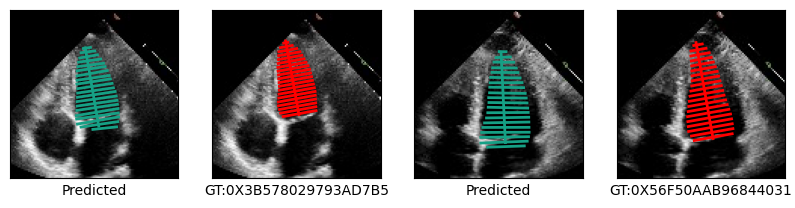

In [50]:
test_total = test_images.shape[0]
plt.subplots(1, 4, figsize=(10, 10))
for i, k in enumerate(np.random.randint(test_total, size=2)):
    img = test_images[k]
    img = img.reshape(-1, IMAGE_SIZE, IMAGE_SIZE, 3)
    pred_kps = model_2.predict(img)
    pred_kps = pred_kps.reshape(-1,NUM_KEYPOINTS) * IMAGE_SIZE
    kps = test_keypoints[k].reshape(-1,NUM_KEYPOINTS) * IMAGE_SIZE
    plt.subplot(1, 4, 2*i+1)
    plt.gca().set_yticklabels([])
    plt.gca().set_xticklabels([])
    plt.gca().set_xticks([])
    plt.gca().set_yticks([])
    VisualizeSampleImages(img[0], pred_kps, col='#16a085')
    plt.xlabel(f"Predicted")
    plt.subplot(1, 4, 2*i+2)
    plt.gca().set_yticklabels([])
    plt.gca().set_xticklabels([])
    plt.gca().set_xticks([])
    plt.gca().set_yticks([])
    VisualizeSampleImages(img[0], kps)
    plt.xlabel(f"GT:{train_ids[k]}")

Đang quét toàn bộ tập Test...

BÁO CÁO THỐNG KÊ KẾT QUẢ TEST
Tổng số ảnh đã kiểm tra: 2552 ảnh
Khoảng cách lệch nhỏ nhất: 0.54 pixels (AI đoán chuẩn xác)
Khoảng cách lệch TRUNG BÌNH: 2.99 pixels (Chất lượng tổng thể)
Khoảng cách lệch LỚN NHẤT  : 16.74 pixels (Ca tồi tệ nhất)


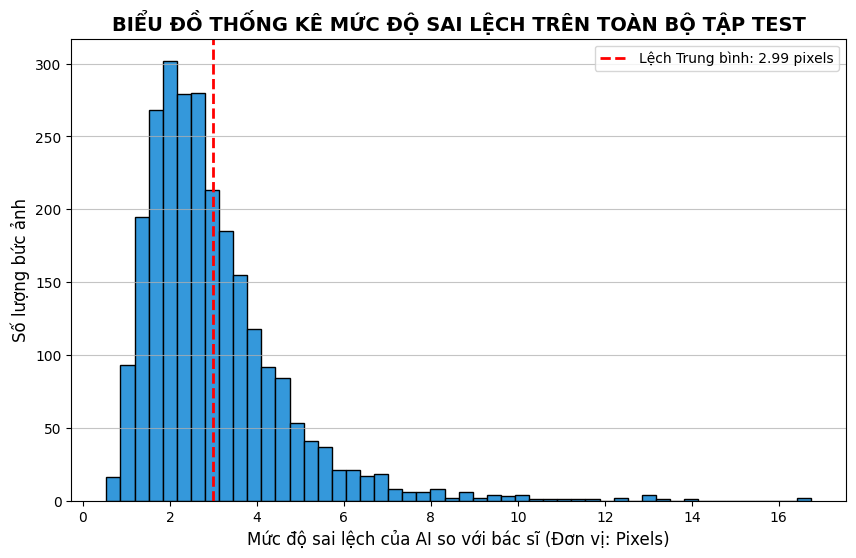

In [51]:


# 1. Lấy kết quả dự đoán của toàn bộ Test Set
print("Đang quét toàn bộ tập Test...")
predicted_test_kps = model_2.predict(test_images, verbose=0)

# 2. Đo khoảng cách sai lệch (tính bằng Pixel) cho từng bức ảnh
# Phép nhân với IMAGE_SIZE (112) giúp quy đổi sai số từ tỷ lệ [0-1] ra số Pixel vật lý trên ảnh
errors_in_pixels = np.mean(np.abs(predicted_test_kps - test_keypoints_conv), axis=(1, 2, 3)) * IMAGE_SIZE

# 3. Tính toán các thông số thống kê tổng quát
avg_err = np.mean(errors_in_pixels)
max_err = np.max(errors_in_pixels)
min_err = np.min(errors_in_pixels)

# 4. Vẽ biểu đồ Histogram (Phân bố mức độ sai lệch)
plt.figure(figsize=(10, 6))
# Chia thành 50 cột, đếm xem có bao nhiêu ảnh rơi vào mức sai số tương ứng
plt.hist(errors_in_pixels, bins=50, color='#3498db', edgecolor='black')
plt.axvline(avg_err, color='red', linestyle='dashed', linewidth=2, label=f'Lệch Trung bình: {avg_err:.2f} pixels')

plt.title('BIỂU ĐỒ THỐNG KÊ MỨC ĐỘ SAI LỆCH TRÊN TOÀN BỘ TẬP TEST', fontsize=14, fontweight='bold')
plt.xlabel('Mức độ sai lệch của AI so với bác sĩ (Đơn vị: Pixels)', fontsize=12)
plt.ylabel('Số lượng bức ảnh', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.75)

# In báo cáo ra màn hình
print("\n" + "=" * 50)
print("BÁO CÁO THỐNG KÊ KẾT QUẢ TEST")
print("=" * 50)
print(f"Tổng số ảnh đã kiểm tra: {len(errors_in_pixels)} ảnh")
print(f"Khoảng cách lệch nhỏ nhất: {min_err:.2f} pixels (AI đoán chuẩn xác)")
print(f"Khoảng cách lệch TRUNG BÌNH: {avg_err:.2f} pixels (Chất lượng tổng thể)")
print(f"Khoảng cách lệch LỚN NHẤT  : {max_err:.2f} pixels (Ca tồi tệ nhất)")
print("=" * 50)

plt.show()


⚠️ Phát hiện 1000 bức ảnh có độ lệch LỚN HƠN mức trung bình (2.99 pixels).
Hệ thống đang bốc ngẫu nhiên 5 ca bệnh trong nhóm 1000 ca khó này để hiển thị...



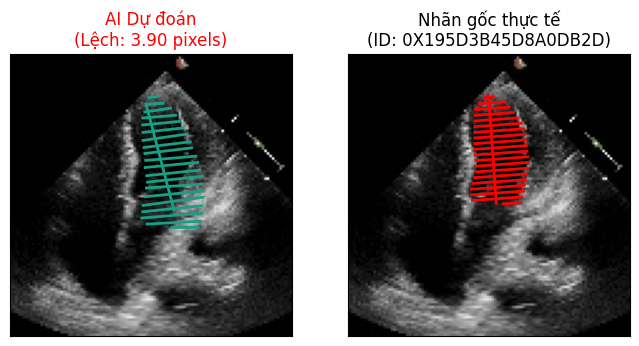

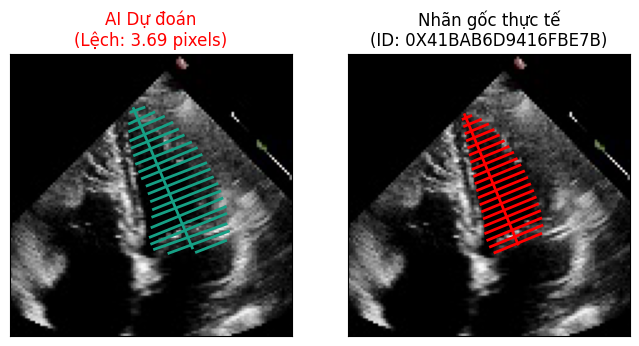

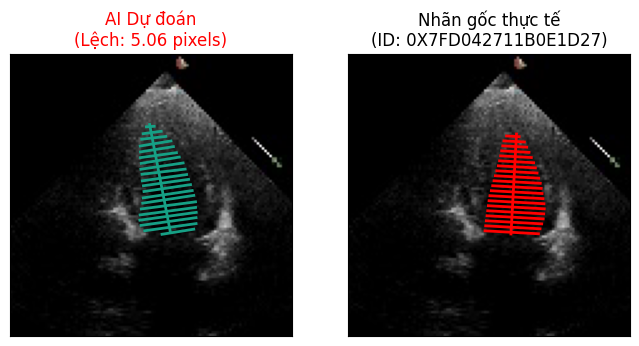

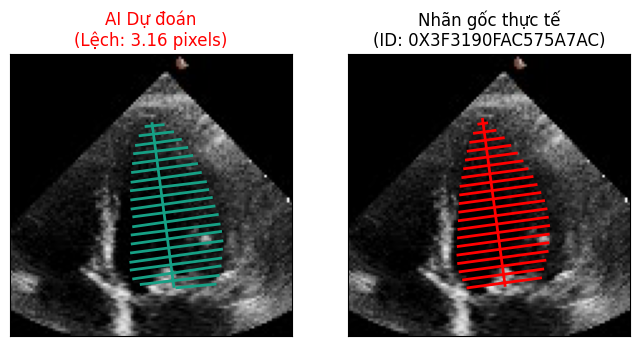

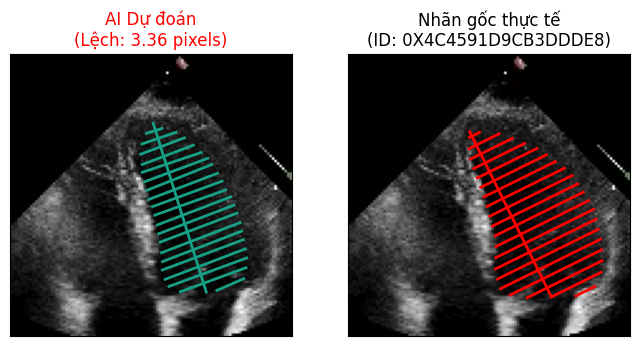

In [52]:
import random

# 1. Tìm vị trí (index) của TẤT CẢ các ảnh có độ lệch > Mức trung bình
bad_indices = np.where(errors_in_pixels > avg_err)[0]
total_bad = len(bad_indices)

print(f"⚠️ Phát hiện {total_bad} bức ảnh có độ lệch LỚN HƠN mức trung bình ({avg_err:.2f} pixels).")
print(f"Hệ thống đang bốc ngẫu nhiên 5 ca bệnh trong nhóm {total_bad} ca khó này để hiển thị...\n")

# 2. Bốc ngẫu nhiên 5 ảnh (Biện pháp chống treo máy)
num_samples = min(5, total_bad) # Giới hạn tối đa 5 ảnh
random_bad_indices = random.sample(list(bad_indices), num_samples)

# 3. Vẽ biểu đồ đối chứng cho các ảnh vừa bốc được
for idx in random_bad_indices:
    img = test_images[idx]
    
    # Lấy tọa độ pixel chuẩn xác
    pred_kps = predicted_test_kps[idx].reshape(-1, NUM_KEYPOINTS) * IMAGE_SIZE
    true_kps = test_keypoints_conv[idx].reshape(-1, NUM_KEYPOINTS) * IMAGE_SIZE
    
    # Khởi tạo khung vẽ 2 cột
    plt.subplots(1, 2, figsize=(8, 4))
    
    # --- Ảnh AI tự vẽ (Bên trái) ---
    plt.subplot(1, 2, 1)
    plt.gca().set_yticklabels([]); plt.gca().set_xticklabels([])
    plt.gca().set_xticks([]); plt.gca().set_yticks([])
    VisualizeSampleImages(img, pred_kps, col='#16a085') 
    plt.title(f"AI Dự đoán\n(Lệch: {errors_in_pixels[idx]:.2f} pixels)", color='red')
    
    # --- Ảnh Nhãn gốc của bác sĩ (Bên phải) ---
    plt.subplot(1, 2, 2)
    plt.gca().set_yticklabels([]); plt.gca().set_xticklabels([])
    plt.gca().set_xticks([]); plt.gca().set_yticks([])
    VisualizeSampleImages(img, true_kps, col='red')
    plt.title(f"Nhãn gốc thực tế\n(ID: {test_ids[idx]})")
    
    plt.show()


# PHẦN 8 — TÍNH EJECTION FRACTION (EF)

Add some utility functions for the calculation

In [53]:
import math

In [54]:
def calculate_disk_area(x1, y1, x2, y2):
    dist = np.linalg.norm(np.array((x1, y1)) - np.array((x2, y2)))
    r = dist/2
    area = np.pi * r * r
    return area
    

**Các tham số (Đầu vào):**

**x1, y1:** Tọa độ của điểm ảnh (pixel) nằm ở mép bên trái buồng tim.
**x2, y2:** Tọa độ của điểm ảnh nằm ở mép bên phải buồng tim (đối diện với điểm trái).

**Đầu ra:**

**area:** Giá trị diện tích mặt cắt ngang của chiếc đĩa đó (tính bằng đơn vị $pixel^2$).




In [55]:
def calculate_volume(keypoints):
    '''
        keypoints: shape is [1, NUM_KEYPOINTS]
    '''
    ## first 4 is the long axis points
    x1, y1, x2, y2 = keypoints[0,0], keypoints[0,1], keypoints[0,2], keypoints[0,3]
    distance = np.linalg.norm(np.array((x1, y1)) - np.array((x2, y2)))
    height_of_disk = distance/20
    accumalated_areas = []
    for i in range(4, NUM_KEYPOINTS, 4):
        accumalated_areas.append(calculate_disk_area(keypoints[0,i], keypoints[0,i+1], 
                                                     keypoints[0][i+2], keypoints[0][i+3]))
        
    xa, ya, xb, yb = keypoints[0,4], keypoints[0,5], keypoints[0,6], keypoints[0,7]
    xc, yc, xd, yd = keypoints[0,8], keypoints[0,9], keypoints[0,10], keypoints[0,11]
    ## Calculate the distance between the 2 adjacent parallel lines. This will be alternate height of 
    ## the disk
    m = (yb-ya)/(xb-xa)
    c1 = yb - m*xb
    c2 = yd - m*xd
    alt_height_of_disk = abs(c1-c2)/math.sqrt(1+m*m)
    volume = sum(accumalated_areas)*height_of_disk
    return volume



**Mục đích:**
Hàm `calculate_volume` được dùng để hiện thực hóa **Phương pháp Simpson (Method of Disks)** - chuẩn mực vàng trong siêu âm tim. Nó có nhiệm vụ biến mảng tọa độ 2D (những đường kẻ ngang buồng tim) thành một mô hình 3D (bao gồm 20 chiếc đĩa mỏng xếp chồng lên nhau) để ước lượng tổng Thể tích (Volume) của tâm thất trái.

**Đầu vào (Tham số):**
*   **`keypoints`**: Mảng mảng một chiều chứa 84 con số (bao gồm tọa độ X, Y của 21 cặp điểm). Đây có thể là nhãn gốc do bác sĩ vẽ, hoặc tọa độ do mô hình AI dự đoán ra.

**Đầu ra:**
*   **`volume`**: Thể tích ước tính của toàn bộ buồng tim (Tính theo đơn vị $pixel^3$).

**Cách hoạt động chi tiết:**

1.  **Tìm chiều cao của đĩa (`height_of_disk`)**:
    *   Hàm lấy 4 giá trị đầu tiên của mảng (`x1, y1, x2, y2`) là tọa độ của **Trục dọc (Long axis)** – đoạn thẳng chạy từ đỉnh tim đến đáy tim.
    *   Nó tính độ dài của Trục dọc này (`distance`), sau đó chia đều cho 20 (`distance/20`). Con số này chính là **chiều cao (độ dày)** tiêu chuẩn của mỗi chiếc đĩa.
2.  **Tính tổng diện tích các mặt đĩa (`accumalated_areas`)**:
    *   Hàm dùng một vòng lặp (`for i in range...`) để duyệt qua 80 con số tọa độ còn lại. Do mỗi chiếc đĩa cần 2 điểm mép biên (trái và phải, tổng là 4 tọa độ x,y), vòng lặp sẽ nhảy bước 4 (`step=4`) qua đúng 20 lần.
    *   Ở mỗi lần lặp, nó gọi hàm `calculate_disk_area` (đã giải thích ở trên) để tính diện tích mặt cắt hình tròn của lát cắt đó, sau đó cất kết quả vào danh sách `accumalated_areas`.
3.  **Phần code thừa (Chỉ mang tính chất tham khảo)**:
    *   Từ đoạn `xa, ya...` cho đến `alt_height_of_disk` là một thuật toán nâng cao để tính **"chiều cao luân phiên"** (khoảng cách đường vuông góc giữa 2 nét vẽ song song kề nhau). 


4.  **Tính Thể tích cuối cùng (`volume`)**:
    *   Áp dụng nguyên lý Hình học không gian, tổng thể tích = $\sum$ (Diện tích mặt đáy $\times$ Chiều cao).
    *   Hàm cộng dồn toàn bộ diện tích của 20 mặt đĩa (`sum(accumalated_areas)`), sau đó nhân chung với độ dày (`height_of_disk`) đã tính ở bước 1 để ra được Thể tích tổng của tâm thất trái.

In [56]:
def calculate_EF(ED_keypoints, ES_keypoints):
    '''
        ED_keypoints: shape [1, NUM_KEYPOINTS]
        ES_keypoints: shape [1, NUM_KEYPOINTS]
    '''
    ED_volume = calculate_volume(ED_keypoints)
    ES_volume = calculate_volume(ES_keypoints)
    EF = ((ED_volume - ES_volume) / ED_volume) * 100
    return EF

**Các tham số (Đầu vào):**

**ED_keypoints** Mảng tọa độ ranh giới tim ở trạng thái Cuối tâm trương (End-Diastolic - ED). Đây là khoảnh khắc cơ tim giãn nở cực đại để hút đầy máu (thể tích đạt mức lớn nhất).

**ES_keypoints:** Mảng tọa độ ranh giới tim ở trạng thái Cuối tâm thu (End-Systolic - ES). Đây là khoảnh khắc cơ tim co thắt mạnh nhất để ép tống máu đi (thể tích tụt xuống mức nhỏ nhất).

**Đầu ra:**

**EF:** Chỉ số Phân suất tống máu, tính bằng Phần trăm (%) – Ví dụ: 65.5 có nghĩa là 65.5%. (Ghi chú y khoa: Người trưởng thành khỏe mạnh thường có chỉ số EF dao động từ 55% đến 70%).

In [57]:
def calculate_EFs(data_keypoints):
    '''
    data_keypoints: shape [None, 1, 1, NUM_KEYPOINTS]
    '''
    total = data_keypoints.shape[0]
    data_EFs = []
    for i in range(0, total, 2):
        ED_kps = data_keypoints[i].reshape(-1, NUM_KEYPOINTS) * IMAGE_SIZE
        ES_kps = data_keypoints[i+1].reshape(-1, NUM_KEYPOINTS) * IMAGE_SIZE
        EF = calculate_EF(ED_kps, ES_kps)
        data_EFs.append(EF)
    return data_EFs

**Các tham số (Đầu vào):**

**data_keypoints:** Một tensor (mảng đa chiều) chứa toàn bộ điểm tọa độ của tập dữ liệu. Nó có hình dáng [Tổng_số_ảnh, 1, 1, NUM_KEYPOINTS]. Mảng này có thể lấy từ Nhãn gốc (Ground Truth) hoặc lấy từ kết quả mà AI vừa dự đoán ra.

**Đầu ra:**

**data_EFs:** Một danh sách (List) lưu trữ tất cả các con số phần trăm EF của từng bệnh nhân được tìm thấy trong tập dữ liệu.

In [58]:
def build_dataframe_EFs(calculated_kps, predicted_kps):
    '''
        calculated_kps: shape [None, 1, 1, NUM_KEYPOINTS]
        predicted_kps: shape [None, 1, 1, NUM_KEYPOINTS]
    '''
    cal_efs = calculate_EFs(calculated_kps)
    pred_efs = calculate_EFs(predicted_kps)
    d = {'Actual_EF': cal_efs, 'Pred_EF': pred_efs}
    df = pd.DataFrame(data=d)
    act_lvef_class = []
    for i in df.Actual_EF:
        if i >= 50:
            act_lvef_class.append('Normal')
        elif i > 40:
            act_lvef_class.append('Mild')
        else:
            act_lvef_class.append('Abnormal')
    act_lvef_class = pd.Series(act_lvef_class, name='Actual_HFClass')
    act_lvef_class = act_lvef_class.astype('category')
    act_lvef_class = act_lvef_class.cat.set_categories(["Normal", "Mild", "Abnormal"], ordered=True)
    df['Actual_HFClass'] = act_lvef_class
    pred_lvef_class = []
    for i in df.Pred_EF:
        if i >= 50:
            pred_lvef_class.append('Normal')
        elif i > 40:
            pred_lvef_class.append('Mild')
        else:
            pred_lvef_class.append('Abnormal')
    pred_lvef_class = pd.Series(pred_lvef_class, name='Actual_HFClass')
    pred_lvef_class = pred_lvef_class.astype('category')
    pred_lvef_class = pred_lvef_class.cat.set_categories(["Normal", "Mild", "Abnormal"], ordered=True)
    df['Pred_HFClass'] = pred_lvef_class
    df['Diff_EFs'] = np.abs(df.Actual_EF - df.Pred_EF)
    return df


**Các tham số (Đầu vào):**
*   **`calculated_kps`**: Tọa độ chuẩn (Ground Truth) do bác sĩ vẽ. (Ghi chú: Tên biến tác giả đặt hơi dễ gây hiểu nhầm, lẽ ra nên gọi là `actual_kps`).
*   **`predicted_kps`**: Tọa độ do AI tự động dự đoán ra.

**Đầu ra:**
*   **`df`**: Một đối tượng bảng Pandas DataFrame chứa danh sách tất cả các bệnh nhân, bao gồm 5 cột dữ liệu: `% EF Thực tế`, `% EF AI đoán`, `Chẩn đoán thực tế`, `Chẩn đoán của AI`, và `Độ chênh lệch sai số`.



In [59]:
def get_predicted_points(data_images, model):
    '''
    data_images: shape [None, 112, 112, 3]
    '''
    data_kps = model.predict(data_images)
    return data_kps


**Mục đích:**
Hàm `get_predicted_points` đóng vai trò là một "Hàm bọc" (Wrapper function) đơn giản. Nhiệm vụ của nó là ra lệnh cho mô hình AI chạy phân tích hình ảnh và trả về danh sách các điểm tọa độ ranh giới tim (keypoints) mà nó tự động "nhìn thấy".

**Các tham số (Đầu vào):**
*   **`data_images`**: Một mảng (tensor) chứa lô các bức ảnh siêu âm mà bạn muốn mang đi dự đoán (kích thước mỗi bức ảnh là $112 \times 112$ pixel và có $3$ kênh màu RGB).
*   **`model`**: Bộ não trí tuệ nhân tạo (ví dụ như đối tượng `model_2`) đã được huấn luyện hoặc đã nạp file trọng số tốt nhất.

**Đầu ra:**
*   **`data_kps`**: Mảng chứa toàn bộ các điểm tọa độ do AI tự động tính toán. *(Ghi chú kỹ thuật: Các tọa độ ở bước này vẫn đang ở dạng nguyên bản (tỷ lệ $0 \rightarrow 1$), chưa được nhân với `IMAGE_SIZE` để quy đổi ra số Pixel thực tế).*



Get the predicted keypoints for training, validation and test images

In [60]:
predicted_train_kps = get_predicted_points(train_images, model_2)
predicted_val_kps = get_predicted_points(val_images, model_2)
predicted_test_kps = get_predicted_points(test_images, model_2)

466/466 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


Get the dataframe of the actual and predicted efs. Note that I am not taking the EF values from the original data, but calculated it from the original volume tracings. This will be compared to the EF values from the predicted volume tracings.

In [61]:
training_output_df = build_dataframe_EFs(train_keypoints_conv, predicted_train_kps)
val_output_df = build_dataframe_EFs(val_keypoints_conv, predicted_val_kps)
test_output_df = build_dataframe_EFs(test_keypoints_conv, predicted_test_kps)

I calculate the EF values for the training, validation, and test images and build a dataframe, which is visualized below.

In [62]:
training_output_df.head()
    

,Actual_EF,Pred_EF,Actual_HFClass,Pred_HFClass,Diff_EFs
0,63.431446,48.918850,Normal,Mild,14.512596
1,67.953201,46.981907,Normal,Mild,20.971294
2,63.979668,52.295502,Normal,Normal,11.684166
3,64.863213,66.511688,Normal,Normal,1.648476
4,53.416176,52.942413,Normal,Normal,0.473763


In [63]:
val_output_df.head()

,Actual_EF,Pred_EF,Actual_HFClass,Pred_HFClass,Diff_EFs
0,61.136978,49.249146,Normal,Mild,11.887833
1,61.378925,74.238930,Normal,Normal,12.860004
2,57.114594,18.585835,Normal,Abnormal,38.528759
3,40.686214,45.378529,Mild,Mild,4.692314
4,56.902348,59.227776,Normal,Normal,2.325428


In [64]:
test_output_df.head()

,Actual_EF,Pred_EF,Actual_HFClass,Pred_HFClass,Diff_EFs
0,58.404995,76.950851,Normal,Normal,18.545856
1,60.279316,50.302036,Normal,Normal,9.977280
2,32.038303,40.902210,Abnormal,Mild,8.863907
3,52.896248,5.034491,Normal,Abnormal,47.861755
4,56.311958,35.399063,Normal,Abnormal,20.912895


I see some negative EF values. Looking at 1 case with negative value, it looks like the long axis is not correct.

In [65]:
def VisualizeSingleData(data_images, data_keypoints, pred_keypoints, data_ids, index):
    print(f"Data id {data_ids[2*index]}")
    
    # Lấy ảnh và keypoints của frame ED (index chẵn)
    img_ED   = data_images[2*index]
    pred_ED  = pred_keypoints[2*index].reshape(-1, NUM_KEYPOINTS) * IMAGE_SIZE
    gt_ED    = data_keypoints[2*index].reshape(-1, NUM_KEYPOINTS) * IMAGE_SIZE

    # Lấy ảnh và keypoints của frame ES (index lẻ)
    img_ES   = data_images[2*index + 1]
    pred_ES  = pred_keypoints[2*index + 1].reshape(-1, NUM_KEYPOINTS) * IMAGE_SIZE
    gt_ES    = data_keypoints[2*index + 1].reshape(-1, NUM_KEYPOINTS) * IMAGE_SIZE

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle(f"Patient: {data_ids[2*index]}", fontsize=14, fontweight='bold')

    # Hàm tắt trục cho gọn
    def clean_axis(ax):
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_xticklabels([]); ax.set_yticklabels([])

    # --- Hàng 1: Frame ED ---
    # Cột 1: Ảnh gốc ED (không keypoints)
    axes[0, 0].imshow(img_ED)
    clean_axis(axes[0, 0])
    axes[0, 0].set_xlabel("ED — Ảnh Gốc", fontsize=11)

    # Cột 2: ED + Predicted keypoints
    axes[0, 1].imshow(img_ED)
    plt.sca(axes[0, 1])
    VisualizeSampleImages(img_ED, pred_ED, col='#16a085')
    clean_axis(axes[0, 1])
    axes[0, 1].set_xlabel("ED — AI Dự đoán", fontsize=11, color='#16a085')

    # Cột 3: ED + Ground Truth keypoints
    axes[0, 2].imshow(img_ED)
    plt.sca(axes[0, 2])
    VisualizeSampleImages(img_ED, gt_ED, col='red')
    clean_axis(axes[0, 2])
    axes[0, 2].set_xlabel(f"ED — Ground Truth", fontsize=11, color='red')

    # --- Hàng 2: Frame ES ---
    # Cột 1: Ảnh gốc ES (không keypoints)
    axes[1, 0].imshow(img_ES)
    clean_axis(axes[1, 0])
    axes[1, 0].set_xlabel("ES — Ảnh Gốc", fontsize=11)

    # Cột 2: ES + Predicted keypoints
    axes[1, 1].imshow(img_ES)
    plt.sca(axes[1, 1])
    VisualizeSampleImages(img_ES, pred_ES, col='#16a085')
    clean_axis(axes[1, 1])
    axes[1, 1].set_xlabel("ES — AI Dự đoán", fontsize=11, color='#16a085')

    # Cột 3: ES + Ground Truth keypoints
    axes[1, 2].imshow(img_ES)
    plt.sca(axes[1, 2])
    VisualizeSampleImages(img_ES, gt_ES, col='red')
    clean_axis(axes[1, 2])
    axes[1, 2].set_xlabel(f"ES — Ground Truth", fontsize=11, color='red')

    plt.tight_layout()



### Hàm `VisualizeSingleData`

**1. Mục đích:**
Hàm này đóng vai trò như một "Kính lúp phân tích lỗi" (Error Analysis Tool). Nó trực quan hóa dữ liệu của một ca siêu âm cụ thể bằng cách hiển thị song song 4 hình ảnh đối chứng. Mục tiêu là giúp người dùng so sánh trực tiếp bằng mắt thường xem đường vẽ ranh giới tâm thất trái của AI có bám sát với đường vẽ chuẩn của Bác sĩ (Ground Truth) ở cả hai pha co bóp của tim (Tâm trương - ED và Tâm thu - ES) hay không.

**2. Đầu vào (Tham số):**
*   **`data_images`**: Mảng đa chiều chứa dữ liệu hình ảnh siêu âm của toàn bộ tập dữ liệu (kích thước mỗi ảnh thường là $112 \times 112$).
*   **`data_keypoints`**: Mảng chứa tọa độ thực tế do chuyên gia y tế vẽ (Ground Truth).
*   **`pred_keypoints`**: Mảng chứa bộ tọa độ do AI tự động dự báo ra.
*   **`data_ids`**: Danh sách chứa mã định danh (ID/Tên file) của bệnh nhân tương ứng.
*   **`index`**: Vị trí thứ tự của bệnh nhân bạn muốn xem trong mảng dữ liệu. *(Ghi chú kỹ thuật: Do mỗi bệnh nhân chiếm 2 dòng dữ liệu liên tiếp cho pha ED và ES, nên ảnh ED sẽ nằm ở vị trí `2*index` và ảnh ES nằm ở vị trí `2*index + 1`).*

**3. Đầu ra:**
*   Hàm không có giá trị trả về (`return None`).
*   **Hiệu ứng phụ (Side effect):** Kết xuất trực tiếp ra giao diện màn hình một biểu đồ (`matplotlib`) nằm ngang gồm 4 bức ảnh đặt cạnh nhau, bao gồm:
    *   Ảnh pha ED + Viền do AI vẽ.
    *   Ảnh pha ED + Viền do Bác sĩ vẽ.
    *   Ảnh pha ES + Viền do AI vẽ.
    *   Ảnh pha ES + Viền do Bác sĩ vẽ.


In [66]:
error_list = training_output_df.query('Actual_EF < 0').index.tolist()    
## Errors in training data
for i, err in enumerate(error_list):
    VisualizeSingleData(train_images, train_keypoints_conv, predicted_train_kps, train_ids, err)
    plt.show()

Data id 0X4154F112065C857B


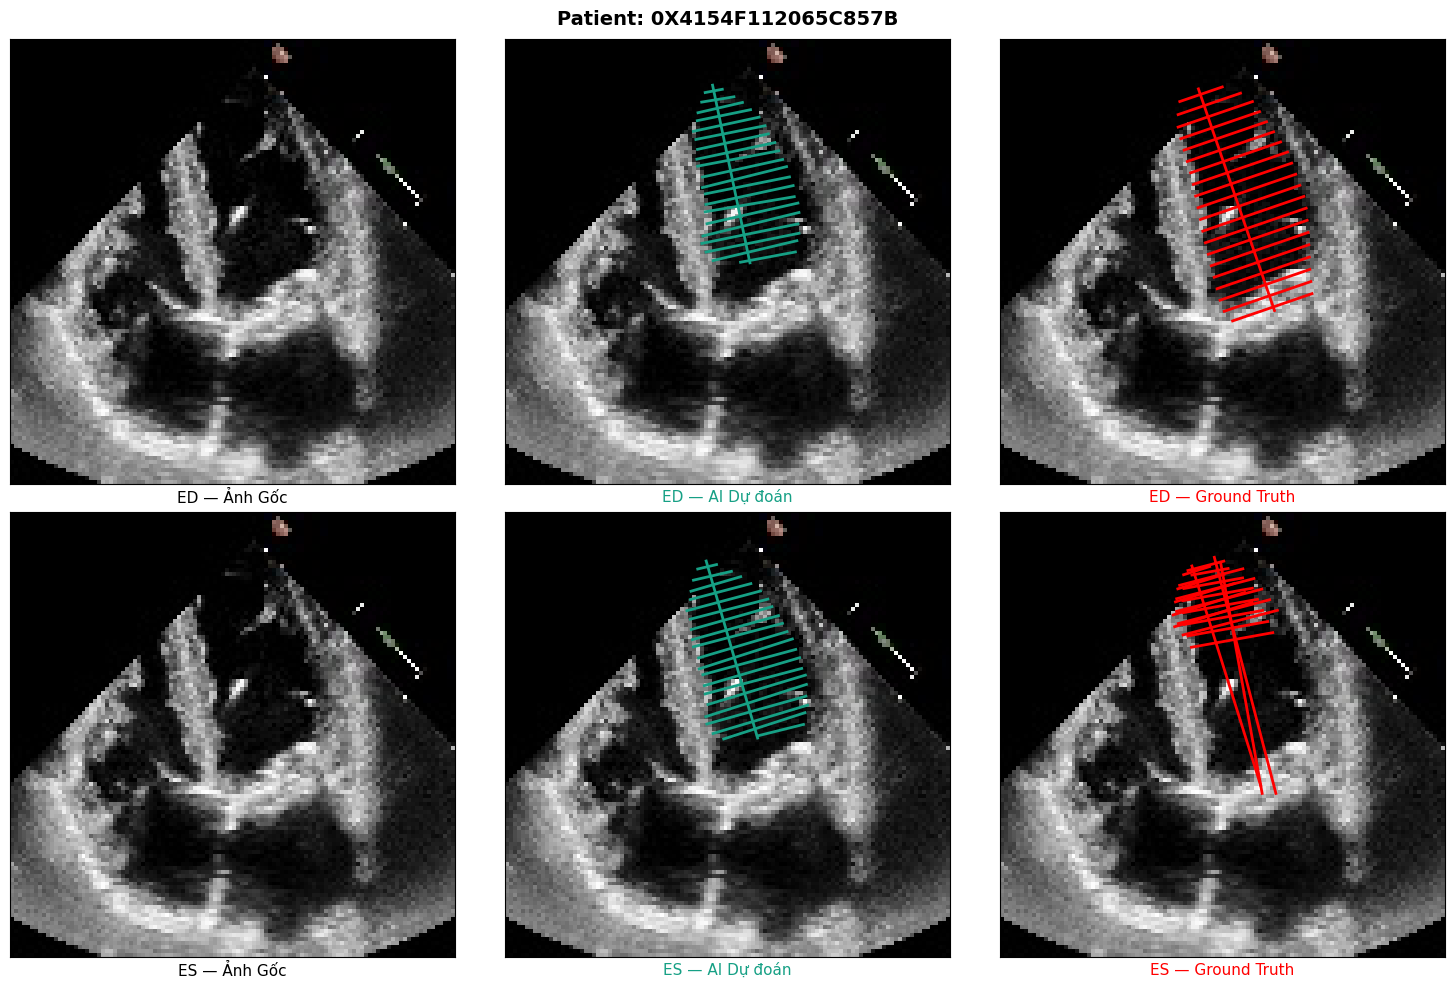

In [67]:
error_list_val = val_output_df.query('Actual_EF < 0').index.tolist()
## Errors in validation data
for err in error_list_val:
    VisualizeSingleData(val_images, val_keypoints_conv, predicted_val_kps, val_ids, err)
    plt.show()

Data id 0X500FC4E8716B0A8F


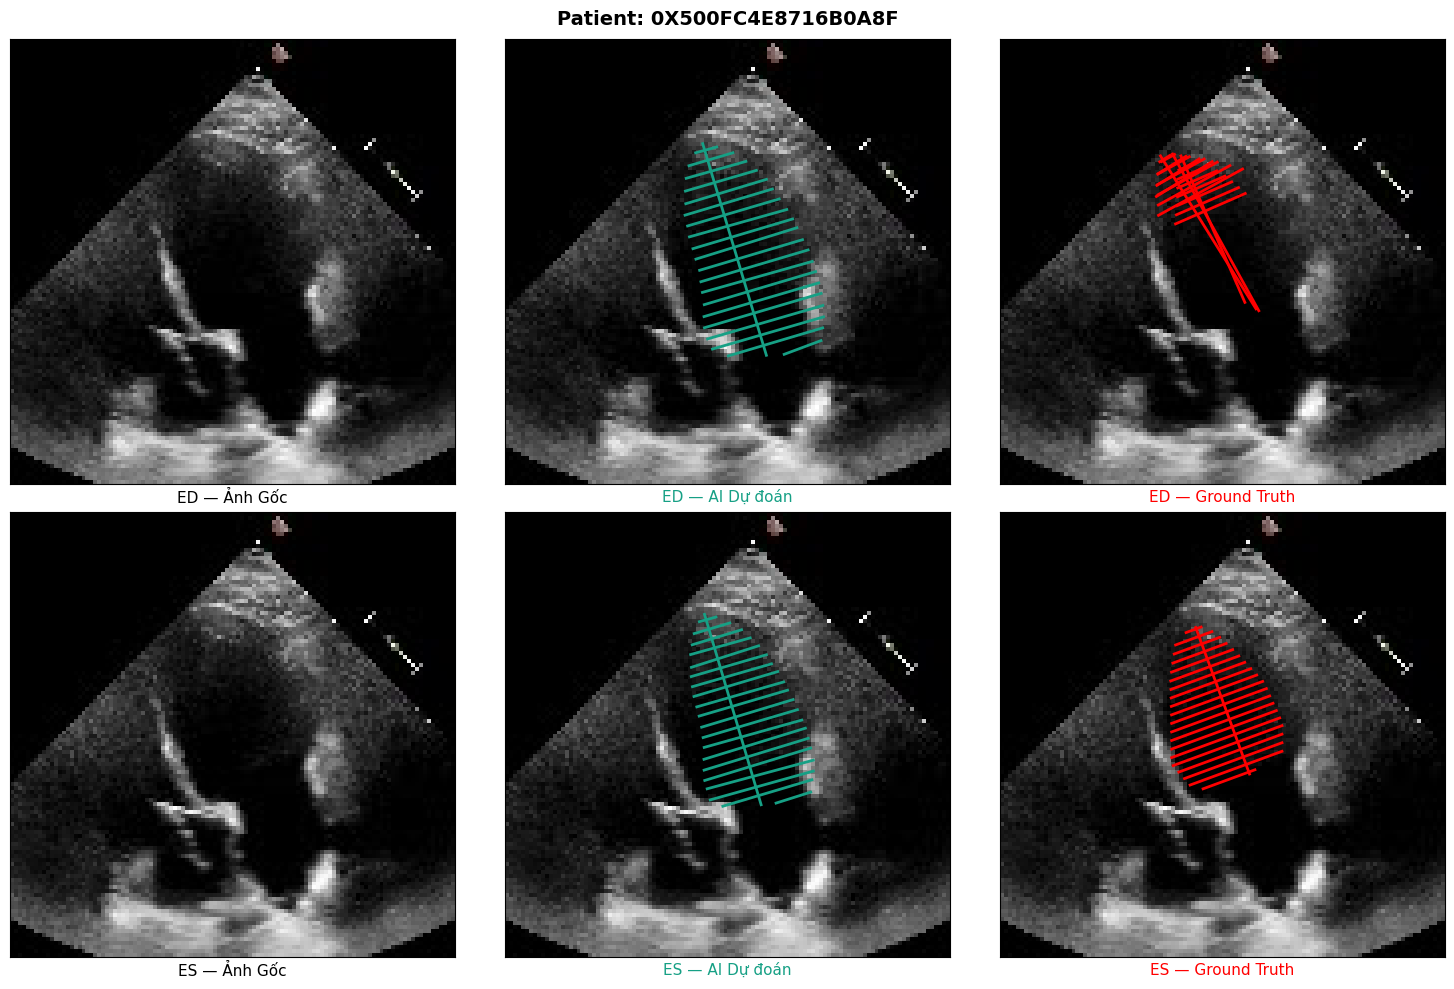

In [68]:
error_list_test = test_output_df.query('Actual_EF < 0').index.tolist()
## Errors in validation data
for err in error_list_test:
    VisualizeSingleData(test_images, test_keypoints_conv, predicted_test_kps, test_ids, err)
    plt.show()

266
-5.0938425
Data id 0X633BC22840D1D199


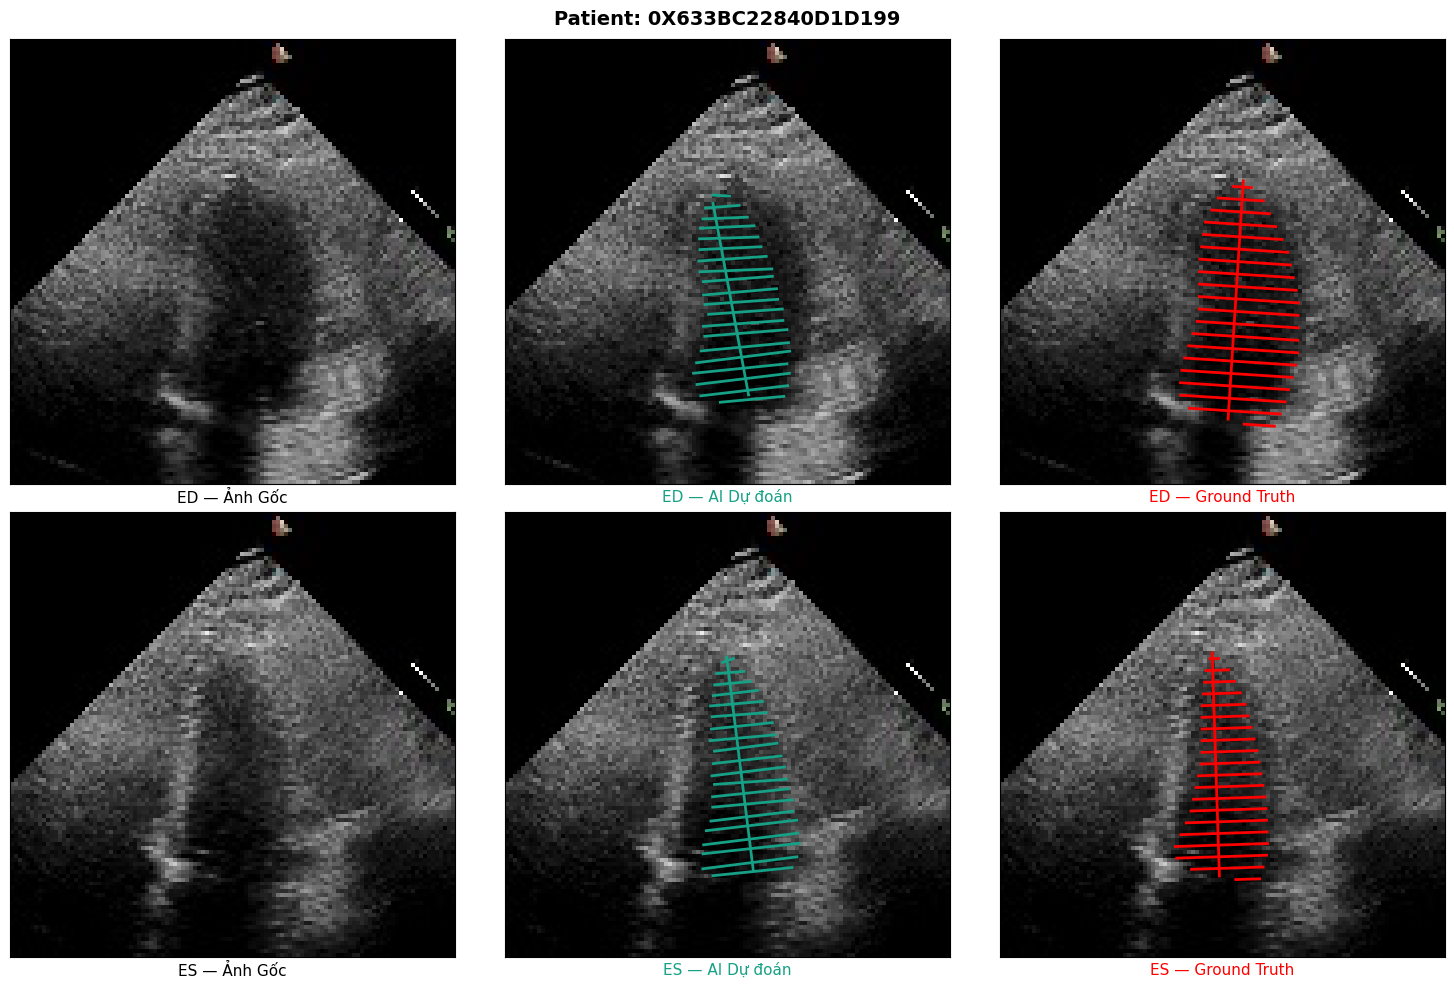

-28.726446
Data id 0X20C709BA520B3393


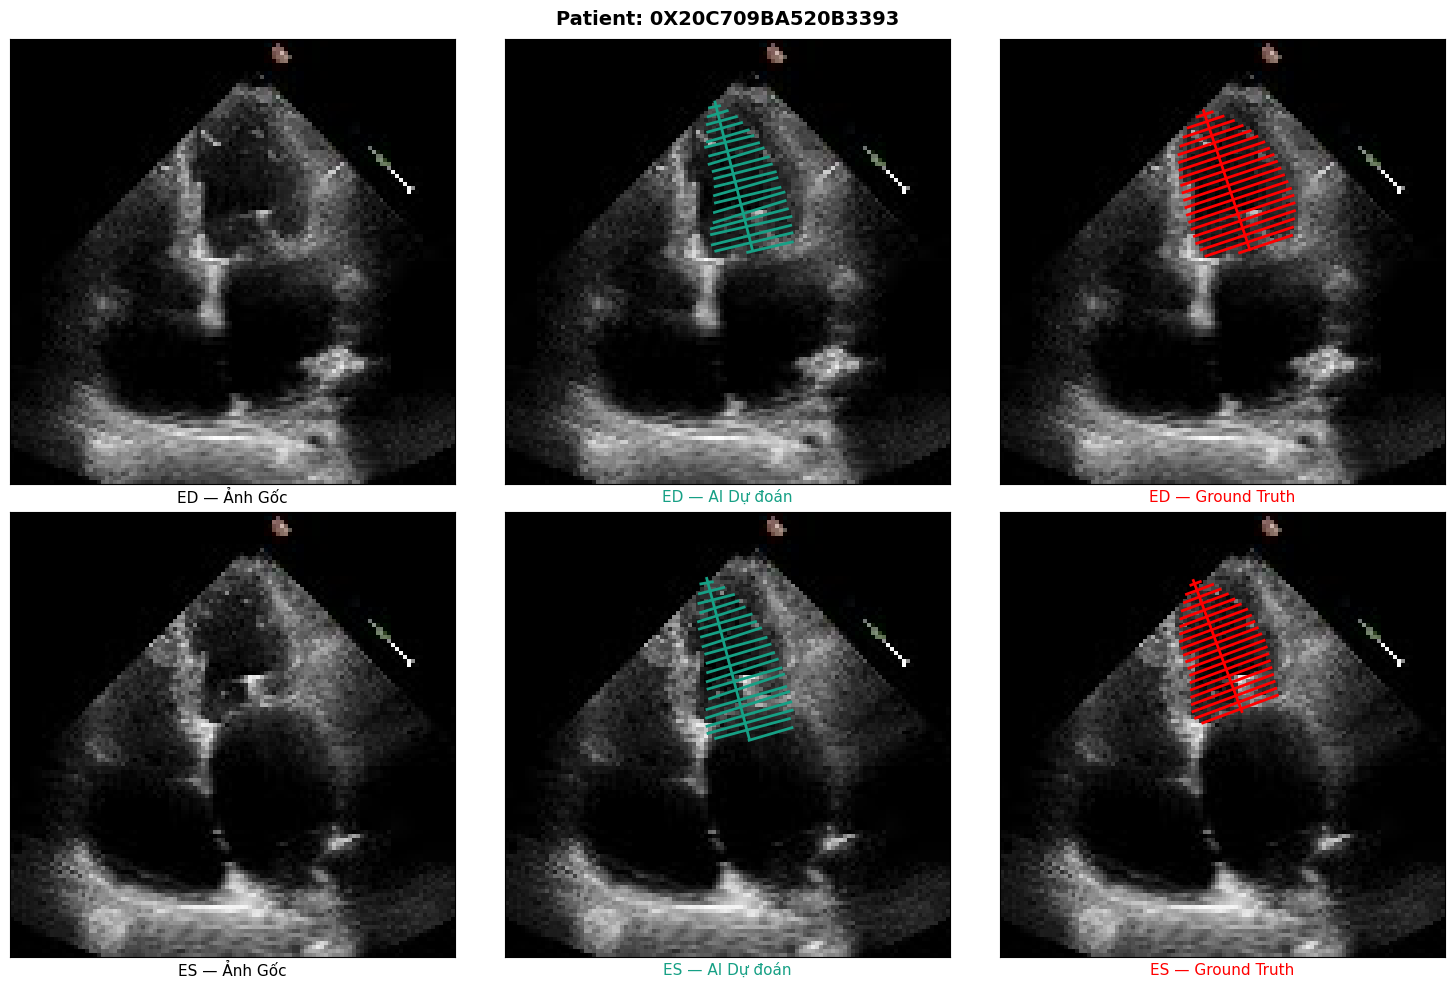

-9.591189
Data id 0X56C0487D888C3C2E


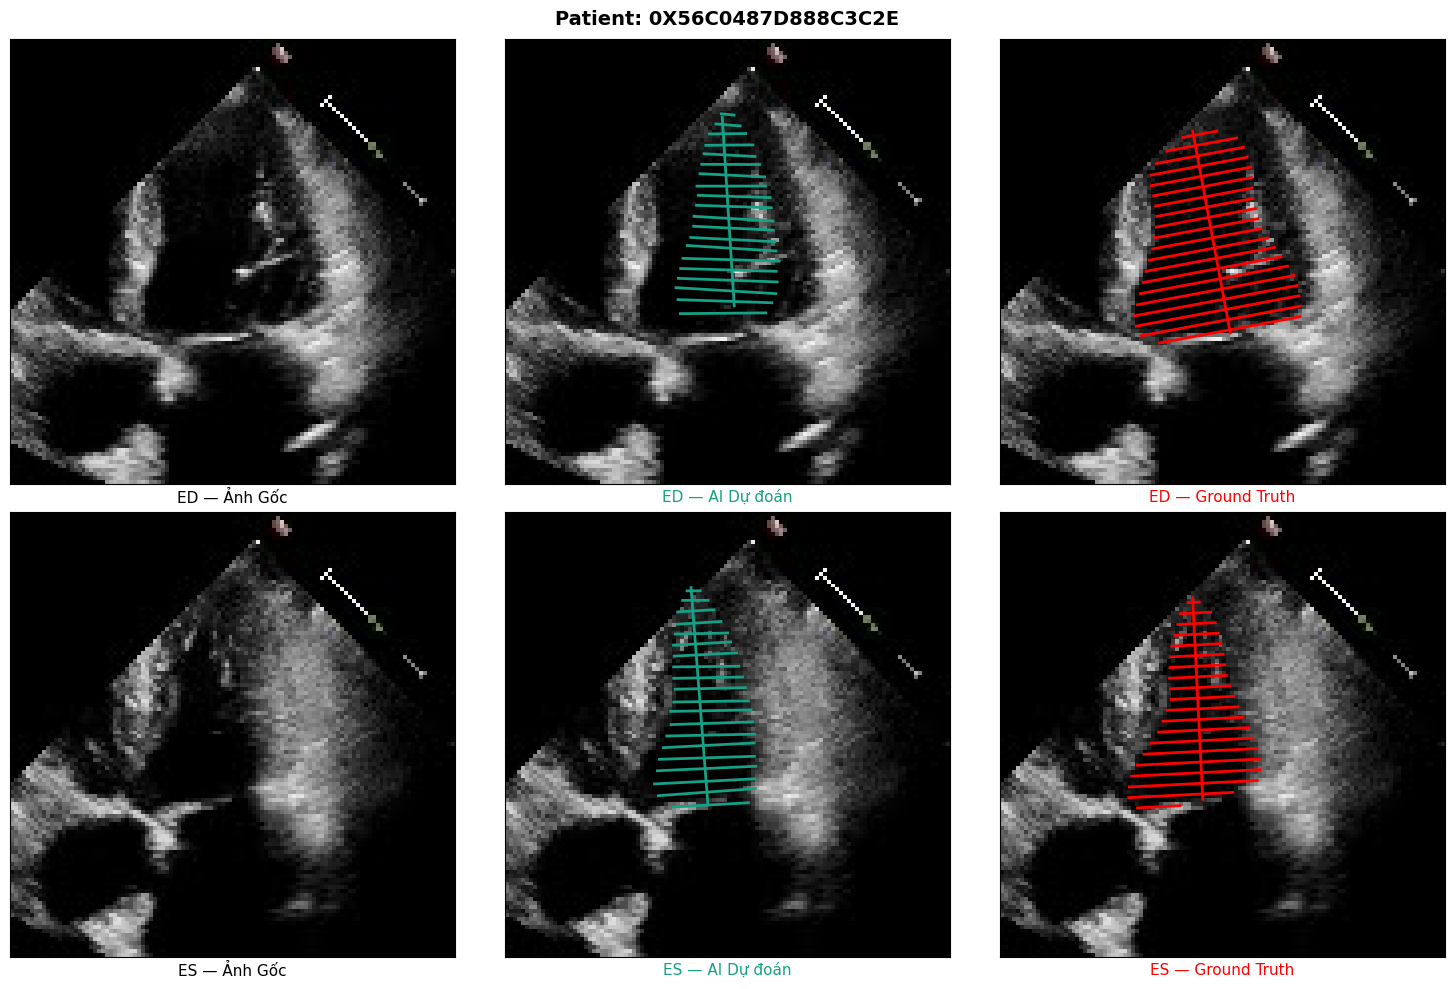

-8.123695
Data id 0X35DE4C4E8984305E


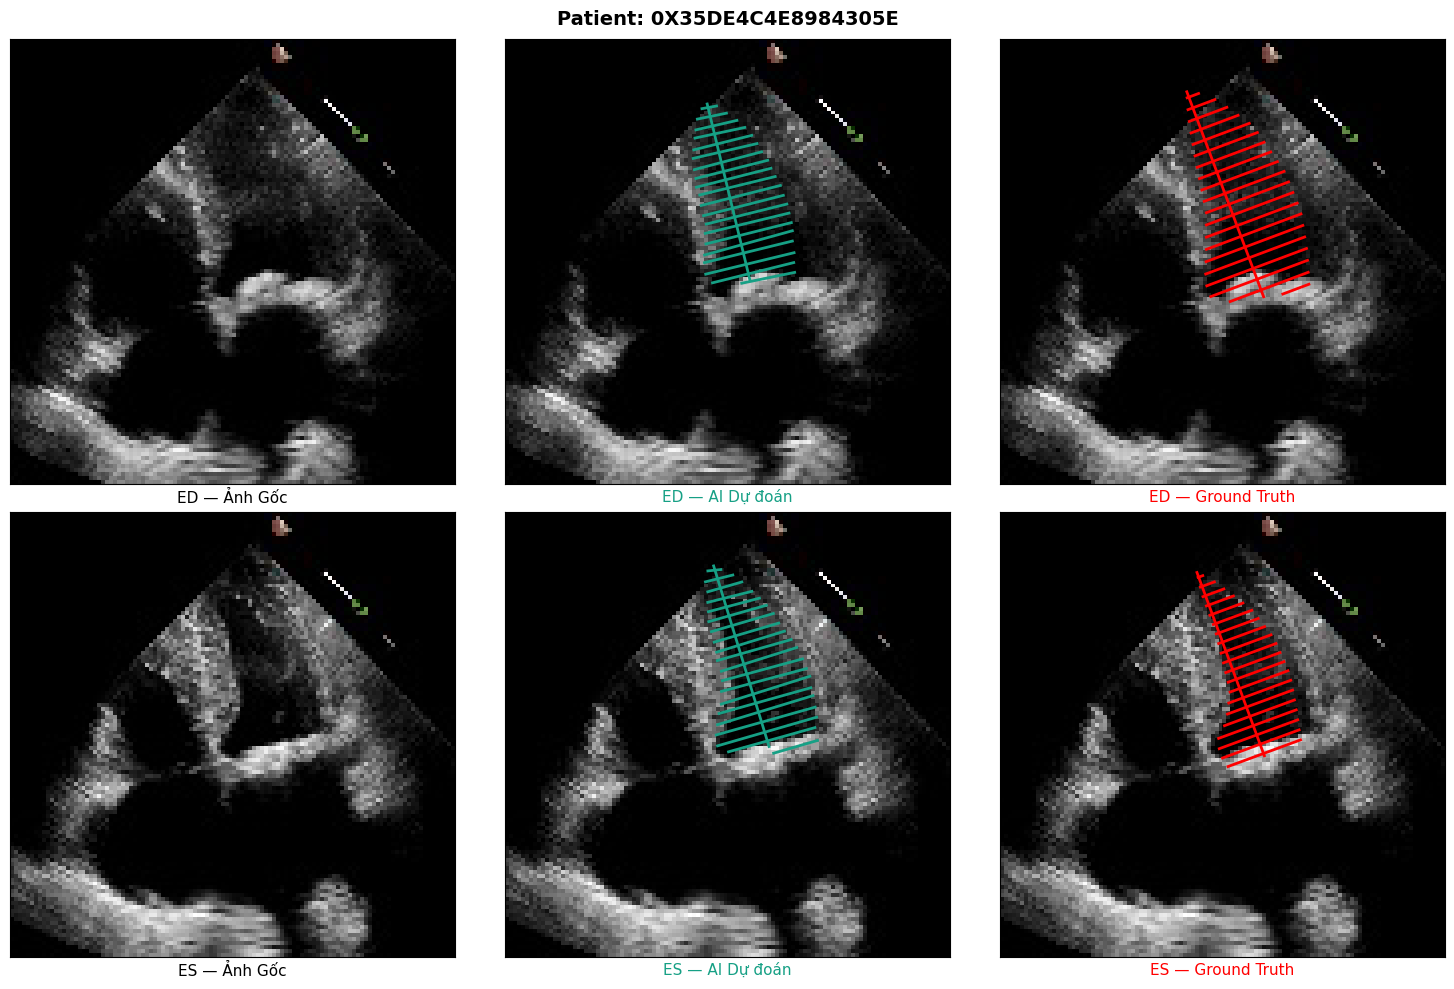

-10.048878
Data id 0X163A374094D066E8


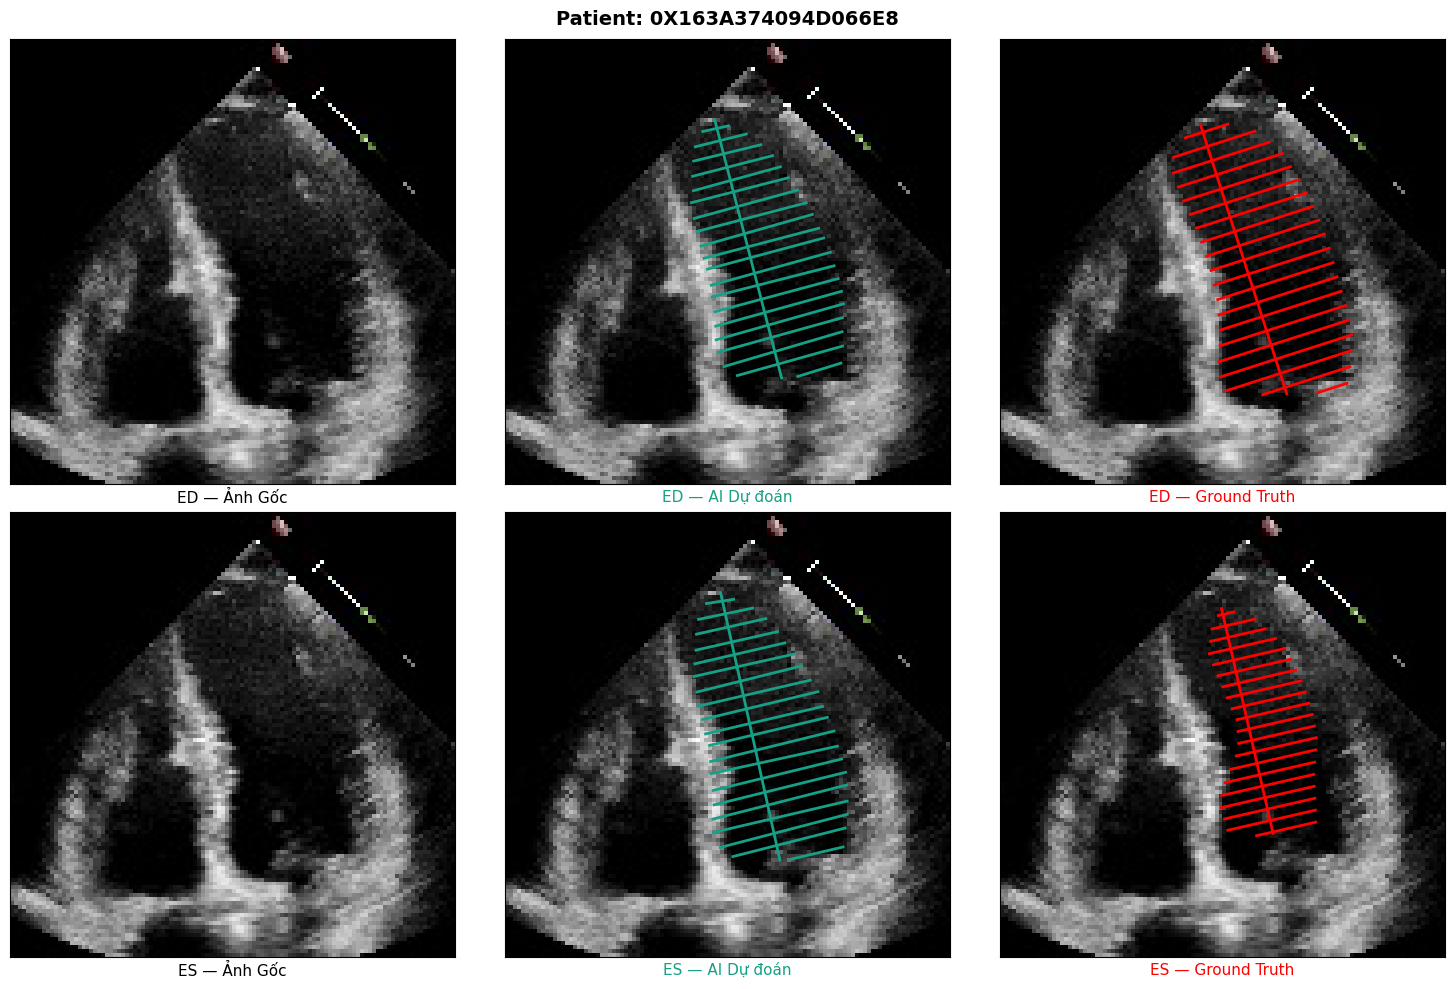

-12.209693
Data id 0X470FA78D91CC7397


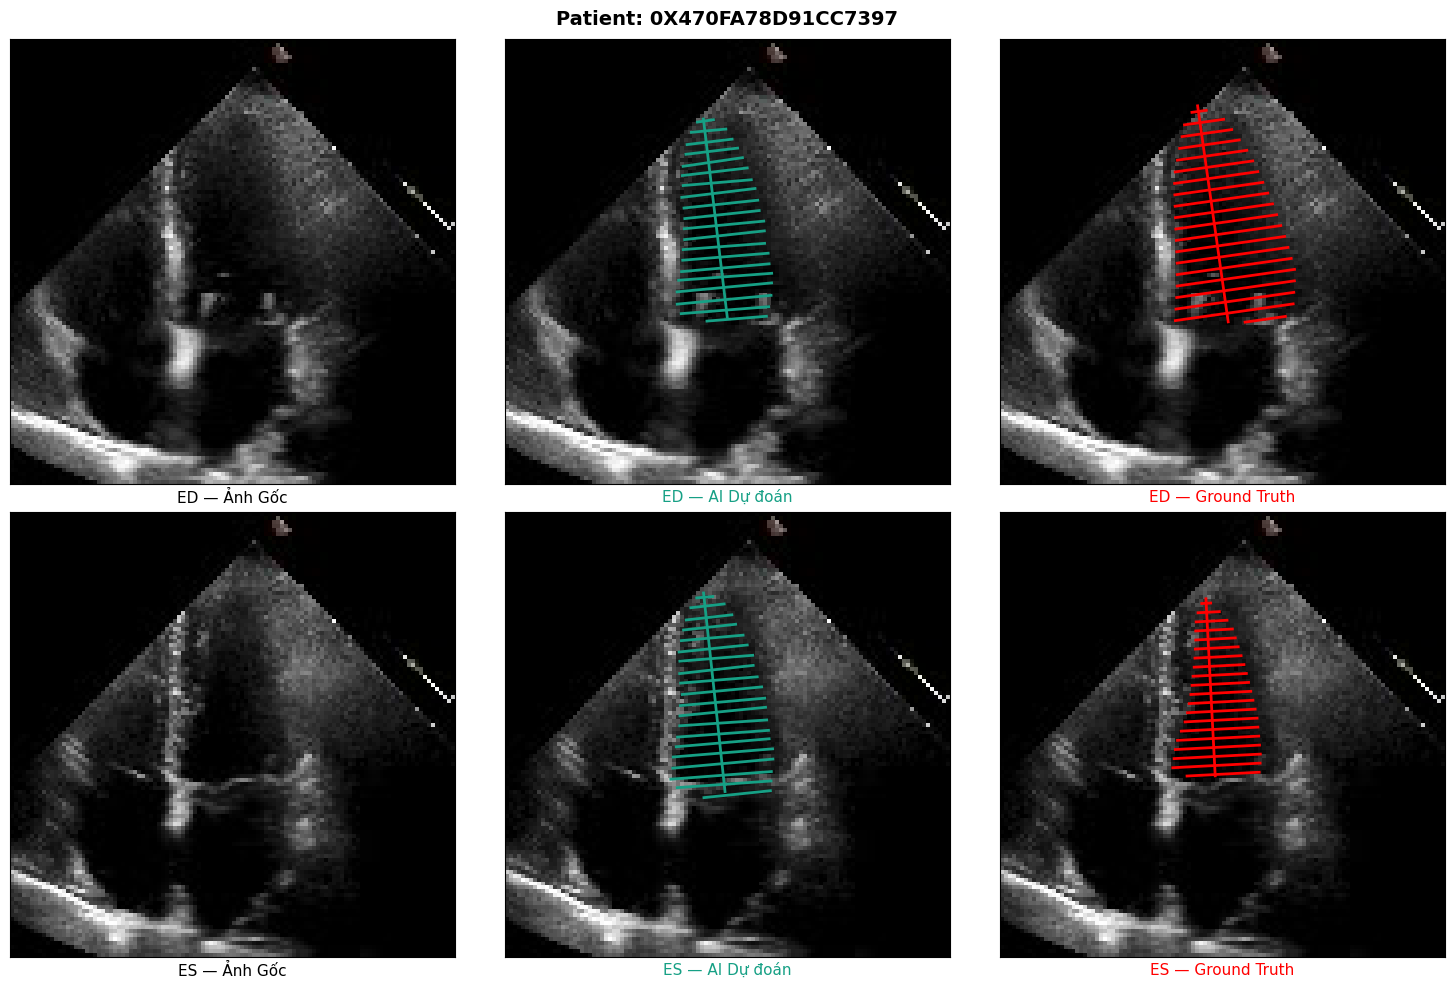

-1.5584209
Data id 0X744E923850EFD4BA


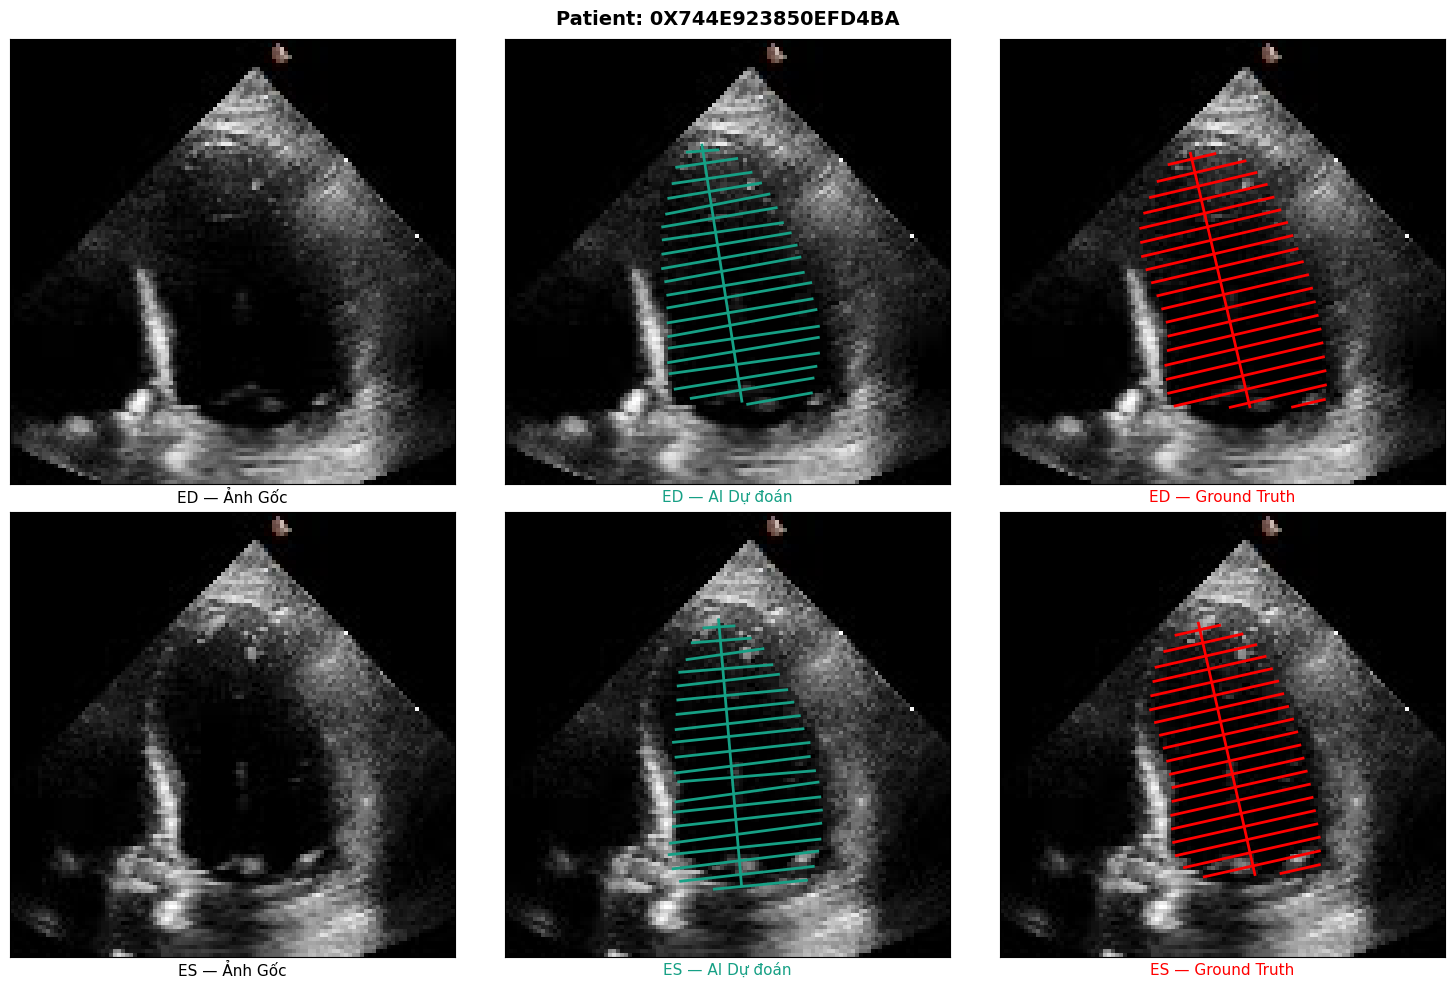

In [69]:
error_list = training_output_df.query('Pred_EF < 0').index.tolist()
print(len(error_list))
## Errors in Training data
for i, err in enumerate(error_list):
    print(training_output_df.Pred_EF[err])
    VisualizeSingleData(train_images, train_keypoints_conv, predicted_train_kps, train_ids, err)
    plt.show()
    if i == 6:
        break

Số lượng ca AI đoán âm (sai nặng) trên tập Test: 81 ca
Đang hiển thị các ca bệnh bị AI chẩn đoán lỗi trong tập Test...

=> Bệnh nhân Test thứ 1: AI dự đoán EF = -34.05%
Data id 0X386924A6B430342A


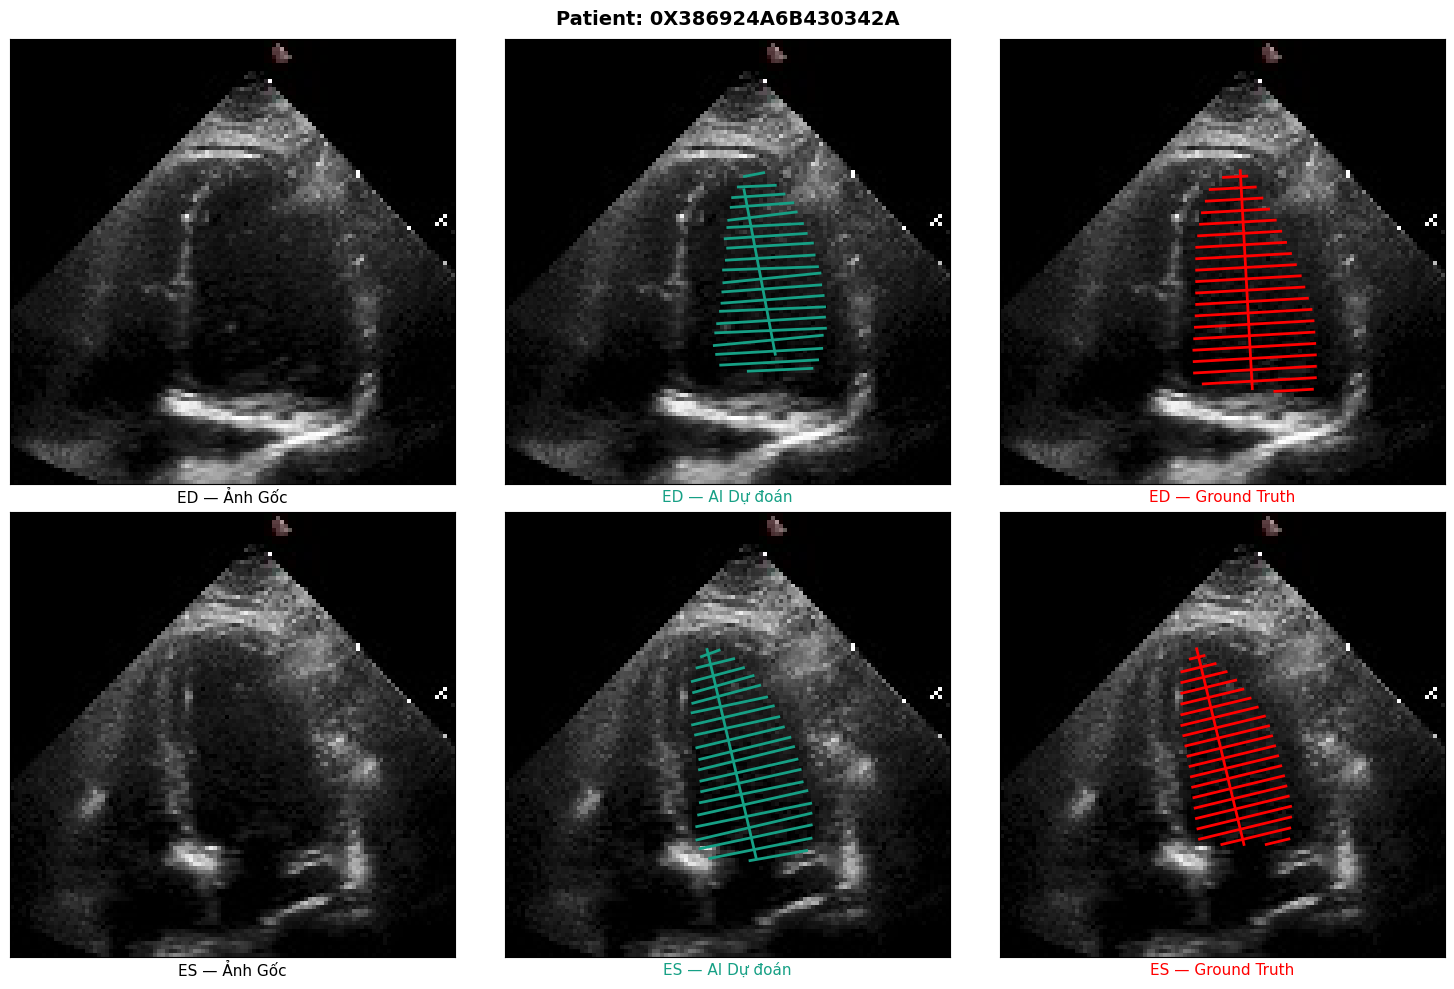


=> Bệnh nhân Test thứ 2: AI dự đoán EF = -28.32%
Data id 0X5C41AF3F25757D5B


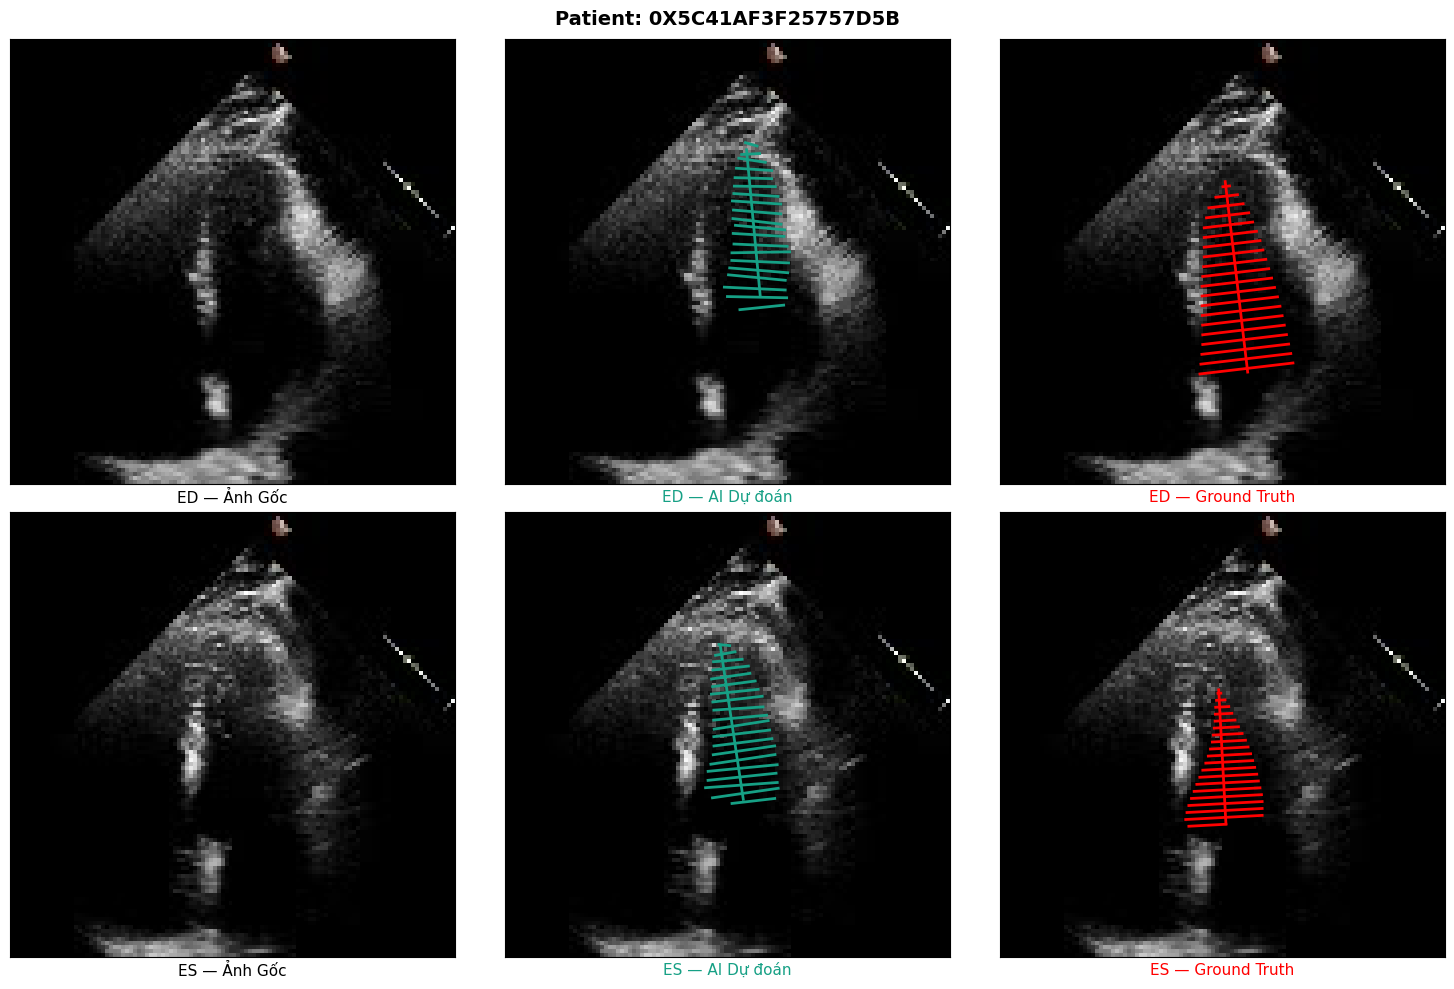


=> Bệnh nhân Test thứ 3: AI dự đoán EF = -6.83%
Data id 0X5746FD1045390A93


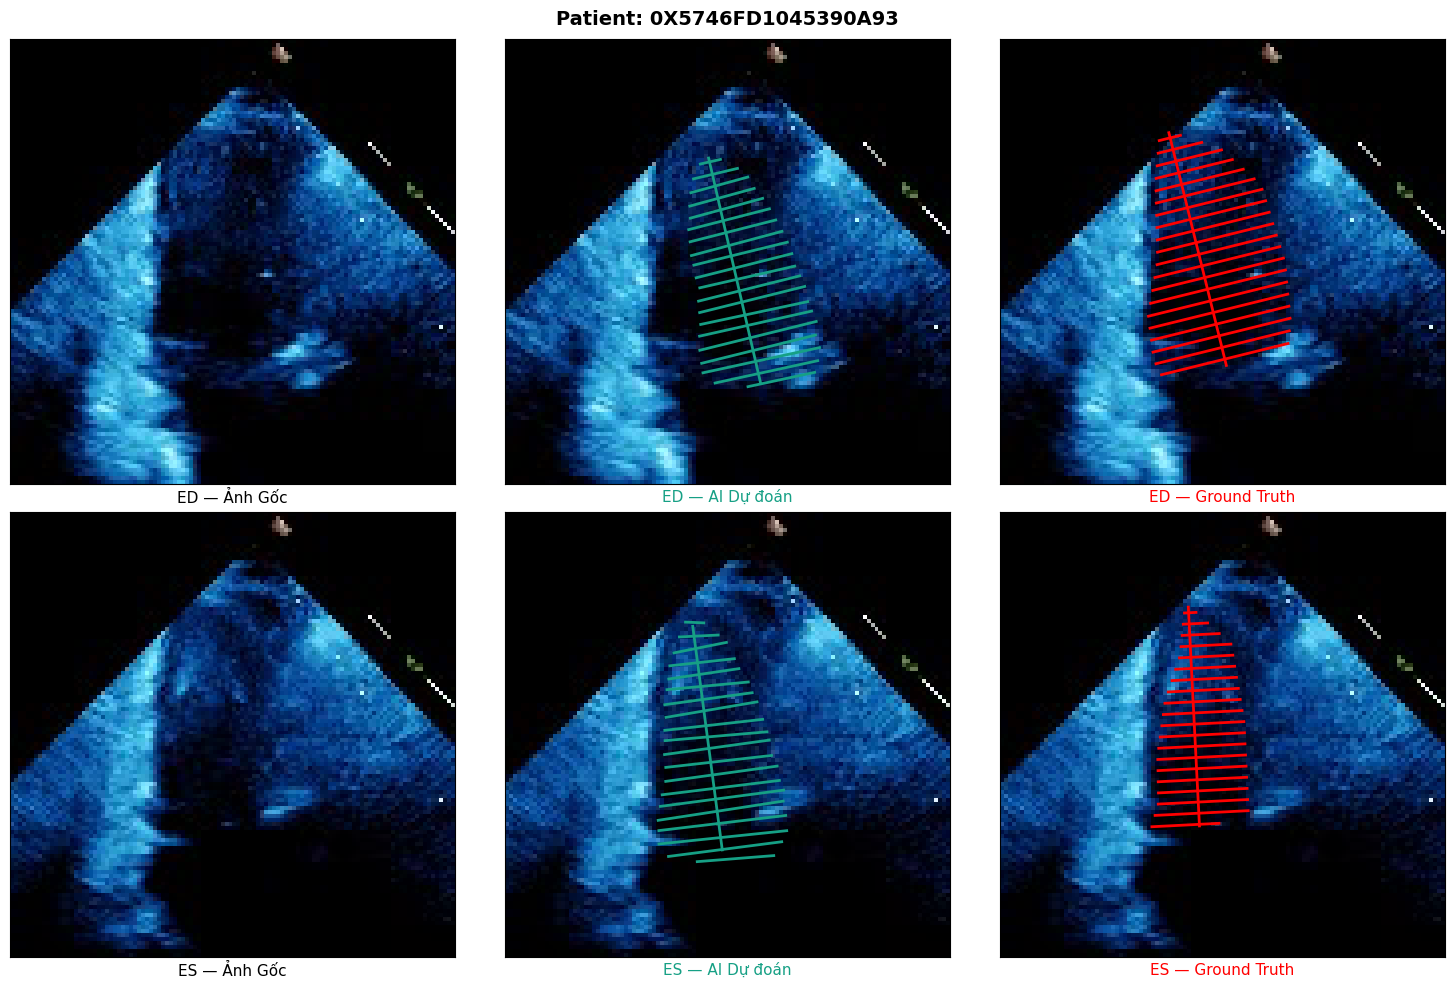


=> Bệnh nhân Test thứ 4: AI dự đoán EF = -18.97%
Data id 0XB9DA76703445AFD


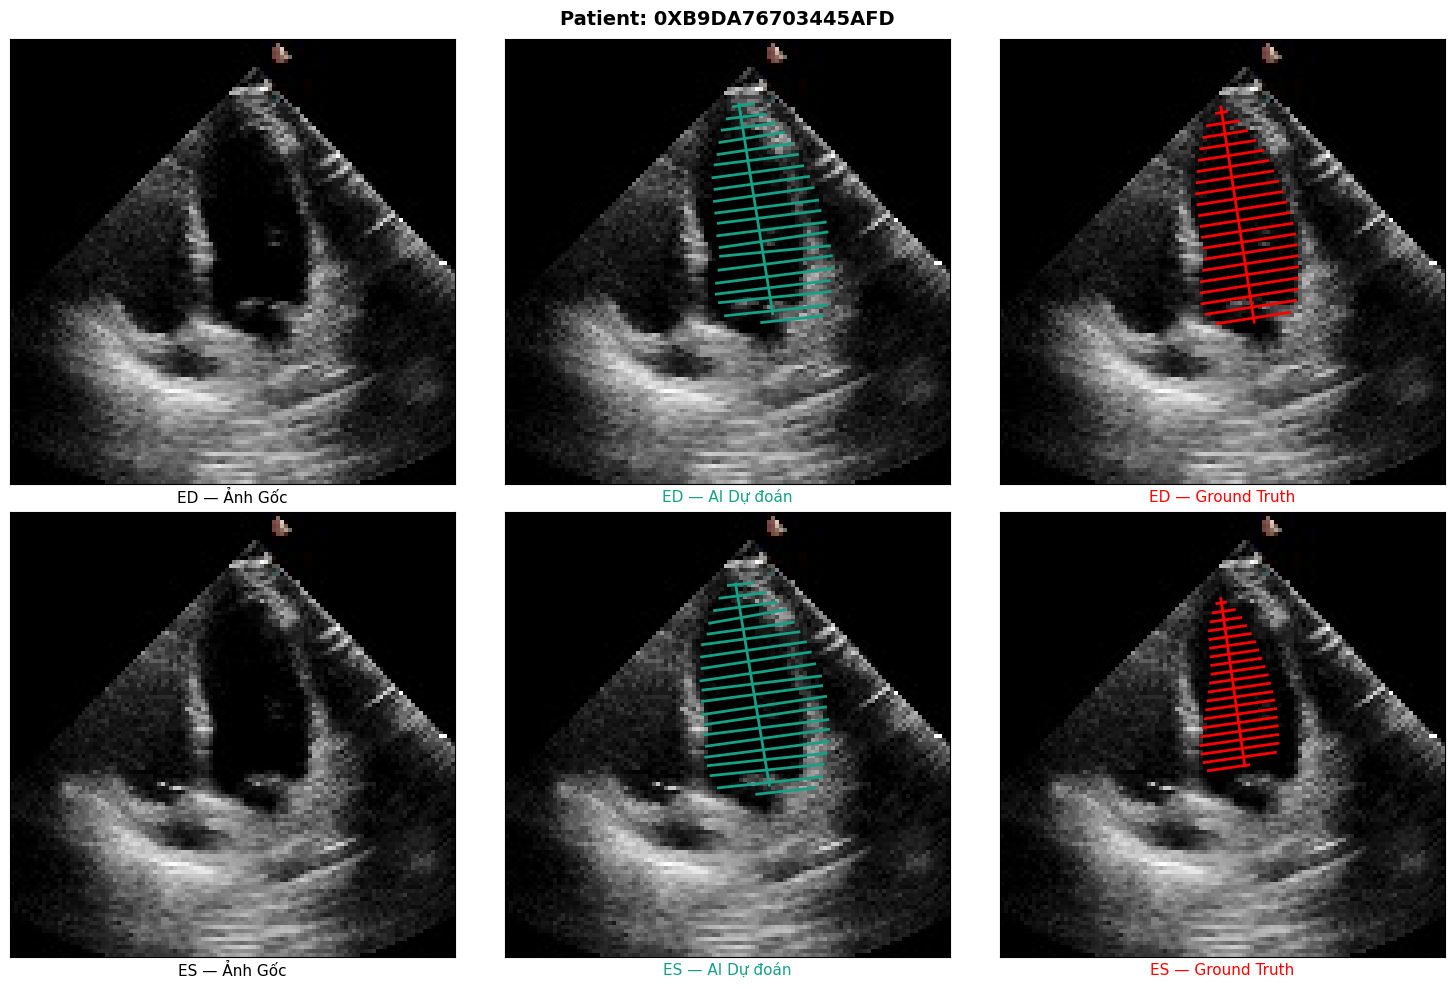


=> Bệnh nhân Test thứ 5: AI dự đoán EF = -2.51%
Data id 0X246B8C7FCA4D818D


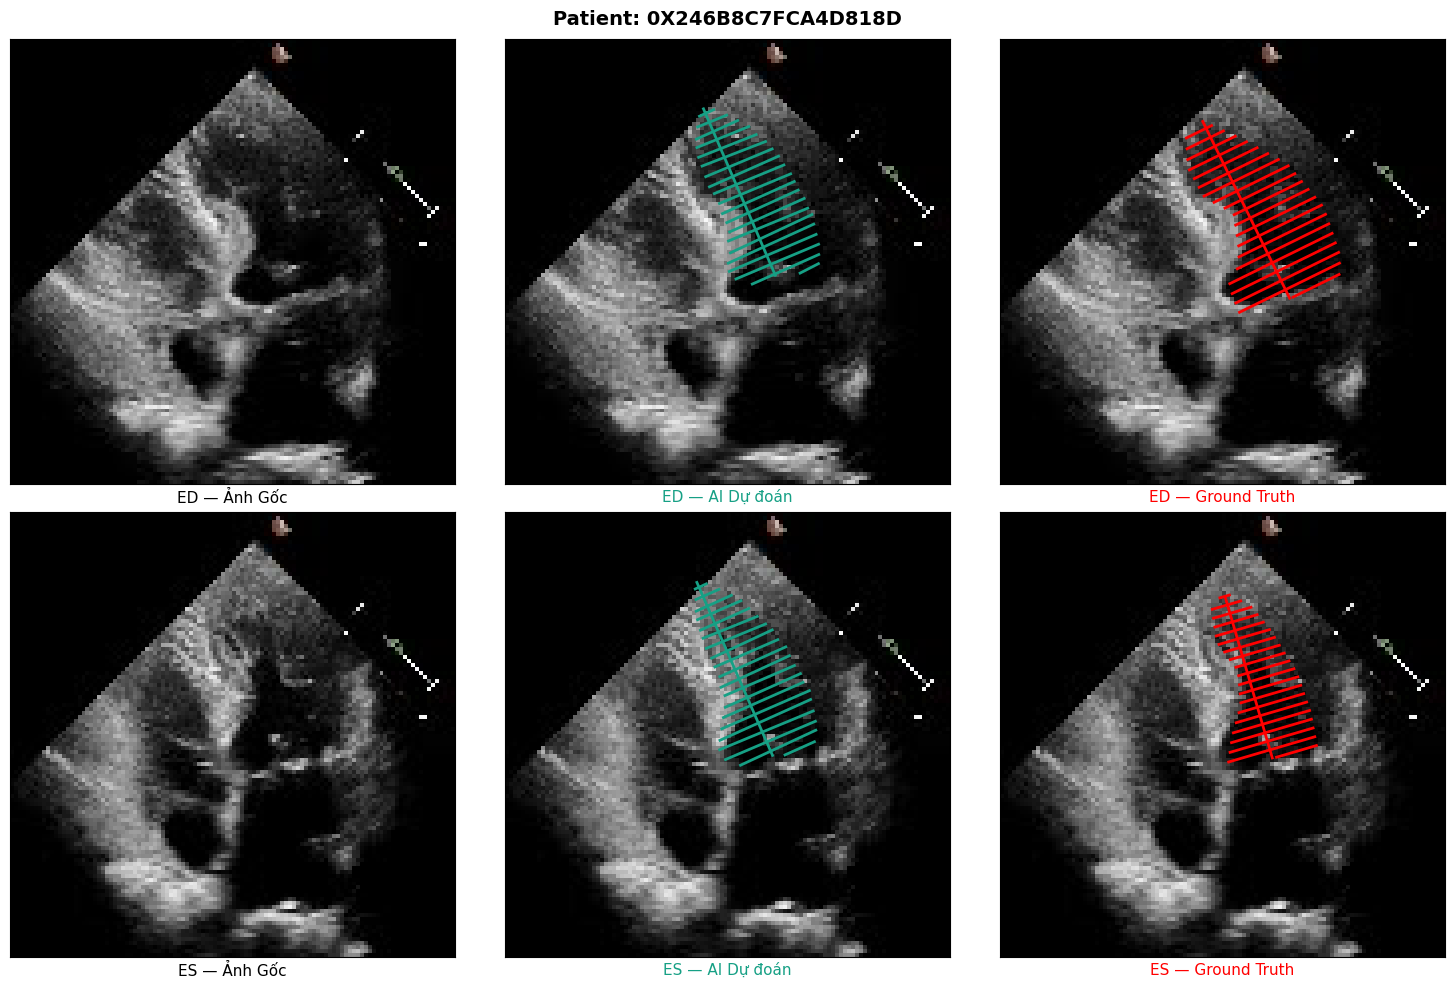

In [70]:
# Tìm lỗi của AI trên tập TEST
test_error_list = test_output_df.query('Pred_EF < 0').index.tolist()
print(f"Số lượng ca AI đoán âm (sai nặng) trên tập Test: {len(test_error_list)} ca")

print("Đang hiển thị các ca bệnh bị AI chẩn đoán lỗi trong tập Test...")
# Hiển thị tối đa 5 ca để phân tích
for i, err in enumerate(test_error_list):
    print(f"\n=> Bệnh nhân Test thứ {i+1}: AI dự đoán EF = {test_output_df.Pred_EF[err]:.2f}%")
    VisualizeSingleData(test_images, test_keypoints_conv, predicted_test_kps, test_ids, err)
    plt.show()
    
    if i == 4: # Dừng lại sau 5 ca
        break


# Phần 9: Phân tích lỗi 


**Mục tiêu:**
Mặc dù mô hình đạt được hiệu suất tổng thể khả quan, nhưng trong Y khoa, việc hiểu rõ "tại sao hệ thống đoán sai" có ý nghĩa quan trọng không kém việc đạt được độ chính xác cao. Trong phần này, chúng ta sẽ tiến hành **Phân tích lỗi (Error Analysis)** bằng cách mổ xẻ trực quan những ca mà hệ thống dự đoán lệch nhiều nhất so với thực tế (ví dụ: các trường hợp tính ra EF < 0, hoặc chênh lệch EF quá lớn).

**Các khía cạnh cần tập trung phân tích:**
1. **Lỗi do thuật toán (Algorithm/Math Error):** Hệ thống AI có nhận diện sai trục dọc (long axis) dẫn đến thuật toán tính toán lượng giá Simpson bị sai lệch hoàn toàn hay không?
2. **Lỗi do chất lượng dữ liệu (Data Quality):** Các ca dự đoán sai có phải là do hình ảnh siêu âm tim bị mờ, nhiễu, hoặc không lấy đúng góc cắt (View) hay không?
3. **Lỗi ở vùng biên mờ (Borderline Cases):** Tại sao mạng nơ-ron lại thường xuyên nhầm lẫn ở nhóm "Suy tim nhẹ" (Mild) so với các nhóm khác?




In [71]:
from sklearn.metrics import accuracy_score
def Accuracy_ConfusionMatrix(actual, predicted, categories):
    print(f"Accuracy of model: {accuracy_score(actual, predicted)}")
    confusion_matrix = pd.crosstab(actual, predicted, rownames=['Actual'], colnames=['Predicted'])
    print(confusion_matrix)
    print("Sensitivity of model for individual classes")
    class_sum = np.sum(confusion_matrix, axis=1)
    for c,i in enumerate(categories):
        print(f"Class {i} : {confusion_matrix.iloc[c,c]/class_sum.iloc[c]}")



### Hàm `Accuracy_ConfusionMatrix`

**Mục đích:** 
Hàm này dùng để đánh giá và tổng hợp hiệu suất phân loại mức độ suy tim của hệ thống. Thay vì chỉ xem sai số pixel hoặc tỷ lệ EF lệch bao nhiêu, hàm này đánh giá xem *kết luận y khoa cuối cùng* (nhóm bệnh lý) của hệ thống có khớp với bác sĩ hay không.

**Các tham số (Đầu vào):**
*   **`actual`**: Danh sách (hoặc Pandas Series) chứa nhãn phân loại suy tim *thực tế* của bệnh nhân (VD: Normal, Mild, Severe...).
*   **`predicted`**: Danh sách chứa nhãn phân loại suy tim *được dự đoán* từ chỉ số EF do mô hình AI tính ra.
*   **`categories`**: Danh sách tên các nhóm bệnh (các class) để phục vụ cho việc in kết quả rõ ràng.

**Đầu ra / Kết quả hiển thị:**
Hàm không trả về biến số nào (không dùng `return`) nhưng sẽ in (print) trực tiếp ra màn hình 3 báo cáo quan trọng:
1. Độ chính xác tổng thể (Overall Accuracy).
2. Bảng Ma trận nhầm lẫn (Confusion Matrix).
3. Độ nhạy (Sensitivity) của từng nhóm bệnh cụ thể.

In [72]:
print('Confusion Matrix for Training Data')
Accuracy_ConfusionMatrix(training_output_df.Actual_HFClass, 
                         training_output_df.Pred_HFClass,
                         training_output_df.Actual_HFClass.cat.categories)

Confusion Matrix for Training Data
Accuracy of model: 0.607492950181281
Predicted  Normal  Mild  Abnormal
Actual                           
Normal       3580  1015      1112
Mild          221   197       329
Abnormal       93   153       747
Sensitivity of model for individual classes
Class Normal : 0.6272998072542492
Class Mild : 0.2637215528781794
Class Abnormal : 0.7522658610271903


Confusion Matrix for Validation Data

In [73]:
print('Confusion Matrix for Validation Data')
Accuracy_ConfusionMatrix(val_output_df.Actual_HFClass, 
                         val_output_df.Pred_HFClass,
                         val_output_df.Actual_HFClass.cat.categories)

Confusion Matrix for Validation Data
Accuracy of model: 0.5434782608695652
Predicted  Normal  Mild  Abnormal
Actual                           
Normal        566   172       250
Mild           41    26        68
Abnormal       26    31       108
Sensitivity of model for individual classes
Class Normal : 0.5728744939271255
Class Mild : 0.1925925925925926
Class Abnormal : 0.6545454545454545


Confusion Matrix for Testing Data

In [74]:
print('Confusion Matrix for Testing Data')
Accuracy_ConfusionMatrix(test_output_df.Actual_HFClass, 
                         test_output_df.Pred_HFClass,
                         test_output_df.Actual_HFClass.cat.categories)

Confusion Matrix for Testing Data
Accuracy of model: 0.5650470219435737
Predicted  Normal  Mild  Abnormal
Actual                           
Normal        570   156       254
Mild           43    31        52
Abnormal       25    25       120
Sensitivity of model for individual classes
Class Normal : 0.5816326530612245
Class Mild : 0.24603174603174602
Class Abnormal : 0.7058823529411765


In [75]:


def ExportErrorCasesToFolder(data_images, data_keypoints, pred_keypoints,
                              data_ids, error_indices, folder_name):
    os.makedirs(folder_name, exist_ok=True)
    print(f"Thư mục: '{folder_name}' | Số ca lỗi: {len(error_indices)}")

    for i, idx in enumerate(error_indices):
        patient_id   = data_ids[2 * idx]
        actual_class = test_output_df['Actual_HFClass'].iloc[idx]
        pred_class   = test_output_df['Pred_HFClass'].iloc[idx]

        VisualizeSingleData(data_images, data_keypoints, pred_keypoints, data_ids, idx)

        filename  = f"error_{i+1:03d}_{patient_id}_ACTUAL-{actual_class}_PRED-{pred_class}.png"
        save_path = os.path.join(folder_name, filename)
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.close()
        print(f"  [{i+1}/{len(error_indices)}] {actual_class} → {pred_class}")

    print(f"Hoàn tất! Ảnh nằm trong thư mục '{folder_name}' trên Kaggle.")


# --- THỰC THI ---
misclassified = test_output_df[
    test_output_df['Actual_HFClass'] != test_output_df['Pred_HFClass']
].index.tolist()

print(f"Tổng ca chuẩn đoán sai: {len(misclassified)}")

ExportErrorCasesToFolder(
    data_images    = test_images,
    data_keypoints = test_keypoints_conv,
    pred_keypoints = predicted_test_kps,
    data_ids       = test_ids,
    error_indices  = misclassified,
    folder_name    = "error_analysis"
)


Tổng ca chuẩn đoán sai: 555
Thư mục: 'error_analysis' | Số ca lỗi: 555
Data id 0X3503A92D7637451
  [1/555] Abnormal → Mild
Data id 0X76236768A07DC4A0
  [2/555] Normal → Abnormal
Data id 0X4FACABF5BA7D337
  [3/555] Normal → Abnormal
Data id 0X88E54370A17E06F
  [4/555] Mild → Abnormal
Data id 0X4E0BC2C036E928B1
  [5/555] Normal → Mild
Data id 0X4E9F08061D109568
  [6/555] Mild → Abnormal
Data id 0X41705247E0540BD7
  [7/555] Normal → Mild
Data id 0X241E08BD87DD9251
  [8/555] Normal → Abnormal
Data id 0X4F6EAF6EA9D0D4AA
  [9/555] Normal → Mild
Data id 0X617DAA674148287E
  [10/555] Normal → Abnormal
Data id 0X1FA393110F28F205
  [11/555] Normal → Abnormal
Data id 0X5CEFEEEA65D39669
  [12/555] Normal → Abnormal
Data id 0X704845139A356532
  [13/555] Normal → Mild
Data id 0X42D952F5218473D0
  [14/555] Normal → Mild
Data id 0X3F24B7E7AE2C282B
  [15/555] Mild → Abnormal
Data id 0X386924A6B430342A
  [16/555] Mild → Abnormal
Data id 0X79DFCFF4867CB797
  [17/555] Mild → Abnormal
Data id 0X36DFB3273B2

From the above values, it looks like the model performs worse on the mild class - ie EFs that are between 40 and 50.

Data id 0X17865EC85AD080B0


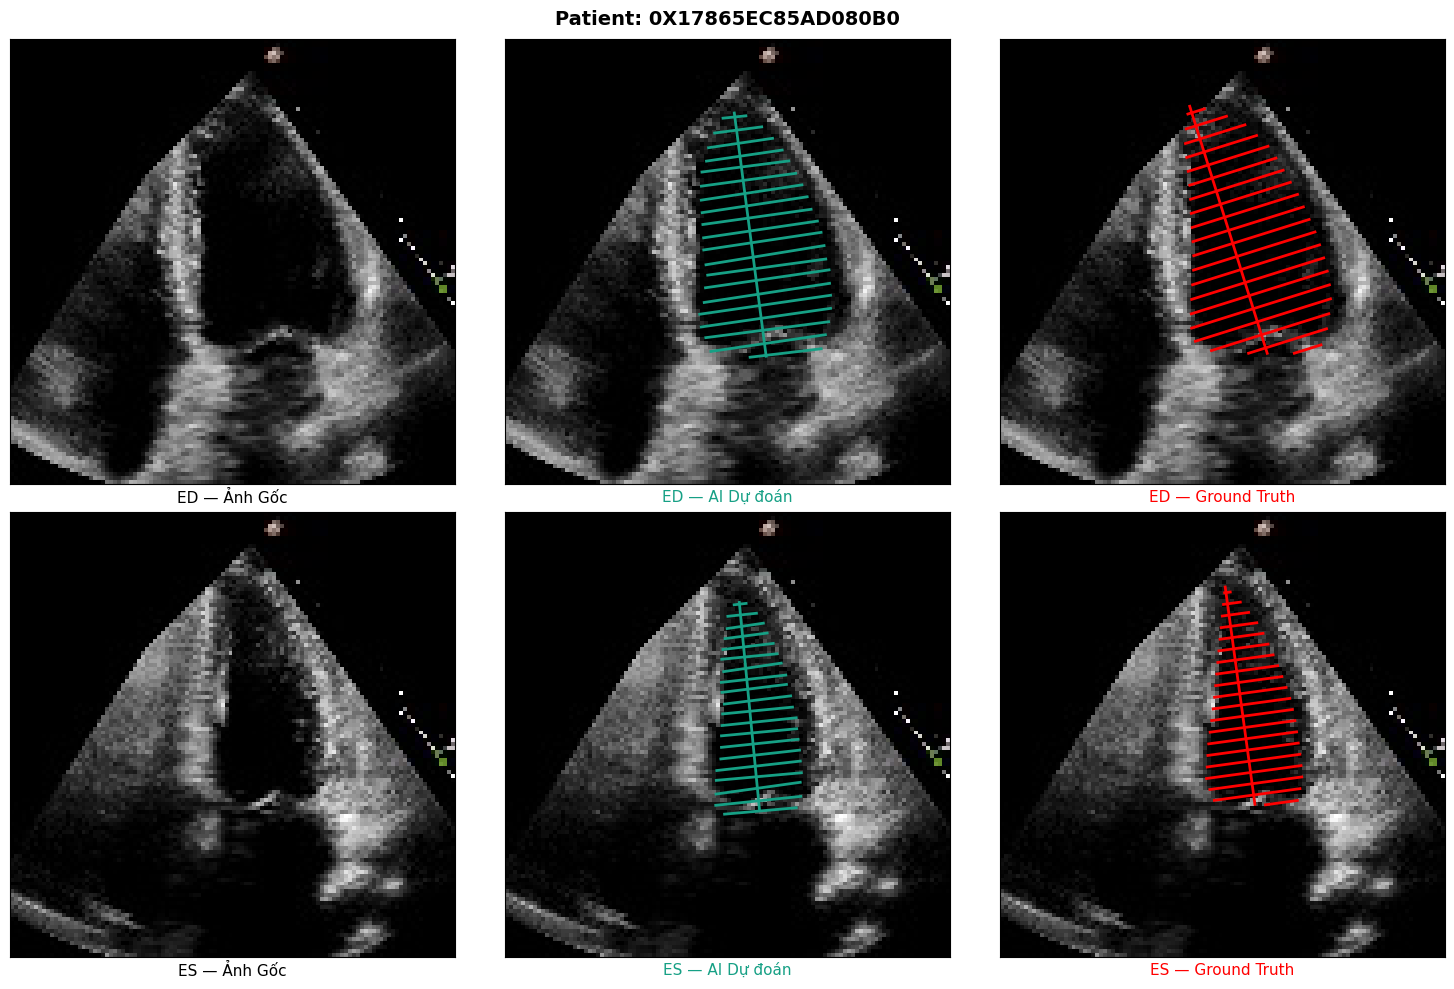

In [76]:
VisualizeSingleData(train_images, train_keypoints_conv, predicted_train_kps, train_ids, 531)

In [77]:
training_output_df.query('Diff_EFs > 100')

,Actual_EF,Pred_EF,Actual_HFClass,Pred_HFClass,Diff_EFs
603,58.377182,-136.965958,Normal,Abnormal,195.343140
1791,60.394241,-263.554016,Normal,Abnormal,323.948242
2239,49.637596,-58.114487,Mild,Abnormal,107.752083
2373,44.219864,-62.313049,Mild,Abnormal,106.532913
2412,55.770397,-46.511753,Normal,Abnormal,102.282150
2713,32.003567,-73.533646,Abnormal,Abnormal,105.537216
2857,59.261345,-54.931980,Normal,Abnormal,114.193329
3092,31.544355,-85.759773,Abnormal,Abnormal,117.304131
3151,63.237709,-439.747284,Normal,Abnormal,502.984985
3326,46.129547,-268.909241,Mild,Abnormal,315.038788


<Axes: title={'center': 'Diff_EFs'}, xlabel='Actual_HFClass'>

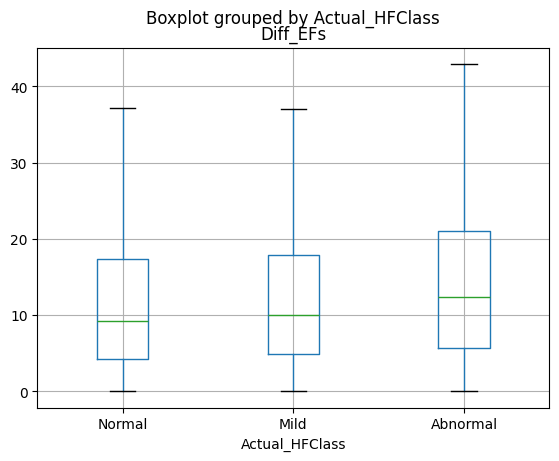

In [78]:
training_output_df.boxplot(column='Diff_EFs', by='Actual_HFClass', showfliers=False)

# Phần 10: Xử lý ảnh dự đoán sai 


### Bước 1 — Đo 3 chỉ số chất lượng ảnh



### Nhóm 1 — Phân loại theo Chất lượng Tín hiệu Cục bộ
Đây là nhóm các lỗi liên quan đến nhiễu và độ sắc nét quang học tại một khu vực cụ thể trên ảnh, ảnh hưởng trực tiếp đến khả năng định vị điểm của mô hình.

| ID | Kịch bản Lỗi | Biểu hiện trên ảnh | Hậu quả với Mô hình AI |
|:---:|:---|:---|:---|
| **A** | **Speckle Noise** (Nhiễu lốm đốm) | Xuất hiện các hạt nhiễu trắng/đen xen kẽ đặc trưng của sóng siêu âm. | Mô hình bị nhiễu, dự đoán ranh giới (keypoint) lẹm vào phía trong buồng tim thay vì đúng trên thành cơ tim. |
| **B** | **Low Contrast** (Độ tương phản thấp) | Vùng đáy tim (đặc biệt quanh van hai lá) bị tối, nhờ nhờ, thiếu dải xám rành mạch. | Trục dọc (Long axis) bị dự đoán ngắn lại, điểm gốc van tim bị sai lệch dẫn đến sai số thể tích. |
| **C** | **Motion Blur** (Mất nét do chuyển động) | Biên LV bị nhòe mờ do bệnh nhân thở, tim đập nhanh, hoặc tốc độ quét frame thấp. | Keypoint mất "điểm neo" vật lý sắc nét, mô hình phải suy đoán hình học thay vì bám viền. |
| **D** | **Acoustic Shadow** (Bóng cản âm) | Xuất hiện vùng tối hoàn toàn do xương sườn hoặc vật liệu cứng che khuất sóng siêu âm. | Mất hẳn thông tin điểm ảnh, mô hình sinh ra dự đoán ngẫu nhiên tại khu vực bị che khuất. |

### Nhóm 2 — Phân loại theo Độ sáng Tổng thể (Gain)
Đây là lỗi do thao tác điều chỉnh máy siêu âm của kỹ thuật viên (xoay núm Gain), làm thay đổi toàn cục phân bố cường độ sáng của ảnh.

| ID | Kịch bản Lỗi | Biểu hiện trên ảnh | Hậu quả với Mô hình AI |
|:---:|:---|:---|:---|
| **E** | **Over-gain** (Phơi sáng quá mức) | Toàn bộ bức ảnh trắng xóa, các cấu trúc mô mềm bị lấn át bởi màu trắng. | Buồng máu không còn màu đen, ranh giới giữa khoang chứa máu và cơ tim biến mất hoàn toàn. |
| **F** | **Under-gain** (Thiếu sáng) | Toàn bộ bức ảnh tối om, đen sì. | Mô hình bị mù, không nhận diện được bất kỳ cấu trúc giải phẫu nào. |

### Nhóm 3 — Phân loại theo Artifact Đặc trưng Siêu âm
Các hiện tượng quang học/vật lý sinh ra tín hiệu ảo (không có thực trong cơ thể) gây nhiễu loạn thị giác máy tính.

| ID | Kịch bản Lỗi | Biểu hiện trên ảnh | Hậu quả với Mô hình AI |
|:---:|:---|:---|:---|
| **G** | **Reverberation** (Dội âm) | Các dải sáng nằm ngang song song, sinh ra do sóng âm phản xạ nhiều lần giữa 2 bề mặt cứng. | Mô hình nhận diện nhầm dải sáng ảo này là một phần của thành cơ tim, tạo keypoint rác. |
| **H** | **Near-field Clutter** (Nhiễu vùng gần) | Vùng chói sáng mạnh sát bề mặt đầu dò (phần trên cùng của ảnh). | Gây ảo giác về đỉnh tim (Apex), làm mô hình dự đoán trục dọc bị lệch hướng xuống dưới. |

### Nhóm 4 — Phân loại theo Vấn đề Hình học (Geometry)
Nhóm lỗi do sai lệch về mặt không gian vật lý, không liên quan đến chất lượng quang học.

| ID | Kịch bản Lỗi | Biểu hiện trên ảnh | Hậu quả với Mô hình AI |
|:---:|:---|:---|:---|
| **I** | **LV Tilt / Rotation** (Lệch trục không gian) | Kỹ thuật viên đặt đầu dò sai góc, buồng thất trái (LV) nằm chéo hoặc xoay ngang. | Mô hình được huấn luyện trên ảnh chuẩn (tim thẳng đứng) sẽ dự đoán sai hệ thống (Systematic error). |
| **J** | **Out of Frame** (Nằm ngoài khung hình) | Một phần của buồng tim (thường là đỉnh tim hoặc van tim) lọt ra khỏi giới hạn của bức ảnh. | Thông tin giải phẫu bị mất vĩnh viễn, không thể nội suy hay khắc phục bằng DIP. |


In [79]:
def measure_image_quality(img_gray):
    sharpness       = cv2.Laplacian(img_gray, cv2.CV_64F).var()
    contrast        = float(img_gray.std())
    mean_brightness = float(img_gray.mean())
    return {
        'sharpness':        sharpness,
        'contrast':         contrast,
        'mean_brightness':  mean_brightness
    }


### Thu thập và đánh giá các ngưỡng

Số ca đúng — Train: 4524 | Val: 700 | Test: 721
Tổng số ảnh đo được: 11890

NGƯỠNG PHÂN LOẠI KỊCH BẢN

SHARPNESS:
  Mean: 3779.28 | Std: 837.46
  Ngưỡng LOW  (5th  pct): 2366.35
  Ngưỡng HIGH (95th pct): 5121.31

CONTRAST:
  Mean: 48.89 | Std: 8.01
  Ngưỡng LOW  (5th  pct): 35.70
  Ngưỡng HIGH (95th pct): 62.09

MEAN_BRIGHTNESS:
  Mean: 32.86 | Std: 8.09
  Ngưỡng LOW  (5th  pct): 20.58
  Ngưỡng HIGH (95th pct): 47.13


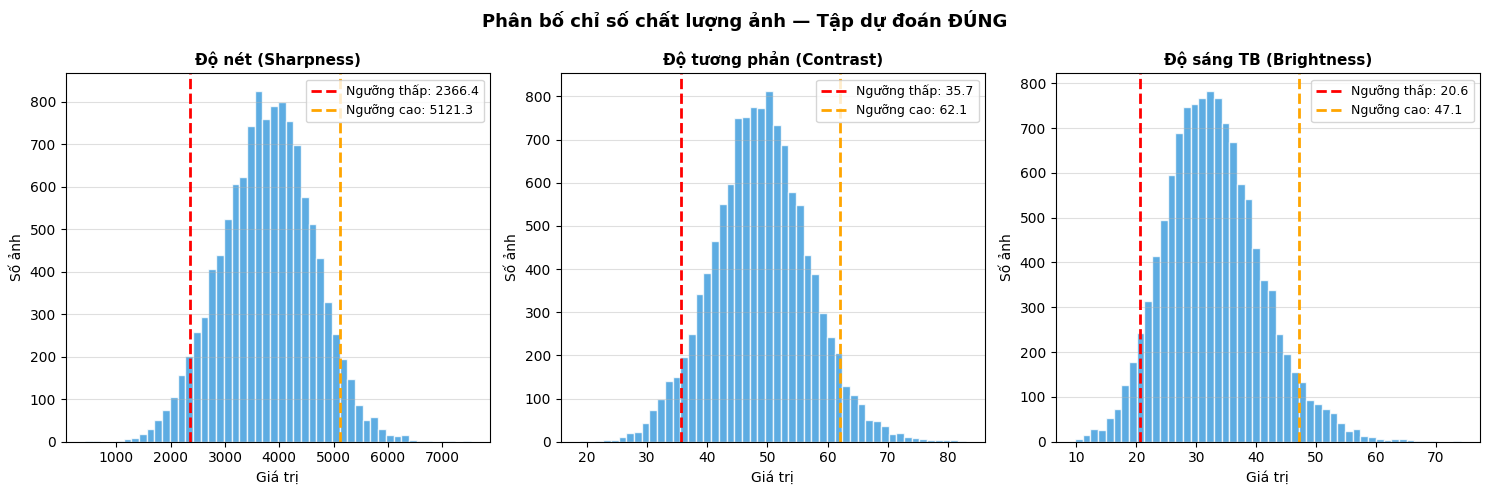


Đã lưu: thresholds_distribution.png


In [80]:
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

# ---- HÀM PHỤ TRỢ ----
def rgb_to_gray(img_rgb):
    return cv2.cvtColor(img_rgb.astype(np.uint8), cv2.COLOR_RGB2GRAY)

def measure_image_quality(img_gray):
    return {
        'sharpness':       cv2.Laplacian(img_gray, cv2.CV_64F).var(),
        'contrast':        float(img_gray.std()),
        'mean_brightness': float(img_gray.mean())
    }

# ---- BƯỚC 1: GOM ẢNH ĐÚNG TỪ 3 TẬP ----
correct_train = training_output_df[training_output_df['Actual_HFClass'] == training_output_df['Pred_HFClass']].index.tolist()
correct_val   = val_output_df[val_output_df['Actual_HFClass']           == val_output_df['Pred_HFClass']].index.tolist()
correct_test  = test_output_df[test_output_df['Actual_HFClass']         == test_output_df['Pred_HFClass']].index.tolist()
print(f"Số ca đúng — Train: {len(correct_train)} | Val: {len(correct_val)} | Test: {len(correct_test)}")

# ---- BƯỚC 2: ĐO 3 CHỈ SỐ ----
all_metrics = []
datasets = [
    (train_images, correct_train, 'train'),
    (val_images,   correct_val,   'val'),
    (test_images,  correct_test,  'test'),
]
for images, indices, split_name in datasets:
    for idx in indices:
        for frame_offset in [0, 1]:
            img_gray = rgb_to_gray(images[2 * idx + frame_offset])
            m = measure_image_quality(img_gray)
            m['split'] = split_name
            all_metrics.append(m)

df_metrics = pd.DataFrame(all_metrics)
print(f"Tổng số ảnh đo được: {len(df_metrics)}")

# ---- BƯỚC 3: TÍNH NGƯỠNG ----
thresholds = {}
for col in ['sharpness', 'contrast', 'mean_brightness']:
    thresholds[col] = {
        'low':  float(np.percentile(df_metrics[col], 5)),
        'high': float(np.percentile(df_metrics[col], 95)),
        'mean': float(df_metrics[col].mean()),
        'std':  float(df_metrics[col].std()),
    }

print("\n" + "="*55)
print("NGƯỠNG PHÂN LOẠI KỊCH BẢN")
print("="*55)
for metric, vals in thresholds.items():
    print(f"\n{metric.upper()}:")
    print(f"  Mean: {vals['mean']:.2f} | Std: {vals['std']:.2f}")
    print(f"  Ngưỡng LOW  (5th  pct): {vals['low']:.2f}")
    print(f"  Ngưỡng HIGH (95th pct): {vals['high']:.2f}")

# ---- BƯỚC 4: VẼ HISTOGRAM ----
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Phân bố chỉ số chất lượng ảnh — Tập dự đoán ĐÚNG",
             fontsize=13, fontweight='bold')

labels = {
    'sharpness':       'Độ nét (Sharpness)',
    'contrast':        'Độ tương phản (Contrast)',
    'mean_brightness': 'Độ sáng TB (Brightness)'
}

for ax, col in zip(axes, ['sharpness', 'contrast', 'mean_brightness']):
    ax.hist(df_metrics[col], bins=50, color='#3498db', edgecolor='white', alpha=0.8)
    ax.axvline(thresholds[col]['low'],  color='red',    linestyle='--', linewidth=2,
               label=f"Ngưỡng thấp: {thresholds[col]['low']:.1f}")
    ax.axvline(thresholds[col]['high'], color='orange', linestyle='--', linewidth=2,
               label=f"Ngưỡng cao: {thresholds[col]['high']:.1f}")
    ax.set_title(labels[col], fontsize=11, fontweight='bold')
    ax.set_xlabel("Giá trị")
    ax.set_ylabel("Số ảnh")
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig("thresholds_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nĐã lưu: thresholds_distribution.png")


### Bước 2 — Phân loại kịch bản tự động


In [81]:
def rgb_to_gray(img_rgb):
    """Chuyển ảnh 112x112x3 sang grayscale 112x112."""
    return cv2.cvtColor(img_rgb.astype(np.uint8), cv2.COLOR_RGB2GRAY)
def gray_to_rgb(img_gray):
    """Chuyển ảnh grayscale về 112x112x3 để feed vào model."""
    return cv2.cvtColor(img_gray, cv2.COLOR_GRAY2RGB)


In [82]:
def classify_scenario(metrics, thresholds):
    scenarios = []
    if metrics['mean_brightness'] > thresholds['mean_brightness']['high']:
        scenarios.append('E')
    if metrics['mean_brightness'] < thresholds['mean_brightness']['low']:
        scenarios.append('F')
    if metrics['contrast'] < thresholds['contrast']['low']:
        scenarios.append('B')
    if metrics['sharpness'] < thresholds['sharpness']['low']:
        scenarios.append('C')
    if not scenarios:
        scenarios.append('A')
    return scenarios

In [83]:
def pipeline_ABC(img_gray):
    """Kịch bản A+B+C: Median → Bilateral → CLAHE → Unsharp."""
    img = cv2.medianBlur(img_gray, 3)
    img = cv2.bilateralFilter(img, d=9, sigmaColor=75, sigmaSpace=75)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(img)
    blur = cv2.GaussianBlur(img, (5, 5), 1.0)
    img  = cv2.addWeighted(img, 1.5, blur, -0.5, 0)
    return img
def pipeline_EF(img_gray, mean_brightness, thresholds):
    """Kịch bản E/F: Gamma Correction → pipeline_ABC."""
    if mean_brightness > thresholds['mean_brightness']['high']:
        gamma = 1.5
    elif mean_brightness < thresholds['mean_brightness']['low']:
        gamma = 0.5
    else:
        return pipeline_ABC(img_gray)
    inv_gamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** inv_gamma) * 255
                      for i in np.arange(256)]).astype("uint8")
    return pipeline_ABC(cv2.LUT(img_gray, table))
def pipeline_DGH(img_gray):
    """Kịch bản D/G/H: Inpainting artifact nhỏ < 10% ảnh."""
    _, mask = cv2.threshold(img_gray, 20, 255, cv2.THRESH_BINARY_INV)
    kernel  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask    = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    ratio   = mask.sum() / (255.0 * mask.size)
    if ratio < 0.10:
        return cv2.inpaint(img_gray, mask, inpaintRadius=5, flags=cv2.INPAINT_TELEA)
    return img_gray
def apply_pipeline(img_gray, scenarios, metrics, thresholds):
    """Tự động chọn pipeline phù hợp."""
    if 'E' in scenarios or 'F' in scenarios:
        return pipeline_EF(img_gray, metrics['mean_brightness'], thresholds)
    return pipeline_ABC(img_gray)
print("Đã định nghĩa xong tất cả các hàm!")

Đã định nghĩa xong tất cả các hàm!


### 10.3 — Bổ sung Kỹ thuật DIP Nâng cao

Dựa trên tài liệu lý thuyết xử lý ảnh số, các kỹ thuật sau chưa được áp dụng:
- **Alpha-trimmed Mean Filter**: Kết hợp ưu điểm của Median và Mean filter, loại bỏ outlier trước khi lấy trung bình
- **Histogram Stretching**: Kéo giãn tuyến tính histogram về đúng khoảng [0,255] — khôi phục ảnh thiếu contrast
- **Morphological Operations**: Opening (loại speckle nhỏ), Closing (lấp lỗ hổng biên tim), Gradient (làm nổi biên)
- **Butterworth Low-pass Filter (Miền Tần số)**: Lọc nhiễu cao tần mà không tạo hiệu ứng ringing như lọc lý tưởng

In [84]:
import numpy as np
import cv2
from scipy.ndimage import generic_filter

# ─── 1. Alpha-Trimmed Mean Filter ─────────────────────────────────────────────
def alpha_trimmed_filter(img_gray, size=3, d=2):
    """
    d: số phần tử bị cắt ở 2 đầu trong mỗi cửa sổ size×size.
    d=2 → cắt 2 giá trị nhỏ nhất và 2 lớn nhất → trung bình phần còn lại.
    Hiệu quả hơn Median khi nhiễu không đối xứng.
    """
    def trimmed_mean(values):
        v = np.sort(values)
        n = len(v)
        trimmed = v[d:n-d]
        return trimmed.mean() if len(trimmed) > 0 else v.mean()
    return generic_filter(img_gray.astype(np.float32), trimmed_mean,
                          size=size).astype(np.uint8)

# ─── 2. Histogram Stretching (Linear Contrast Stretching) ─────────────────────
def histogram_stretching(img_gray, p_low=2, p_high=98):
    """
    Kéo giãn tuyến tính histogram:
      - Cắt p_low% pixel tối nhất và p_high% pixel sáng nhất (loại outlier)
      - Scale phần còn lại về [0, 255]
    Khôi phục contrast bị mất do gain máy siêu âm không đồng đều.
    """
    lo = np.percentile(img_gray, p_low)
    hi = np.percentile(img_gray, p_high)
    if hi == lo:
        return img_gray.copy()
    stretched = np.clip((img_gray.astype(np.float32) - lo) / (hi - lo) * 255, 0, 255)
    return stretched.astype(np.uint8)

# ─── 3. Morphological Enhancement ─────────────────────────────────────────────
def morphological_enhancement(img_gray):
    """
    Kết hợp 3 phép biến đổi hình thái học:
      - Opening  (Erosion→Dilation): Loại bỏ các điểm nhiễu nhỏ (speckle)
      - Closing  (Dilation→Erosion): Lấp các lỗ hổng nhỏ trên biên nội mạc
      - Gradient (Dilation - Erosion): Làm nổi bật đường biên cơ tim
    Kết hợp: ảnh sau Opening+Closing được tăng cường bằng Gradient.
    """
    kernel_small  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    kernel_medium = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    # Opening: loại speckle nhỏ
    opened = cv2.morphologyEx(img_gray, cv2.MORPH_OPEN, kernel_small)
    # Closing: lấp lỗ hổng trên biên
    closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel_small)
    # Gradient: trích xuất thông tin biên
    gradient = cv2.morphologyEx(closed, cv2.MORPH_GRADIENT, kernel_medium)
    # Overlay nhẹ gradient lên ảnh đã làm sạch (alpha blend)
    result = cv2.addWeighted(closed, 0.85, gradient, 0.15, 0)
    return result

# ─── 4. Butterworth Low-pass Filter (Miền Tần số) ────────────────────────────
def butterworth_lowpass(img_gray, cutoff=0.25, order=2):
    """
    Lọc low-pass Butterworth trong miền tần số (FFT):
      - cutoff: tỷ lệ tần số cắt (0–1), 0.25 → giữ 25% tần số thấp nhất
      - order  : bậc của filter, bậc cao → cắt sắc hơn nhưng ít ringing hơn ideal
    Loại bỏ nhiễu cao tần (speckle) mà không gây hiện tượng Gibbs như ideal filter.
    """
    rows, cols = img_gray.shape
    crow, ccol = rows // 2, cols // 2
    # Ma trận tần số
    u = np.arange(rows) - crow
    v = np.arange(cols) - ccol
    V, U = np.meshgrid(v, u)
    D = np.sqrt(U**2 + V**2)
    D0 = cutoff * min(crow, ccol)
    # Butterworth mask
    H = 1.0 / (1.0 + (D / (D0 + 1e-8)) ** (2 * order))
    # Áp dụng FFT
    f_shift = np.fft.fftshift(np.fft.fft2(img_gray.astype(np.float32)))
    filtered = np.fft.ifft2(np.fft.ifftshift(f_shift * H))
    result = np.clip(np.abs(filtered), 0, 255).astype(np.uint8)
    return result

print("Da dinh nghia: alpha_trimmed_filter, histogram_stretching, morphological_enhancement, butterworth_lowpass")


Da dinh nghia: alpha_trimmed_filter, histogram_stretching, morphological_enhancement, butterworth_lowpass


### Minh họa các kỹ thuật mới trên 1 ảnh mẫu

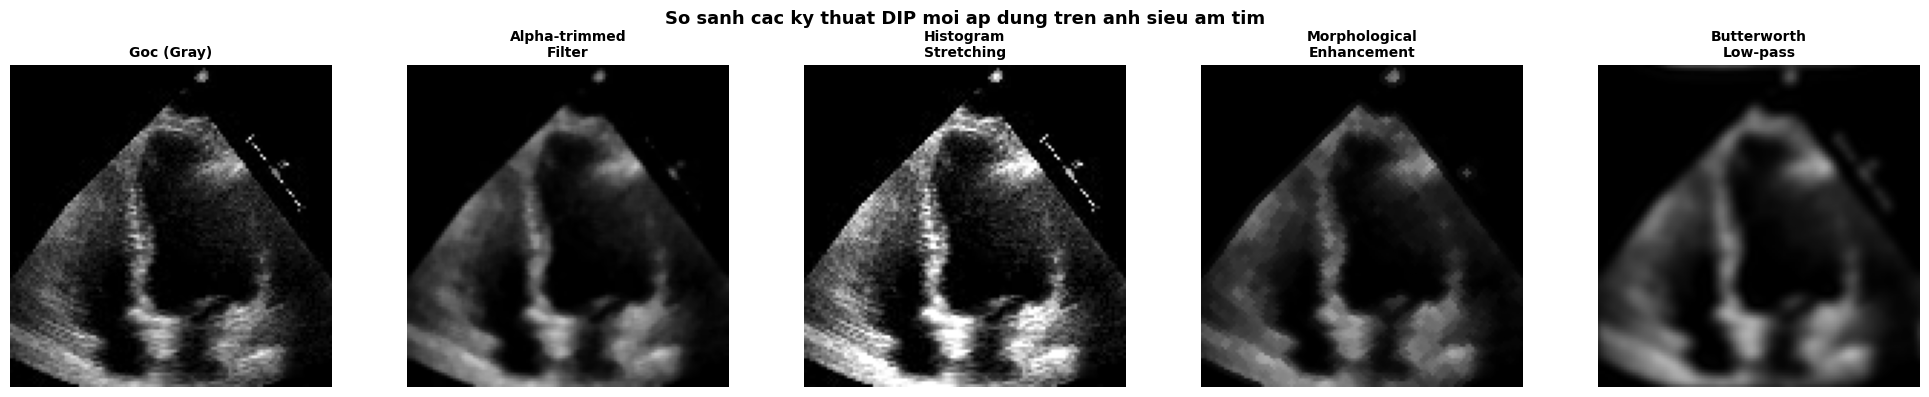

Hoan tat minh hoa 4 ky thuat moi.


In [85]:
import matplotlib.pyplot as plt

# Lấy 1 ảnh test ngẫu nhiên để minh họa
sample_img_rgb  = test_images[0].astype(np.uint8)
sample_img_gray = rgb_to_gray(sample_img_rgb)

# Áp dụng từng kỹ thuật
img_alpha   = alpha_trimmed_filter(sample_img_gray, size=3, d=2)
img_stretch = histogram_stretching(sample_img_gray, p_low=2, p_high=98)
img_morph   = morphological_enhancement(sample_img_gray)
img_butter  = butterworth_lowpass(sample_img_gray, cutoff=0.25, order=2)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
titles = ['Goc (Gray)', 'Alpha-trimmed\nFilter', 'Histogram\nStretching',
          'Morphological\nEnhancement', 'Butterworth\nLow-pass']
imgs   = [sample_img_gray, img_alpha, img_stretch, img_morph, img_butter]

for ax, img, title in zip(axes, imgs, titles):
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.axis('off')

plt.suptitle('So sanh cac ky thuat DIP moi ap dung tren anh sieu am tim', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("Hoan tat minh hoa 4 ky thuat moi.")


### 10.4 — Pipeline Nâng cao Kết hợp Tất cả Kỹ thuật

Pipeline mới áp dụng **theo thứ tự tối ưu**:
1. **Alpha-trimmed Filter** — Khử nhiễu hạt trước tiên (ít làm mờ biên hơn Median)
2. **Butterworth Low-pass** — Loại nhiễu cao tần miền tần số
3. **Histogram Stretching** — Khôi phục contrast toàn cục
4. **CLAHE** — Tăng cường contrast cục bộ (van tim, đáy tim)
5. **Morphological Enhancement** — Làm sạch và làm nổi biên nội mạc
6. **Unsharp Masking** — Mài sắc biên cuối cùng
7. **Gamma Correction** (nếu ảnh quá sáng/tối)

In [86]:
def apply_full_pipeline(img_gray, metrics, thresholds):
    """
    Pipeline nâng cao ket hop TAT CA ky thuat DIP.
    Thu tu: Alpha-trimmed → Butterworth → Histogram Stretch
            → CLAHE → Morphological → Unsharp → (Gamma neu can)
    """
    img = img_gray.copy()

    # 1. Alpha-trimmed Mean Filter (khử nhiễu hạt tốt hơn Median đơn thuần)
    img = alpha_trimmed_filter(img, size=3, d=2)

    # 2. Butterworth Low-pass (loại cao tần, tránh ringing)
    img = butterworth_lowpass(img, cutoff=0.30, order=2)

    # 3. Histogram Stretching (khôi phục dải động đầy đủ)
    img = histogram_stretching(img, p_low=2, p_high=98)

    # 4. CLAHE (tăng cường contrast cục bộ)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(img)

    # 5. Morphological Enhancement (làm sạch + nổi biên)
    img = morphological_enhancement(img)

    # 6. Unsharp Masking (mài sắc biên cuối)
    blur = cv2.GaussianBlur(img, (5, 5), 1.0)
    img  = cv2.addWeighted(img, 1.5, blur, -0.5, 0)

    # 7. Gamma Correction (chỉ khi ảnh quá sáng hoặc quá tối)
    mb = float(img.mean())
    if mb > thresholds['mean_brightness']['high']:
        gamma = 1.5
        table = np.array([((i/255.0)**(1.0/gamma))*255 for i in range(256)]).astype('uint8')
        img = cv2.LUT(img, table)
    elif mb < thresholds['mean_brightness']['low']:
        gamma = 0.5
        table = np.array([((i/255.0)**(1.0/gamma))*255 for i in range(256)]).astype('uint8')
        img = cv2.LUT(img, table)

    return img

print("Da dinh nghia apply_full_pipeline() ket hop tat ca ky thuat DIP.")


Da dinh nghia apply_full_pipeline() ket hop tat ca ky thuat DIP.


### 10.5 — Chạy lại Baseline với Enhanced Pipeline & Đánh giá Kết quả

Chạy lại toàn bộ tập Test với `apply_full_pipeline()` và so sánh với kết quả ban đầu.

In [87]:
import os
import pandas as pd

OUTPUT_DIR = "error_analysis_enhanced"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Lấy ca chuẩn đoán sai
misclassified = test_output_df[
    test_output_df['Actual_HFClass'] != test_output_df['Pred_HFClass']
].index.tolist()

print(f"Tong ca chuan doan sai: {len(misclassified)}")
print(f"Bat dau xu ly voi enhanced pipeline...\n")

results_enhanced = []

for i, idx in enumerate(misclassified):
    patient_id   = test_ids[2 * idx]
    actual_class = str(test_output_df['Actual_HFClass'].iloc[idx])
    pred_class   = str(test_output_df['Pred_HFClass'].iloc[idx])

    img_rgb  = test_images[2 * idx].astype(np.uint8)
    img_gray = rgb_to_gray(img_rgb)

    metrics_before = measure_image_quality(img_gray)

    # Áp dụng enhanced pipeline (tất cả kỹ thuật)
    img_enhanced_gray = apply_full_pipeline(img_gray, metrics_before, thresholds)
    img_enhanced_rgb  = np.stack([img_enhanced_gray]*3, axis=-1)

    metrics_after = measure_image_quality(img_enhanced_gray)

    gt_kps       = test_keypoints_conv[2 * idx]
    pred_before  = model_2.predict(img_rgb.reshape(1, IMAGE_SIZE, IMAGE_SIZE, 3), verbose=0)
    pred_after   = model_2.predict(img_enhanced_rgb.reshape(1, IMAGE_SIZE, IMAGE_SIZE, 3), verbose=0)

    err_before = float(np.mean(np.abs(pred_before.flatten() - gt_kps.flatten())) * IMAGE_SIZE)
    err_after  = float(np.mean(np.abs(pred_after.flatten()  - gt_kps.flatten())) * IMAGE_SIZE)

    results_enhanced.append({
        'patient_id':           patient_id,
        'actual_class':         actual_class,
        'pred_class_original':  pred_class,
        'pixel_error_before':   err_before,
        'pixel_error_after':    err_after,
        'improved':             err_after < err_before,
        'sharpness_before':     metrics_before['sharpness'],
        'sharpness_after':      metrics_after['sharpness'],
        'contrast_before':      metrics_before['contrast'],
        'contrast_after':       metrics_after['contrast'],
    })

    if (i+1) % 50 == 0:
        print(f"  [{i+1}/{len(misclassified)}] xu ly xong...")

print("\nHoan tat! Ket qua:")
df_enh = pd.DataFrame(results_enhanced)
total  = len(df_enh)
imp    = df_enh['improved'].sum()
print(f"  Tong ca phan tich:      {total}")
print(f"  Ca duoc cai thien:      {imp} ({imp/total*100:.1f}%)")
print(f"  Pixel error TB TRUOC:   {df_enh['pixel_error_before'].mean():.2f} px")
print(f"  Pixel error TB SAU:     {df_enh['pixel_error_after'].mean():.2f} px")
print(f"  Cai thien trung binh:   {df_enh['pixel_error_before'].mean()-df_enh['pixel_error_after'].mean():.2f} px")


Tong ca chuan doan sai: 555
Bat dau xu ly voi enhanced pipeline...

  [50/555] xu ly xong...
  [100/555] xu ly xong...
  [150/555] xu ly xong...
  [200/555] xu ly xong...
  [250/555] xu ly xong...
  [300/555] xu ly xong...
  [350/555] xu ly xong...
  [400/555] xu ly xong...
  [450/555] xu ly xong...
  [500/555] xu ly xong...
  [550/555] xu ly xong...

Hoan tat! Ket qua:
  Tong ca phan tich:      555
  Ca duoc cai thien:      33 (5.9%)
  Pixel error TB TRUOC:   3.27 px
  Pixel error TB SAU:     6.94 px
  Cai thien trung binh:   -3.66 px


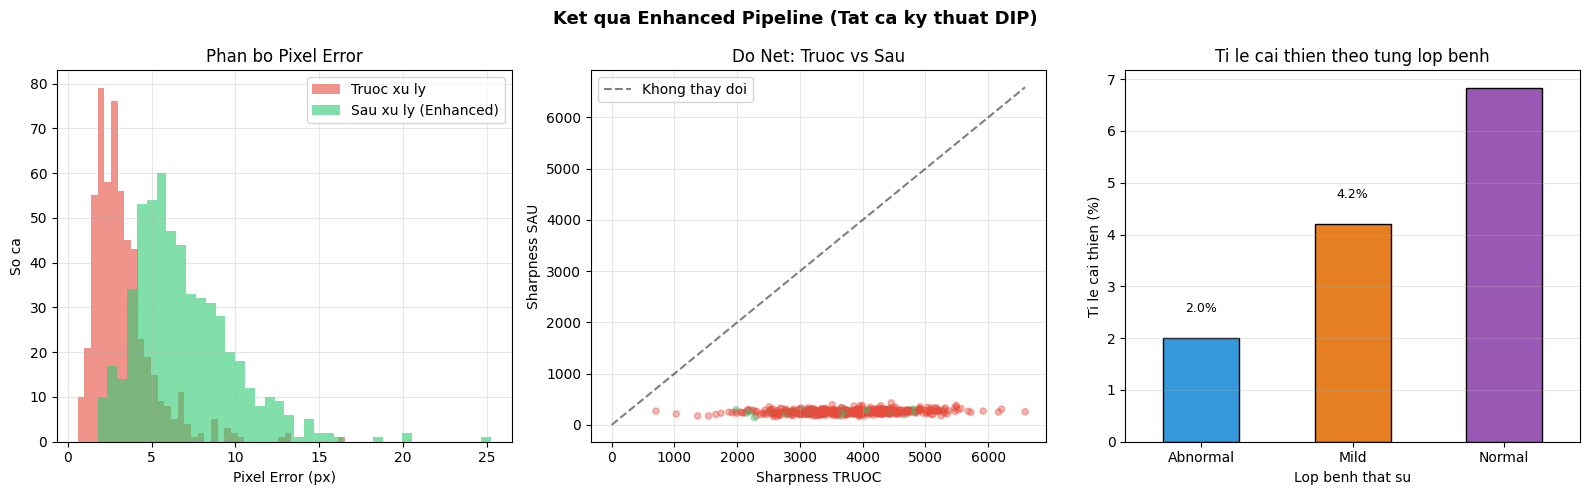

Da luu ket qua: error_analysis_enhanced/enhanced_pipeline_results.csv


In [88]:
# So sánh pipeline cũ vs enhanced pipeline
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Pixel error distribution
axes[0].hist(df_enh['pixel_error_before'], bins=40, alpha=0.6, color='#e74c3c', label='Truoc xu ly')
axes[0].hist(df_enh['pixel_error_after'],  bins=40, alpha=0.6, color='#2ecc71', label='Sau xu ly (Enhanced)')
axes[0].set_xlabel('Pixel Error (px)')
axes[0].set_ylabel('So ca')
axes[0].set_title('Phan bo Pixel Error')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 2. Sharpness improvement
axes[1].scatter(df_enh['sharpness_before'], df_enh['sharpness_after'],
                alpha=0.4, c=df_enh['improved'].map({True:'#2ecc71', False:'#e74c3c'}), s=20)
max_val = max(df_enh['sharpness_before'].max(), df_enh['sharpness_after'].max())
axes[1].plot([0, max_val], [0, max_val], 'k--', alpha=0.5, label='Khong thay doi')
axes[1].set_xlabel('Sharpness TRUOC')
axes[1].set_ylabel('Sharpness SAU')
axes[1].set_title('Do Net: Truoc vs Sau')
axes[1].legend()
axes[1].grid(alpha=0.3)

# 3. Improvement bar chart by class
imp_by_class = df_enh.groupby('actual_class')['improved'].agg(['sum','count'])
imp_by_class['rate'] = imp_by_class['sum'] / imp_by_class['count'] * 100
imp_by_class['rate'].plot(kind='bar', ax=axes[2], color=['#3498db','#e67e22','#9b59b6'], edgecolor='black')
axes[2].set_title('Ti le cai thien theo tung lop benh')
axes[2].set_ylabel('Ti le cai thien (%)')
axes[2].set_xlabel('Lop benh that su')
axes[2].tick_params(axis='x', rotation=0)
axes[2].grid(axis='y', alpha=0.3)
for p in axes[2].patches:
    axes[2].annotate(f'{p.get_height():.1f}%', (p.get_x()+p.get_width()/2, p.get_height()+0.5),
                     ha='center', fontsize=9)

plt.suptitle('Ket qua Enhanced Pipeline (Tat ca ky thuat DIP)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

csv_path = os.path.join(OUTPUT_DIR, "enhanced_pipeline_results.csv")
df_enh.to_csv(csv_path, index=False)
print(f"Da luu ket qua: {csv_path}")


Số ca đúng — Train: 4524 | Val: 700 | Test: 721
Tổng số ảnh đã đo: 11890

NGƯỠNG PHÂN LOẠI KỊCH BẢN (Percentile 5th / 95th)

SHARPNESS:
  Mean ± Std:            3779.28 ± 837.46
  Ngưỡng LOW  (5th pct): 2366.35  ← Dưới = LỖI
  Ngưỡng HIGH (95th pct):5121.31  ← Trên = LỖI

CONTRAST:
  Mean ± Std:            48.89 ± 8.01
  Ngưỡng LOW  (5th pct): 35.70  ← Dưới = LỖI
  Ngưỡng HIGH (95th pct):62.09  ← Trên = LỖI

MEAN_BRIGHTNESS:
  Mean ± Std:            32.86 ± 8.09
  Ngưỡng LOW  (5th pct): 20.58  ← Dưới = LỖI
  Ngưỡng HIGH (95th pct):47.13  ← Trên = LỖI


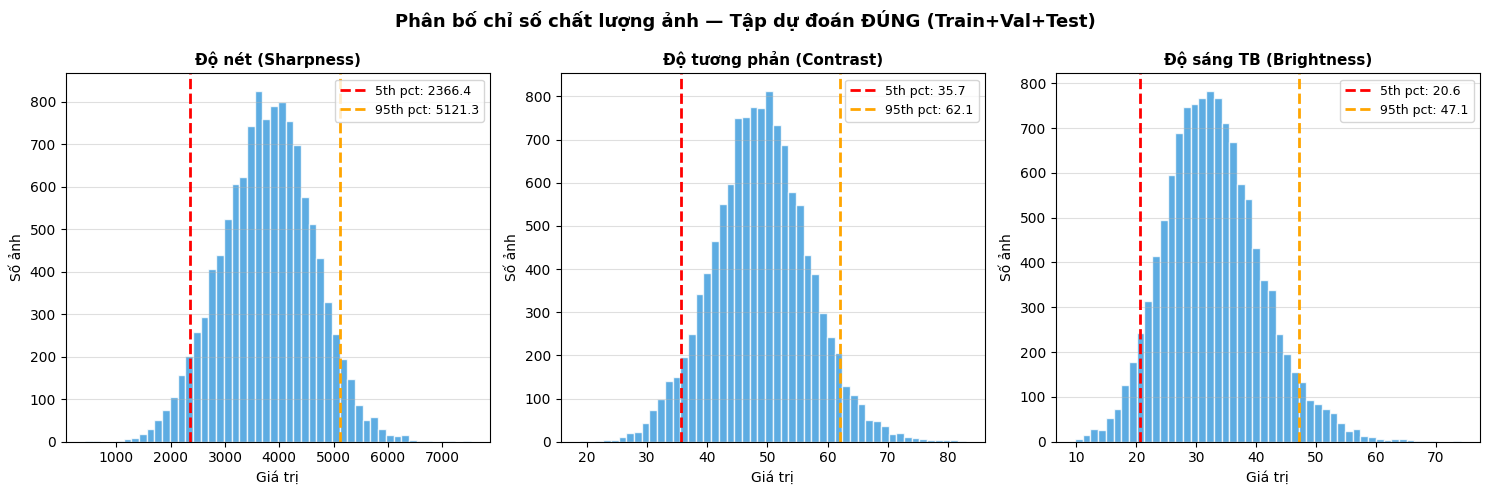

Đã lưu: thresholds_distribution.png


In [89]:
# Lấy index các ca dự đoán ĐÚNG từ 3 tập
correct_train = training_output_df[
    training_output_df['Actual_HFClass'] == training_output_df['Pred_HFClass']
].index.tolist()
correct_val = val_output_df[
    val_output_df['Actual_HFClass'] == val_output_df['Pred_HFClass']
].index.tolist()
correct_test = test_output_df[
    test_output_df['Actual_HFClass'] == test_output_df['Pred_HFClass']
].index.tolist()

print(f"Số ca đúng — Train: {len(correct_train)} | Val: {len(correct_val)} | Test: {len(correct_test)}")

# Đo 3 chỉ số trên tất cả ảnh đúng (cả ED lẫn ES)
all_metrics = []
for images, indices, split_name in [
    (train_images, correct_train, 'train'),
    (val_images,   correct_val,   'val'),
    (test_images,  correct_test,  'test'),
]:
    for idx in indices:
        for offset in [0, 1]:
            img_gray = rgb_to_gray(images[2 * idx + offset])
            m = measure_image_quality(img_gray)
            m['split'] = split_name
            all_metrics.append(m)

df_metrics = pd.DataFrame(all_metrics)
print(f"Tổng số ảnh đã đo: {len(df_metrics)}")

# Tính ngưỡng bằng Percentile
thresholds = {}
for col in ['sharpness', 'contrast', 'mean_brightness']:
    thresholds[col] = {
        'low':  float(np.percentile(df_metrics[col], 5)),
        'high': float(np.percentile(df_metrics[col], 95)),
        'mean': float(df_metrics[col].mean()),
        'std':  float(df_metrics[col].std()),
    }

print("\n" + "="*55)
print("NGƯỠNG PHÂN LOẠI KỊCH BẢN (Percentile 5th / 95th)")
print("="*55)
for metric, vals in thresholds.items():
    print(f"\n{metric.upper()}:")
    print(f"  Mean ± Std:            {vals['mean']:.2f} ± {vals['std']:.2f}")
    print(f"  Ngưỡng LOW  (5th pct): {vals['low']:.2f}  ← Dưới = LỖI")
    print(f"  Ngưỡng HIGH (95th pct):{vals['high']:.2f}  ← Trên = LỖI")

# Vẽ Histogram phân bố
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Phân bố chỉ số chất lượng ảnh — Tập dự đoán ĐÚNG (Train+Val+Test)",
             fontsize=13, fontweight='bold')
labels = {
    'sharpness': 'Độ nét (Sharpness)',
    'contrast':  'Độ tương phản (Contrast)',
    'mean_brightness': 'Độ sáng TB (Brightness)'
}
for ax, col in zip(axes, ['sharpness', 'contrast', 'mean_brightness']):
    ax.hist(df_metrics[col], bins=50, color='#3498db', edgecolor='white', alpha=0.8)
    ax.axvline(thresholds[col]['low'],  color='red',    linestyle='--',
               linewidth=2, label=f"5th pct: {thresholds[col]['low']:.1f}")
    ax.axvline(thresholds[col]['high'], color='orange', linestyle='--',
               linewidth=2, label=f"95th pct: {thresholds[col]['high']:.1f}")
    ax.set_title(labels[col], fontsize=11, fontweight='bold')
    ax.set_xlabel("Giá trị"); ax.set_ylabel("Số ảnh")
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig("thresholds_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("Đã lưu: thresholds_distribution.png")


In [90]:
# Lấy TẤT CẢ ca bị chuẩn đoán sai bệnh từ tập Test
misclassified = test_output_df[
    test_output_df['Actual_HFClass'] != test_output_df['Pred_HFClass']
].index.tolist()

print(f"Tổng ca chuẩn đoán sai: {len(misclassified)}")
print()
print("Chi tiết từng loại lỗi chuẩn đoán:")
wrong_df = test_output_df[test_output_df['Actual_HFClass'] != test_output_df['Pred_HFClass']]
print(wrong_df.groupby(['Actual_HFClass', 'Pred_HFClass']).size()
               .reset_index(name='Số ca').to_string(index=False))


Tổng ca chuẩn đoán sai: 555

Chi tiết từng loại lỗi chuẩn đoán:
Actual_HFClass Pred_HFClass  Số ca
        Normal       Normal      0
        Normal         Mild    156
        Normal     Abnormal    254
          Mild       Normal     43
          Mild         Mild      0
          Mild     Abnormal     52
      Abnormal       Normal     25
      Abnormal         Mild     25
      Abnormal     Abnormal      0


/tmp/ipykernel_23/3951398793.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(wrong_df.groupby(['Actual_HFClass', 'Pred_HFClass']).size()


In [91]:
OUTPUT_DIR = "error_analysis"
os.makedirs(OUTPUT_DIR, exist_ok=True)

results = []
print(f"Bắt đầu xử lý {len(misclassified)} ca lỗi...\n")

for i, idx in enumerate(misclassified):
    patient_id   = test_ids[2 * idx]
    actual_class = str(test_output_df['Actual_HFClass'].iloc[idx])
    pred_class   = str(test_output_df['Pred_HFClass'].iloc[idx])

    # Lấy ảnh ED của ca này
    img_rgb  = test_images[2 * idx].astype(np.uint8)
    img_gray = rgb_to_gray(img_rgb)

    # Đo chất lượng TRƯỚC
    metrics_before = measure_image_quality(img_gray)
    scenarios      = classify_scenario(metrics_before, thresholds)

    # Xử lý ảnh
    img_gray_proc = apply_pipeline(img_gray, scenarios, metrics_before, thresholds)
    img_rgb_proc  = gray_to_rgb(img_gray_proc)

    # Đo chất lượng SAU
    metrics_after = measure_image_quality(img_gray_proc)

    # Chạy lại Model
    gt_kps      = test_keypoints_conv[2 * idx]
    pred_before = model_2.predict(img_rgb.reshape(1, IMAGE_SIZE, IMAGE_SIZE, 3), verbose=0)
    pred_after  = model_2.predict(img_rgb_proc.reshape(1, IMAGE_SIZE, IMAGE_SIZE, 3), verbose=0)

    err_before = float(np.mean(np.abs(pred_before - gt_kps)) * IMAGE_SIZE)
    err_after  = float(np.mean(np.abs(pred_after  - gt_kps)) * IMAGE_SIZE)

    results.append({
        'patient_id':         patient_id,
        'actual_class':       actual_class,
        'pred_class_before':  pred_class,
        'scenario':           '+'.join(scenarios),
        'sharpness_before':   round(metrics_before['sharpness'], 2),
        'sharpness_after':    round(metrics_after['sharpness'],  2),
        'contrast_before':    round(metrics_before['contrast'],  2),
        'contrast_after':     round(metrics_after['contrast'],   2),
        'brightness_before':  round(metrics_before['mean_brightness'], 2),
        'brightness_after':   round(metrics_after['mean_brightness'],  2),
        'pixel_error_before': round(err_before, 4),
        'pixel_error_after':  round(err_after,  4),
        'improved':           err_after < err_before
    })

    if (i + 1) % 50 == 0 or (i + 1) == len(misclassified):
        print(f"  [{i+1}/{len(misclassified)}] Đã xử lý.")

print("Hoàn tất xử lý!")


Bắt đầu xử lý 555 ca lỗi...

  [50/555] Đã xử lý.
  [100/555] Đã xử lý.
  [150/555] Đã xử lý.
  [200/555] Đã xử lý.
  [250/555] Đã xử lý.
  [300/555] Đã xử lý.
  [350/555] Đã xử lý.
  [400/555] Đã xử lý.
  [450/555] Đã xử lý.
  [500/555] Đã xử lý.
  [550/555] Đã xử lý.
  [555/555] Đã xử lý.
Hoàn tất xử lý!


In [92]:
df_results = pd.DataFrame(results)
csv_path   = os.path.join(OUTPUT_DIR, "image_processing_results.csv")
df_results.to_csv(csv_path, index=False)

total            = len(df_results)
improved_count   = df_results['improved'].sum()
improvement_rate = improved_count / total * 100
avg_before       = df_results['pixel_error_before'].mean()
avg_after        = df_results['pixel_error_after'].mean()

print("=" * 55)
print("BÁO CÁO KẾT QUẢ XỬ LÝ ẢNH")
print("=" * 55)
print(f"Tổng ca phân tích:        {total}")
print(f"Số ca được cải thiện:     {improved_count} ({improvement_rate:.1f}%)")
print(f"Pixel error TB TRƯỚC:     {avg_before:.2f} px")
print(f"Pixel error TB SAU:       {avg_after:.2f} px")
print(f"Cải thiện TB:             {avg_before - avg_after:.2f} px")
print("=" * 55)
print(f"\nFile CSV: {csv_path}")
print("\nPhân bố kịch bản lỗi:")
print(df_results['scenario'].value_counts().to_string())


BÁO CÁO KẾT QUẢ XỬ LÝ ẢNH
Tổng ca phân tích:        555
Số ca được cải thiện:     47 (8.5%)
Pixel error TB TRƯỚC:     3.27 px
Pixel error TB SAU:       6.45 px
Cải thiện TB:             -3.17 px

File CSV: error_analysis/image_processing_results.csv

Phân bố kịch bản lỗi:
scenario
A        461
E         40
C         15
F         11
B          9
F+B        9
B+C        4
F+B+C      4
E+C        1
F+C        1


Xuất ảnh cho 10 ca cải thiện rõ rệt nhất...


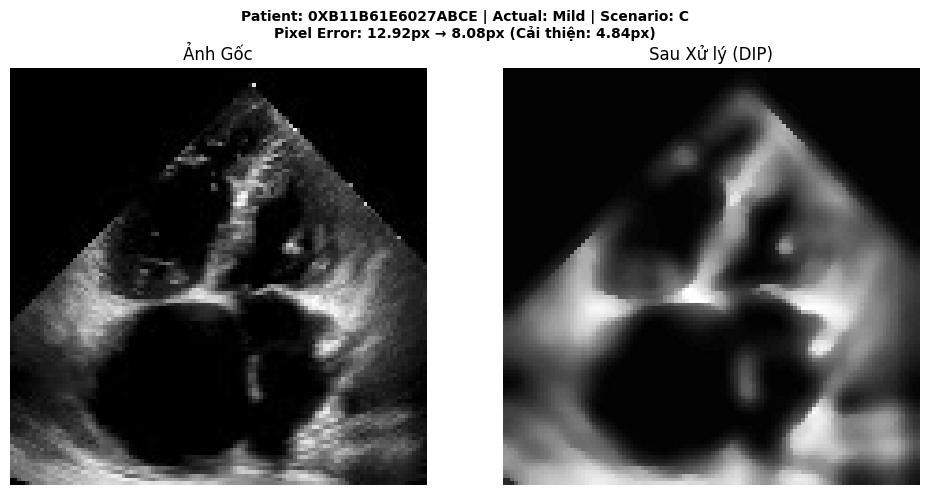

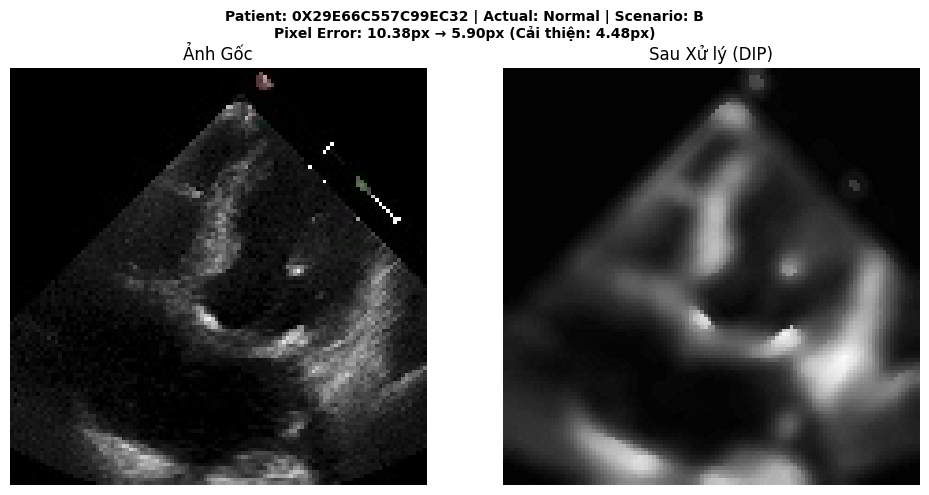

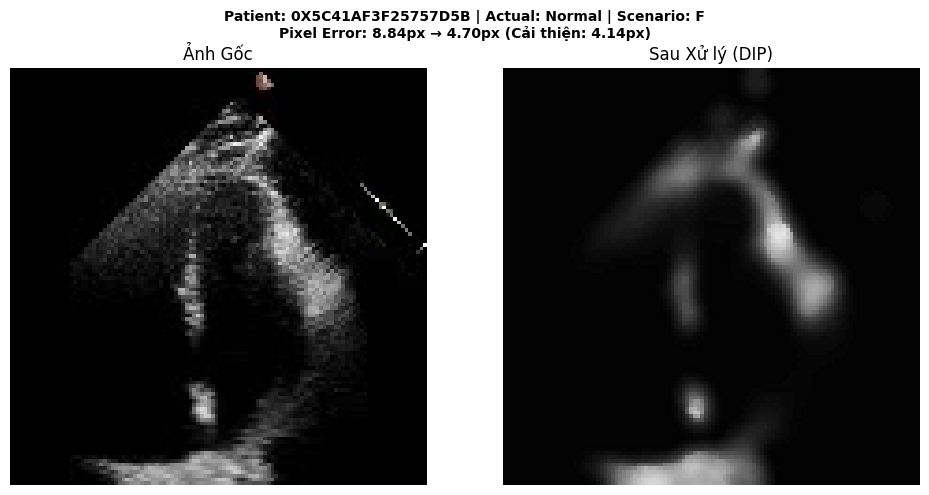

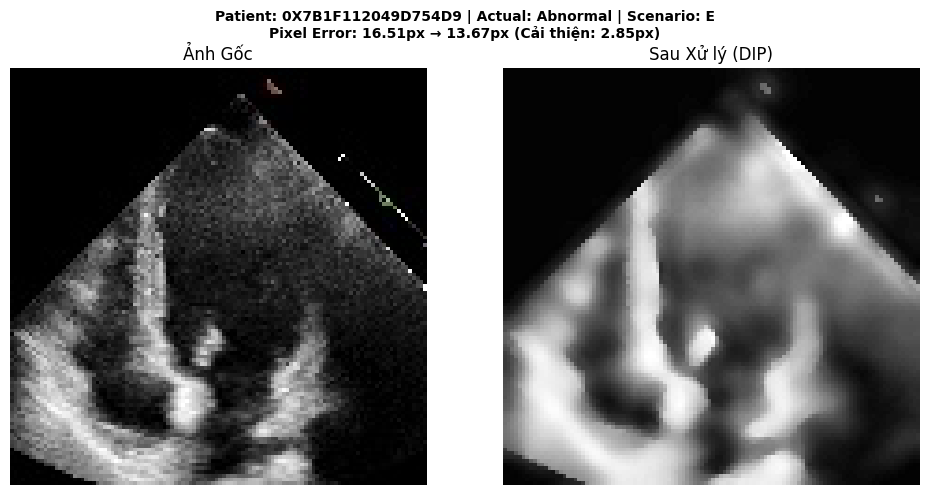

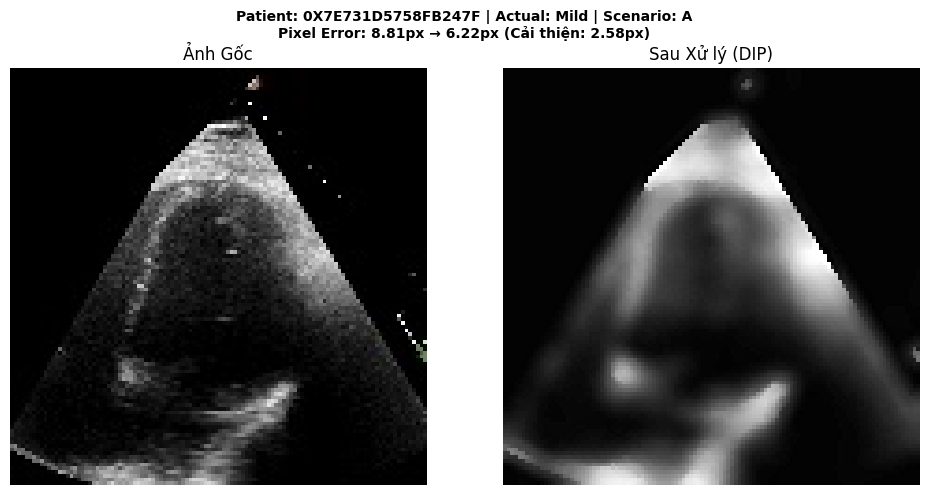

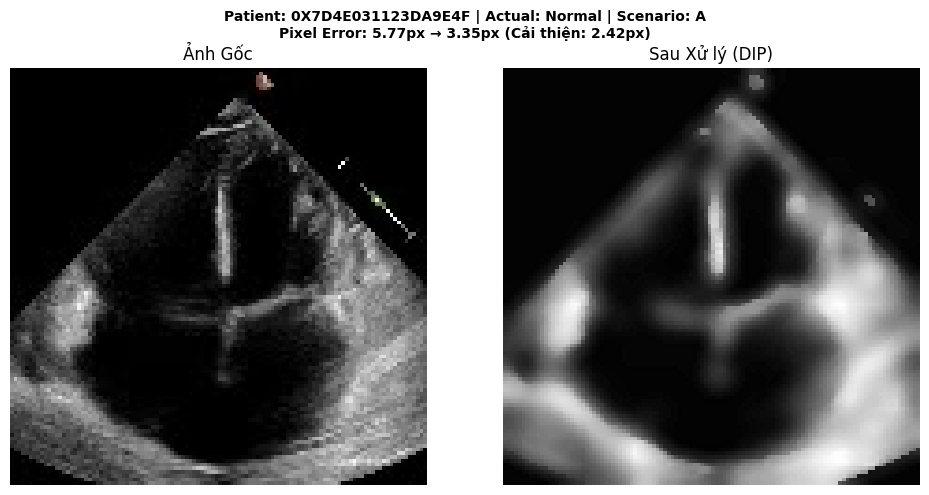

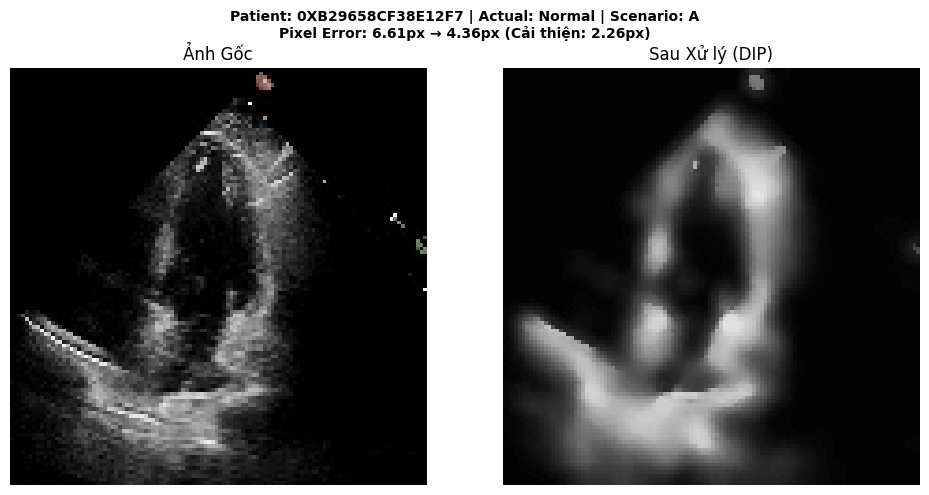

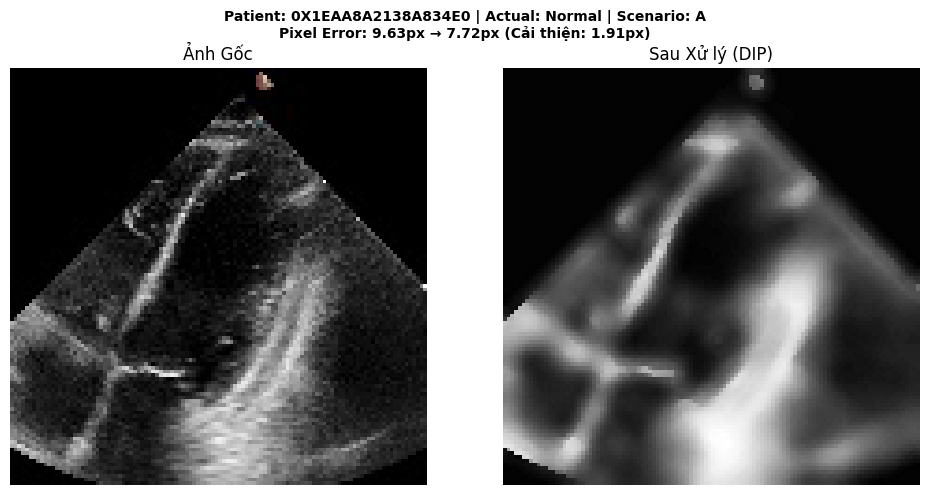

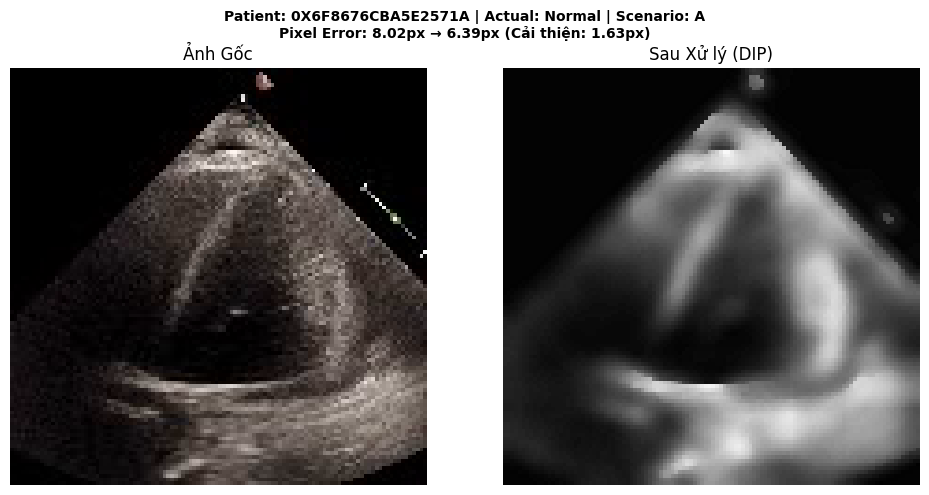

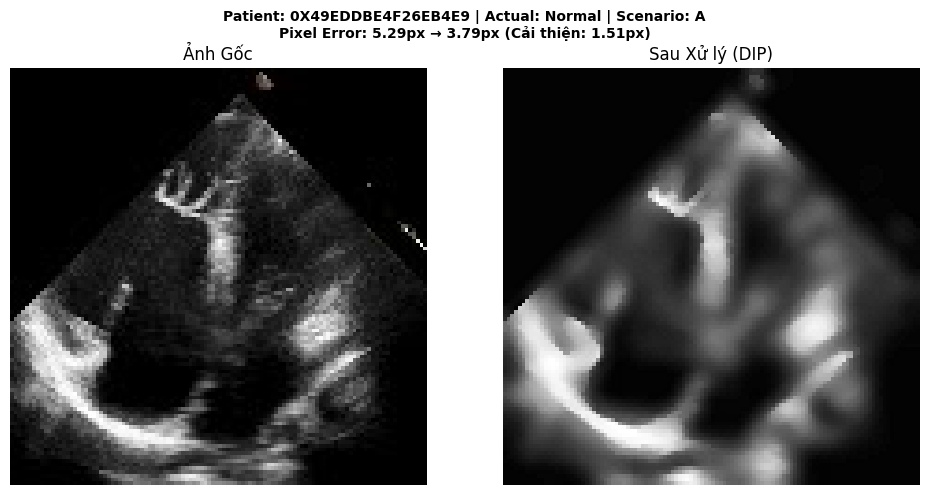

Hoàn tất! Toàn bộ kết quả trong thư mục 'error_analysis'.


In [93]:
df_results['improvement_px'] = (df_results['pixel_error_before']
                                 - df_results['pixel_error_after'])
top10 = df_results.nlargest(10, 'improvement_px')

print(f"Xuất ảnh cho {len(top10)} ca cải thiện rõ rệt nhất...")

for _, row in top10.iterrows():
    pid = row['patient_id']
    idx = next((i // 2 for i, x in enumerate(test_ids)
                if x == pid and i % 2 == 0), None)
    if idx is None:
        continue

    img_rgb       = test_images[2 * idx].astype(np.uint8)
    img_gray      = rgb_to_gray(img_rgb)
    metrics       = measure_image_quality(img_gray)
    scenarios     = classify_scenario(metrics, thresholds)
    img_processed = gray_to_rgb(apply_pipeline(img_gray, scenarios, metrics, thresholds))

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    fig.suptitle(
        f"Patient: {pid} | Actual: {row['actual_class']} | Scenario: {row['scenario']}\n"
        f"Pixel Error: {row['pixel_error_before']:.2f}px → {row['pixel_error_after']:.2f}px "
        f"(Cải thiện: {row['improvement_px']:.2f}px)",
        fontsize=10, fontweight='bold'
    )
    axes[0].imshow(img_rgb);        axes[0].set_title("Ảnh Gốc");        axes[0].axis('off')
    axes[1].imshow(img_processed);  axes[1].set_title("Sau Xử lý (DIP)"); axes[1].axis('off')
    plt.tight_layout()

    save_path = os.path.join(OUTPUT_DIR, f"compare_{pid}.png")
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

print(f"Hoàn tất! Toàn bộ kết quả trong thư mục '{OUTPUT_DIR}'.")


# Phần 11: Nâng cấp Baseline — Fine-tuning MobileNetV2 Backbone

Trong Phần 6, MobileNetV2 backbone bị **đóng băng hoàn toàn** (frozen). Phần này áp dụng **progressive unfreezing** để model tự điều chỉnh các đặc trưng backbone cho phù hợp với ảnh siêu âm tim.

### Chiến lược 3 Phase:
| Phase | Backbone | Learning Rate | Epochs | Mục tiêu |
|---|---|---|---|---|
| **1** | Frozen 100% | 1e-3 | 30 | Warm-up head mới |
| **2** | Mở 30% cuối | 1e-4 | 50 | Fine-tune lớp đặc trưng cao cấp |
| **3** | Mở 100% | 5e-6 | 80 | Full fine-tune toàn bộ backbone |

### 11.1 — Scan Layer Names MobileNetV2

In [94]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Lấy backbone từ model_2 đã train
backbone_layers = [(i, l.name, l.trainable) 
                   for i, l in enumerate(model_2.layers)
                   if 'mobilenet' in l.name.lower() or i < 5]

# Scan tất cả layers của model_2
print(f"model_2 total layers: {len(model_2.layers)}")
print()
print("First 10 layers:")
for i, layer in enumerate(model_2.layers[:10]):
    print(f"  [{i:3d}] {layer.name:50s} trainable={layer.trainable}")
print("...")
print("Last 5 layers:")
for i, layer in enumerate(model_2.layers[-5:], start=len(model_2.layers)-5):
    print(f"  [{i:3d}] {layer.name:50s} trainable={layer.trainable}")


model_2 total layers: 5

First 10 layers:
  [  0] InputLayer                                         trainable=True
  [  1] mobilenetv2_1.00_224                               trainable=False
  [  2] DropOut                                            trainable=True
  [  3] ConvPass                                           trainable=True
  [  4] OutputLayer                                        trainable=True
...
Last 5 layers:
  [  0] InputLayer                                         trainable=True
  [  1] mobilenetv2_1.00_224                               trainable=False
  [  2] DropOut                                            trainable=True
  [  3] ConvPass                                           trainable=True
  [  4] OutputLayer                                        trainable=True


### 11.2 — Định nghĩa Model Fine-tuning (Warm Start từ model_2)

In [95]:
def build_finetuned_model(base_model, freeze_ratio=1.0):
    """
    Tái sử dụng model_2 với khả năng mở khóa backbone dần dần.
    freeze_ratio=1.0 → frozen hoàn toàn; =0.0 → mở toàn bộ.
    """
    import tensorflow as tf
    
    # Clone model để không ảnh hưởng model_2 gốc
    ft_model = tf.keras.models.clone_model(base_model)
    ft_model.set_weights(base_model.get_weights())  # Transfer weights từ model_2
    
    # Tìm backbone layer (MobileNetV2)
    backbone = None
    for layer in ft_model.layers:
        if hasattr(layer, 'layers') and len(layer.layers) > 10:
            backbone = layer
            break
    
    if backbone is None:
        print("Khong tim thay backbone, train toan bo model.")
        return ft_model
    
    total_backbone_layers = len(backbone.layers)
    freeze_until = int(total_backbone_layers * freeze_ratio)
    
    for i, layer in enumerate(backbone.layers):
        layer.trainable = (i >= freeze_until)
    
    frozen_count = sum(1 for l in backbone.layers if not l.trainable)
    open_count   = sum(1 for l in backbone.layers if l.trainable)
    print(f"Backbone: {total_backbone_layers} layers | Frozen: {frozen_count} | Open: {open_count}")
    print(f"Freeze ratio: {freeze_ratio:.0%}")
    
    return ft_model

# Test: Phase 1 setup (frozen 100%)
model_ft = build_finetuned_model(model_2, freeze_ratio=1.0)
print(f"\nmodel_ft tong so params: {model_ft.count_params():,}")
trainable = sum(np.prod(v.shape) for v in model_ft.trainable_variables)
print(f"Trainable params: {trainable:,}")


Backbone: 154 layers | Frozen: 154 | Open: 0
Freeze ratio: 100%

model_ft tong so params: 2,384,584
Trainable params: 126,600


### 11.3 — Phase 1: Backbone Frozen, Warm-up Head

In [96]:
import os

os.makedirs('ft_checkpoints', exist_ok=True)

# Reshape keypoints cho model
train_kps_flat = train_keypoints_conv.reshape(-1, NUM_KEYPOINTS)
val_kps_flat   = val_keypoints_conv.reshape(-1, NUM_KEYPOINTS)


# Phase 1: frozen backbone, train head
model_ft_p1 = build_finetuned_model(model_2, freeze_ratio=1.0)
model_ft_p1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae']
)

callbacks_p1 = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    tf.keras.callbacks.ModelCheckpoint('ft_checkpoints/phase1_best.keras', save_best_only=True, verbose=0),
]

print("=== PHASE 1: Backbone frozen 100%, LR=1e-3, max 200 epochs ===")
history_p1 = model_ft_p1.fit(
    train_images, train_keypoints_conv,
    validation_data=(val_images, val_kps_flat),
    batch_size=32,
    epochs=200,
    callbacks=callbacks_p1,
    verbose=1
)
print("Phase 1 hoan tat!")


Backbone: 154 layers | Frozen: 154 | Open: 0
Freeze ratio: 100%
=== PHASE 1: Backbone frozen 100%, LR=1e-3, max 200 epochs ===
Epoch 1/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 25s 36ms/step - loss: 0.0014 - mae: 0.0253 - val_loss: 0.0080 - val_mae: 0.0673 - learning_rate: 0.0010
Epoch 2/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0014 - mae: 0.0255 - val_loss: 0.0079 - val_mae: 0.0665 - learning_rate: 0.0010
Epoch 3/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0014 - mae: 0.0253 - val_loss: 0.0075 - val_mae: 0.0650 - learning_rate: 0.0010
Epoch 4/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0013 - mae: 0.0252 - val_loss: 0.0078 - val_mae: 0.0657 - learning_rate: 0.0010
Epoch 5/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0013 - mae: 0.0248 - val_loss: 0.0078 - val_mae: 0.0663 - learning_rate: 0.0010
Epoch 6/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0013 - mae: 0.0247 - val_loss: 0.0080 - val_mae: 0.0673 - learning_rate: 0.0010
Epoch 7/

### 11.4 — Phase 2: Mở 30% Cuối Backbone

In [97]:
# Phase 2: mở 30% cuối backbone
model_ft_p2 = build_finetuned_model(model_ft_p1, freeze_ratio=0.7)
model_ft_p2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='mse',
    metrics=['mae']
)

callbacks_p2 = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    tf.keras.callbacks.ModelCheckpoint('ft_checkpoints/phase2_best.keras', save_best_only=True, verbose=0),
]

print("=== PHASE 2: Mo 30% backbone, LR=1e-4, max 200 epochs ===")
history_p2 = model_ft_p2.fit(
    train_images, train_keypoints_conv,
    validation_data=(val_images, val_kps_flat),
    batch_size=16,
    epochs=200,
    callbacks=callbacks_p2,
    verbose=1
)
print("Phase 2 hoan tat!")


Backbone: 154 layers | Frozen: 107 | Open: 47
Freeze ratio: 70%
=== PHASE 2: Mo 30% backbone, LR=1e-4, max 200 epochs ===
Epoch 1/200


2026-05-10 01:20:28.139387: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 01:20:28.301167: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 01:20:29.422700: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 01:20:29.561709: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 01:20:29.755195: E external/local_xla/xla/stream_

927/931 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0035 - mae: 0.0421

2026-05-10 01:20:48.436104: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 01:20:48.598989: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 01:20:48.744047: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


931/931 ━━━━━━━━━━━━━━━━━━━━ 47s 27ms/step - loss: 0.0035 - mae: 0.0421 - val_loss: 0.0113 - val_mae: 0.0818 - learning_rate: 1.0000e-04
Epoch 2/200
931/931 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.0015 - mae: 0.0270 - val_loss: 0.0093 - val_mae: 0.0723 - learning_rate: 1.0000e-04
Epoch 3/200
931/931 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.0012 - mae: 0.0234 - val_loss: 0.0087 - val_mae: 0.0693 - learning_rate: 1.0000e-04
Epoch 4/200
931/931 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 9.8974e-04 - mae: 0.0215 - val_loss: 0.0089 - val_mae: 0.0690 - learning_rate: 1.0000e-04
Epoch 5/200
931/931 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 8.6372e-04 - mae: 0.0201 - val_loss: 0.0084 - val_mae: 0.0674 - learning_rate: 1.0000e-04
Epoch 6/200
931/931 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 7.5389e-04 - mae: 0.0190 - val_loss: 0.0085 - val_mae: 0.0680 - learning_rate: 1.0000e-04
Epoch 7/200
931/931 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 7.1549e-04 - mae: 0.0184 - val_loss: 0.0087

### 11.5 — Phase 3: Mở Toàn Bộ Backbone (Full Fine-tune)

In [98]:
# Phase 3: mở toàn bộ backbone, LR rất nhỏ
model_ft_p3 = build_finetuned_model(model_ft_p2, freeze_ratio=0.0)
model_ft_p3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss='mse',
    metrics=['mae']
)

callbacks_p3 = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=6, min_lr=1e-8, verbose=1),
    tf.keras.callbacks.ModelCheckpoint('ft_checkpoints/phase3_best.keras', save_best_only=True, verbose=0),
]

print("=== PHASE 3: Mo 100% backbone, LR=5e-6, max 200 epochs ===")
history_p3 = model_ft_p3.fit(
    train_images, train_keypoints_conv,
    validation_data=(val_images, val_kps_flat),
    batch_size=16,
    epochs=200,
    callbacks=callbacks_p3,
    verbose=1
)
print("Phase 3 hoan tat! Mo khoa backbone thanh cong.")


Backbone: 154 layers | Frozen: 0 | Open: 154
Freeze ratio: 0%
=== PHASE 3: Mo 100% backbone, LR=5e-6, max 200 epochs ===
Epoch 1/200
931/931 ━━━━━━━━━━━━━━━━━━━━ 89s 49ms/step - loss: 0.0014 - mae: 0.0252 - val_loss: 0.0078 - val_mae: 0.0651 - learning_rate: 5.0000e-06
Epoch 2/200
931/931 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - loss: 0.0010 - mae: 0.0217 - val_loss: 0.0079 - val_mae: 0.0656 - learning_rate: 5.0000e-06
Epoch 3/200
931/931 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - loss: 8.6258e-04 - mae: 0.0202 - val_loss: 0.0081 - val_mae: 0.0662 - learning_rate: 5.0000e-06
Epoch 4/200
931/931 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - loss: 8.0465e-04 - mae: 0.0193 - val_loss: 0.0082 - val_mae: 0.0667 - learning_rate: 5.0000e-06
Epoch 5/200
931/931 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - loss: 7.4453e-04 - mae: 0.0187 - val_loss: 0.0083 - val_mae: 0.0669 - learning_rate: 5.0000e-06
Epoch 6/200
931/931 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - loss: 6.9696e-04 - mae: 0.0181 - val_loss: 0.0083 - val_mae: 0.06

### 11.6 — Learning Curves Tổng hợp 3 Phase

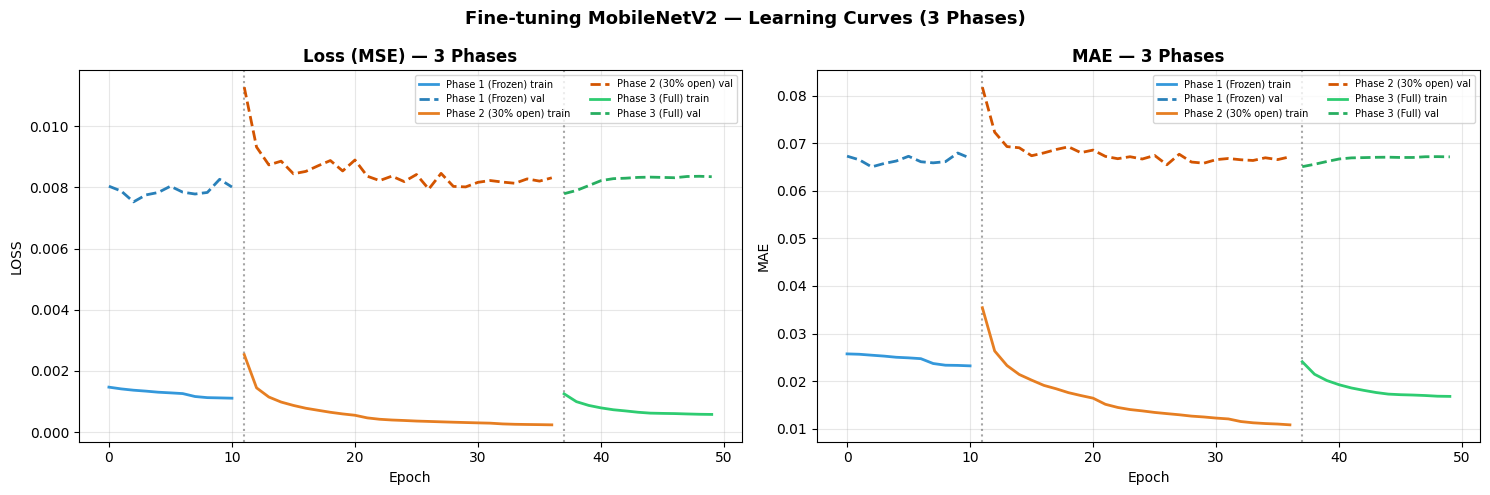

In [99]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
colors = [('#3498db','#2980b9'), ('#e67e22','#d35400'), ('#2ecc71','#27ae60')]
phase_names = ['Phase 1 (Frozen)', 'Phase 2 (30% open)', 'Phase 3 (Full)']

for ax_idx, metric in enumerate(['loss', 'mae']):
    offset = 0
    for ph_idx, (hist, (c1, c2), name) in enumerate(zip(
            [history_p1, history_p2, history_p3], colors, phase_names)):
        epochs = range(offset, offset + len(hist.history[metric]))
        axes[ax_idx].plot(epochs, hist.history[metric],     color=c1, linewidth=2, label=f'{name} train')
        axes[ax_idx].plot(epochs, hist.history[f'val_{metric}'], color=c2, linewidth=2, linestyle='--', label=f'{name} val')
        # Vẽ đường phân cách phase
        if ph_idx < 2:
            axes[ax_idx].axvline(x=offset+len(hist.history[metric]), color='gray', linestyle=':', alpha=0.7)
        offset += len(hist.history[metric])
    
    axes[ax_idx].set_title(f'{"Loss (MSE)" if metric=="loss" else "MAE"} — 3 Phases', fontsize=12, fontweight='bold')
    axes[ax_idx].set_xlabel('Epoch')
    axes[ax_idx].set_ylabel(metric.upper())
    axes[ax_idx].legend(fontsize=7, ncol=2)
    axes[ax_idx].grid(alpha=0.3)

plt.suptitle('Fine-tuning MobileNetV2 — Learning Curves (3 Phases)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 11.7 — Đánh giá Model Fine-tuned trên Tập Test

In [100]:
# Dự đoán với model fine-tuned
predicted_train_ft = get_predicted_points(train_images, model_ft_p3)
predicted_val_ft   = get_predicted_points(val_images,   model_ft_p3)
predicted_test_ft  = get_predicted_points(test_images,  model_ft_p3)

training_output_ft = build_dataframe_EFs(train_keypoints_conv, predicted_train_ft)
val_output_ft      = build_dataframe_EFs(val_keypoints_conv,   predicted_val_ft)
test_output_ft     = build_dataframe_EFs(test_keypoints_conv,  predicted_test_ft)

print("=== KET QUA MODEL FINE-TUNED (PHAN 11) ===")
print("\nTraining:")
Accuracy_ConfusionMatrix(training_output_ft.Actual_HFClass, training_output_ft.Pred_HFClass, ['Normal','Mild','Abnormal'])
print("\nValidation:")
Accuracy_ConfusionMatrix(val_output_ft.Actual_HFClass, val_output_ft.Pred_HFClass, ['Normal','Mild','Abnormal'])
print("\nTest:")
Accuracy_ConfusionMatrix(test_output_ft.Actual_HFClass, test_output_ft.Pred_HFClass, ['Normal','Mild','Abnormal'])


466/466 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step
=== KET QUA MODEL FINE-TUNED (PHAN 11) ===

Training:
Accuracy of model: 0.6250839264133208
Predicted  Normal  Mild  Abnormal
Actual                           
Normal       3781   948       978
Mild          252   169       326
Abnormal      125   163       705
Sensitivity of model for individual classes
Class Normal : 0.6625197126336079
Class Mild : 0.22623828647925034
Class Abnormal : 0.7099697885196374

Validation:
Accuracy of model: 0.6156832298136646
Predicted  Normal  Mild  Abnormal
Actual                           
Normal        647   144       197
Mild           42    31        62
Abnormal       30    20       115
Sensitivity of model for individual classes
Class Normal : 0.6548582995951417
Class Mild : 0.22962962962962963
Class Abnormal : 0.696969696969697

Test:
Accuracy of model: 0.5932601880877743
Predicted  Normal  Mild  Abnormal
Actual                

In [101]:
# Dự đoán với model fine-tuned
predicted_train_ft = get_predicted_points(train_images, model_ft_p3)
predicted_val_ft   = get_predicted_points(val_images,   model_ft_p3)
predicted_test_ft  = get_predicted_points(test_images,  model_ft_p3)

training_output_ft = build_dataframe_EFs(train_keypoints_conv, predicted_train_ft)
val_output_ft      = build_dataframe_EFs(val_keypoints_conv,   predicted_val_ft)
test_output_ft     = build_dataframe_EFs(test_keypoints_conv,  predicted_test_ft)

print("=== KET QUA MODEL FINE-TUNED (PHAN 11) ===")
print("\nTraining:")
Accuracy_ConfusionMatrix(training_output_ft.Actual_HFClass, training_output_ft.Pred_HFClass, ['Normal','Mild','Abnormal'])
print("\nValidation:")
Accuracy_ConfusionMatrix(val_output_ft.Actual_HFClass, val_output_ft.Pred_HFClass, ['Normal','Mild','Abnormal'])
print("\nTest:")
Accuracy_ConfusionMatrix(test_output_ft.Actual_HFClass, test_output_ft.Pred_HFClass, ['Normal','Mild','Abnormal'])


466/466 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
=== KET QUA MODEL FINE-TUNED (PHAN 11) ===

Training:
Accuracy of model: 0.6250839264133208
Predicted  Normal  Mild  Abnormal
Actual                           
Normal       3781   948       978
Mild          252   169       326
Abnormal      125   163       705
Sensitivity of model for individual classes
Class Normal : 0.6625197126336079
Class Mild : 0.22623828647925034
Class Abnormal : 0.7099697885196374

Validation:
Accuracy of model: 0.6156832298136646
Predicted  Normal  Mild  Abnormal
Actual                           
Normal        647   144       197
Mild           42    31        62
Abnormal       30    20       115
Sensitivity of model for individual classes
Class Normal : 0.6548582995951417
Class Mild : 0.22962962962962963
Class Abnormal : 0.696969696969697

Test:
Accuracy of model: 0.5932601880877743
Predicted  Normal  Mild  Abnormal
Actual                    

# Phần 12: Advanced Model — EfficientNetB3 + FPN + Adaptive Wing Loss

Phần này xây dựng **model hoàn toàn mới** với kiến trúc tiên tiến hơn để so sánh với baseline và fine-tuned model.

| Thành phần | Phần 6 (Baseline) | Phần 11 (Fine-tuned) | **Phần 12 (Advanced)** |
|---|---|---|---|
| Backbone | MobileNetV2 | MobileNetV2 (unfrozen) | **EfficientNetB3** |
| Neck | Không có | Không có | **FPN (Feature Pyramid Network)** |
| Loss | MSE | MSE | **Adaptive Wing Loss** |
| Tham số | ~3.5M | ~3.5M | **~12M** |

### 12.1 — Learnable DIP Filter Blocks

In [102]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

class LearnableDenoise(tf.keras.layers.Layer):
    """Conv block hoc loc nhieu thich nghi."""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.conv1 = tf.keras.layers.Conv2D(8, 3, padding='same', activation='relu')
        self.conv2 = tf.keras.layers.Conv2D(3, 3, padding='same', activation='sigmoid')
        self.bn    = tf.keras.layers.BatchNormalization()
    def call(self, x, training=False):
        residual = x
        h = self.conv1(x)
        h = self.bn(h, training=training)
        h = self.conv2(h)
        return residual * h  # Learned multiplicative gate

class LearnableCLAHE(tf.keras.layers.Layer):
    """Attention-based contrast enhancement."""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.gap  = tf.keras.layers.GlobalAveragePooling2D()
        self.fc1  = tf.keras.layers.Dense(16, activation='relu')
        self.fc2  = tf.keras.layers.Dense(3,  activation='sigmoid')
        self.reshape = tf.keras.layers.Reshape((1, 1, 3))
    def call(self, x, training=False):
        w = self.gap(x)
        w = self.fc1(w)
        w = self.fc2(w)
        w = self.reshape(w)
        return x * w

class LearnableSharpen(tf.keras.layers.Layer):
    """Learnable unsharp masking."""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.conv    = tf.keras.layers.Conv2D(3, 3, padding='same', activation='relu')
        self.alpha   = tf.Variable(0.5, trainable=True, dtype=tf.float32, name='sharpen_alpha')
    def call(self, x, training=False):
        detail = x - self.conv(x)
        return x + self.alpha * detail

print("Da dinh nghia: LearnableDenoise, LearnableCLAHE, LearnableSharpen")


Da dinh nghia: LearnableDenoise, LearnableCLAHE, LearnableSharpen


### 12.2 — FPN và Spatial Attention

In [103]:
def build_fpn(c3, c4, c5, out_channels=128):
    """Feature Pyramid Network: hop nhat da tang dac trung."""
    # Top-down pathway
    p5 = tf.keras.layers.Conv2D(out_channels, 1, padding='same')(c5)
    
    # Resize p5 to exactly match c4 spatial dimensions
    p5_up = tf.keras.layers.Resizing(c4.shape[1], c4.shape[2])(p5)
    p4 = tf.keras.layers.Add()([
        p5_up,
        tf.keras.layers.Conv2D(out_channels, 1, padding='same')(c4)
    ])
    
    # Resize p4 to exactly match c3 spatial dimensions
    p4_up = tf.keras.layers.Resizing(c3.shape[1], c3.shape[2])(p4)
    p3 = tf.keras.layers.Add()([
        p4_up,
        tf.keras.layers.Conv2D(out_channels, 1, padding='same')(c3)
    ])
    
    # Smooth
    p3 = tf.keras.layers.Conv2D(out_channels, 3, padding='same', activation='relu')(p3)
    p4 = tf.keras.layers.Conv2D(out_channels, 3, padding='same', activation='relu')(p4)
    p5 = tf.keras.layers.Conv2D(out_channels, 3, padding='same', activation='relu')(p5)
    return p3, p4, p5

def spatial_attention(x):
    """CBAM-style spatial attention."""
    # Bọc các phép toán TF vào lớp Lambda của Keras
    avg_pool = tf.keras.layers.Lambda(lambda t: tf.reduce_mean(t, axis=-1, keepdims=True))(x)
    max_pool = tf.keras.layers.Lambda(lambda t: tf.reduce_max(t, axis=-1, keepdims=True))(x)
    
    concat   = tf.keras.layers.Concatenate()([avg_pool, max_pool])
    attn     = tf.keras.layers.Conv2D(1, 7, padding='same', activation='sigmoid')(concat)
    
    # Bọc phép nhân vào lớp Multiply của Keras
    return tf.keras.layers.Multiply()([x, attn])

print("Da dinh nghia: build_fpn, spatial_attention")


Da dinh nghia: build_fpn, spatial_attention


### 12.3 — Adaptive Wing Loss

In [104]:
def adaptive_wing_loss(y_true, y_pred, omega=14.0, theta=0.5, epsilon=1.0, alpha=2.1):
    """
    Adaptive Wing Loss - hieu qua hon MSE cho keypoint detection.
    Xu ly tot ca truong hop sai so nho va lon.
    """
    delta = tf.abs(y_true - y_pred)
    A = omega * (1.0 / (1.0 + tf.pow(theta / epsilon, alpha - y_true))) *         (alpha - y_true) * tf.pow(theta / epsilon, alpha - y_true - 1) * (1.0 / epsilon)
    C = theta * A - omega * tf.math.log(1.0 + tf.pow(theta / epsilon, alpha - y_true))
    
    loss = tf.where(
        delta < theta,
        omega * tf.math.log(1.0 + tf.pow(delta / epsilon, alpha - y_true)),
        A * delta - C
    )
    return tf.reduce_mean(loss)

print("Da dinh nghia: adaptive_wing_loss")


Da dinh nghia: adaptive_wing_loss


### 12.4 — Build Advanced Model (EfficientNetB3 + FPN)

In [105]:
def build_advanced_model(input_shape=(112, 112, 3), num_keypoints=42):
    inputs = tf.keras.Input(shape=input_shape, name='input_image')

    # DIP Filter Block (Learnable preprocessing)
    x = LearnableDenoise(name='learnable_denoise')(inputs)
    x = LearnableCLAHE(name='learnable_clahe')(x)
    x = LearnableSharpen(name='learnable_sharpen')(x)

    # EfficientNetB3 Backbone (ImageNet pretrained)
    # [SỬA Ở ĐÂY] Bỏ "input_tensor=x" ra khỏi lúc khởi tạo để tránh lỗi 212 vs 209 layers
    backbone = tf.keras.applications.EfficientNetB3(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape
    )

    # Freeze 70%, mo 30% cuoi
    freeze_until = int(len(backbone.layers) * 0.7)
    for i, layer in enumerate(backbone.layers):
        layer.trainable = (i >= freeze_until)

    # Extract intermediate layers
    try:
        c3_out = backbone.get_layer('block3b_add').output   # 14x14
        c4_out = backbone.get_layer('block5e_add').output   # 7x7
        c5_out = backbone.get_layer('block7a_project_bn').output  # 4x4
    except:
        c5_out = backbone.output
        c4_out = backbone.layers[len(backbone.layers)//2].output
        c3_out = backbone.layers[len(backbone.layers)//3].output

    # [SỬA Ở ĐÂY] Đóng gói backbone thành một Model trích xuất đặc trưng thuần túy
    feature_extractor = tf.keras.Model(
        inputs=backbone.input,
        outputs=[c3_out, c4_out, c5_out]
    )

    # [SỬA Ở ĐÂY] Truyền x (chứa các bộ lọc DIP) qua mô hình trích xuất
    c3, c4, c5 = feature_extractor(x)

    # FPN (Feature Pyramid Network)
    p3, p4, p5 = build_fpn(c3, c4, c5, out_channels=128)

    # Spatial Attention
    p3 = spatial_attention(p3)
    p4 = spatial_attention(p4)
    p5 = spatial_attention(p5)

    # Global pooling va concatenate
    g3 = tf.keras.layers.GlobalAveragePooling2D()(p3)
    g4 = tf.keras.layers.GlobalAveragePooling2D()(p4)
    g5 = tf.keras.layers.GlobalAveragePooling2D()(p5)
    merged = tf.keras.layers.Concatenate()([g3, g4, g5])

    # Head
    h = tf.keras.layers.Dense(512, activation='relu')(merged)
    h = tf.keras.layers.Dropout(0.4)(h)
    h = tf.keras.layers.Dense(256, activation='relu')(h)
    h = tf.keras.layers.Dropout(0.3)(h)
    outputs = tf.keras.layers.Dense(num_keypoints, name='keypoints')(h)

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name='advanced_model')
    return model


### 12.5 — Callbacks và Training

In [106]:
def build_advanced_model(input_shape=(112, 112, 3), num_keypoints=42):
    inputs = tf.keras.Input(shape=input_shape, name='input_image')

    # DIP Filter Block (Learnable preprocessing)
    x = LearnableDenoise(name='learnable_denoise')(inputs)
    x = LearnableCLAHE(name='learnable_clahe')(x)
    x = LearnableSharpen(name='learnable_sharpen')(x)

    # EfficientNetB3 Backbone (ImageNet pretrained)
    backbone = tf.keras.applications.EfficientNetB3(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape
    )

    # Freeze 70%, mo 30% cuoi
    freeze_until = int(len(backbone.layers) * 0.7)
    for i, layer in enumerate(backbone.layers):
        layer.trainable = (i >= freeze_until)

    # Extract intermediate layers
    try:
        c3_out = backbone.get_layer('block3b_add').output   # 14x14
        c4_out = backbone.get_layer('block5e_add').output   # 7x7
        c5_out = backbone.get_layer('block7a_project_bn').output  # 4x4
    except:
        c5_out = backbone.output
        c4_out = backbone.layers[len(backbone.layers)//2].output
        c3_out = backbone.layers[len(backbone.layers)//3].output

    feature_extractor = tf.keras.Model(
        inputs=backbone.input,
        outputs=[c3_out, c4_out, c5_out]
    )

    # Connect custom inputs to backbone
    c3, c4, c5 = feature_extractor(x)

    # FPN
    p3, p4, p5 = build_fpn(c3, c4, c5, out_channels=128)

    # Spatial Attention
    p3 = spatial_attention(p3)
    p4 = spatial_attention(p4)
    p5 = spatial_attention(p5)

    # Global pooling va concatenate
    g3 = tf.keras.layers.GlobalAveragePooling2D()(p3)
    g4 = tf.keras.layers.GlobalAveragePooling2D()(p4)
    g5 = tf.keras.layers.GlobalAveragePooling2D()(p5)
    merged = tf.keras.layers.Concatenate()([g3, g4, g5])

    # Head
    h = tf.keras.layers.Dense(512, activation='relu')(merged)
    h = tf.keras.layers.Dropout(0.4)(h)
    h = tf.keras.layers.Dense(256, activation='relu')(h)
    h = tf.keras.layers.Dropout(0.3)(h)
    outputs = tf.keras.layers.Dense(num_keypoints, name='keypoints')(h)

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name='advanced_model')
    return model

# ---------------------------------------------------------
# PHẦN GỌI HÀM VÀ KHỞI TẠO MÔ HÌNH (Phần bị thiếu trước đó)
# ---------------------------------------------------------
advanced_model = build_advanced_model(input_shape=(112, 112, 3), num_keypoints=NUM_KEYPOINTS)

print(f"Advanced model tong params: {advanced_model.count_params():,}")
trainable = sum(np.prod(v.shape) for v in advanced_model.trainable_variables)
print(f"Trainable params: {trainable:,}")

advanced_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=adaptive_wing_loss,
    metrics=['mae']
)

advanced_model.summary(line_length=100)


43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Advanced model tong params: 8,799,470
Trainable params: 6,422,445


Model: "advanced_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                ┃ Output Shape            ┃        Param # ┃ Connected to            ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)    │ (None, 112, 112, 3)     │              0 │ -                       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ learnable_denoise           │ (None, 112, 112, 3)     │            475 │ input_image[0][0]       │
│ (LearnableDenoise)          │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ learnable_clahe             │ (None, 112, 112, 3)     │            115 │ learnable_denoise[0][0] │
│ (LearnableCLAHE)            │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ learnable_sharpen           │ (None, 112, 112, 3)     │             84 │ learnable_clahe[0][0]   │
│ (LearnableSharpen)          │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ functional (Functional)     │ [(None, 14, 14, 48),    │      7,932,623 │ learnable_sharpen[0][0] │
│                             │ (None, 7, 7, 136),      │                │                         │
│                             │ (None, 4, 4, 384)]      │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv2d_3 (Conv2D)           │ (None, 4, 4, 128)       │         49,280 │ functional[0][2]        │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ resizing (Resizing)         │ (None, 7, 7, 128)       │              0 │ conv2d_3[0][0]          │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv2d_4 (Conv2D)           │ (None, 7, 7, 128)       │         17,536 │ functional[0][1]        │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ add (Add)                   │ (None, 7, 7, 128)       │              0 │ resizing[0][0],         │
│                             │                         │                │ conv2d_4[0][0]          │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ resizing_1 (Resizing)       │ (None, 14, 14, 128)     │              0 │ add[0][0]               │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv2d_5 (Conv2D)           │ (None, 14, 14, 128)     │          6,272 │ functional[0][0]        │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ add_1 (Add)                 │ (None, 14, 14, 128)     │              0 │ resizing_1[0][0],       │
│                             │                         │                │ conv2d_5[0][0]          │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv2d_6 (Conv2D)           │ (None, 14, 14, 128)     │        147,584 │ add_1[0][0]             │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv2d_7 (Conv2D)           │ (None, 7, 7, 128)       │        147,584 │ add[0][0]               │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv2d_8 (Conv2D)           │ (None, 4, 4, 128)       │        147,584 │ conv2d_3[0][0]          │
├─────────────────────────────┼─────────────────────────┼────

 Total params: 8,799,470 (33.57 MB)

 Trainable params: 6,422,445 (24.50 MB)

 Non-trainable params: 2,377,025 (9.07 MB)

In [107]:
import os
os.makedirs('advanced_checkpoints', exist_ok=True)

print("=== TRAINING ADVANCED MODEL (EfficientNetB3 + FPN + Adaptive Wing Loss) ===")
train_kps_flat = train_keypoints_conv.reshape(train_images.shape[0], -1)
val_kps_flat = val_keypoints_conv.reshape(val_images.shape[0], -1)
history_adv = advanced_model.fit(
    train_images, train_kps_flat,
    validation_data=(val_images, val_kps_flat),
    batch_size=16,
    epochs=120,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
        tf.keras.callbacks.ModelCheckpoint('advanced_checkpoints/best.keras', save_best_only=True, verbose=0)
    ],
    verbose=1
)
print("Training advanced model hoan tat!")


=== TRAINING ADVANCED MODEL (EfficientNetB3 + FPN + Adaptive Wing Loss) ===
Epoch 1/120


2026-05-10 01:33:10.377858: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 01:33:10.513848: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 01:33:10.834761: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 01:33:10.982614: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 01:33:11.834706: E external/local_xla/xla/stream_

930/931 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.5144 - mae: 0.0990

2026-05-10 01:34:24.864262: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 01:34:25.000904: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 01:34:25.325202: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 01:34:25.473574: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 01:34:26.284659: E external/local_xla/xla/stream_

931/931 ━━━━━━━━━━━━━━━━━━━━ 158s 95ms/step - loss: 0.5138 - mae: 0.0989 - val_loss: 0.0906 - val_mae: 0.0327 - learning_rate: 0.0010
Epoch 2/120
931/931 ━━━━━━━━━━━━━━━━━━━━ 38s 40ms/step - loss: 0.1190 - mae: 0.0401 - val_loss: 0.0688 - val_mae: 0.0278 - learning_rate: 0.0010
Epoch 3/120
931/931 ━━━━━━━━━━━━━━━━━━━━ 37s 40ms/step - loss: 0.0952 - mae: 0.0345 - val_loss: 0.0659 - val_mae: 0.0268 - learning_rate: 0.0010
Epoch 4/120
931/931 ━━━━━━━━━━━━━━━━━━━━ 37s 40ms/step - loss: 0.0818 - mae: 0.0313 - val_loss: 0.0619 - val_mae: 0.0256 - learning_rate: 0.0010
Epoch 5/120
931/931 ━━━━━━━━━━━━━━━━━━━━ 37s 40ms/step - loss: 0.0711 - mae: 0.0283 - val_loss: 0.0520 - val_mae: 0.0223 - learning_rate: 0.0010
Epoch 6/120
931/931 ━━━━━━━━━━━━━━━━━━━━ 37s 40ms/step - loss: 0.0641 - mae: 0.0261 - val_loss: 0.0477 - val_mae: 0.0215 - learning_rate: 0.0010
Epoch 7/120
931/931 ━━━━━━━━━━━━━━━━━━━━ 36s 38ms/step - loss: 0.0576 - mae: 0.0245 - val_loss: 0.0483 - val_mae: 0.0221 - learning_rate: 0.0

### 12.6 — Learning Curves Advanced Model

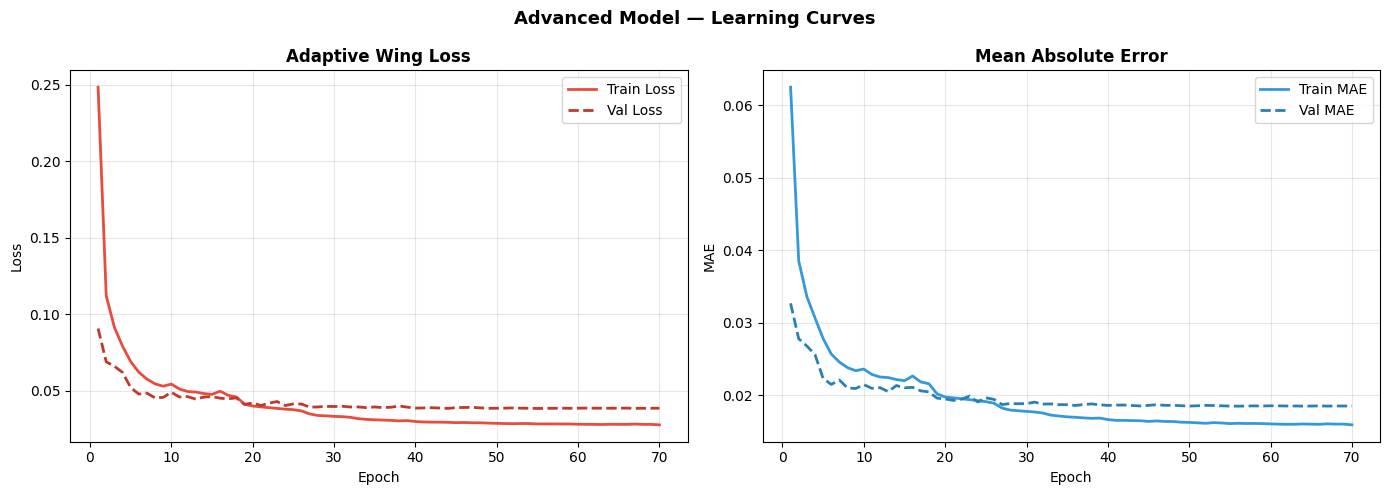

In [108]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(history_adv.history['loss']) + 1)
ax1.plot(epochs, history_adv.history['loss'],     '#e74c3c', linewidth=2, label='Train Loss')
ax1.plot(epochs, history_adv.history['val_loss'], '#c0392b', linewidth=2, linestyle='--', label='Val Loss')
ax1.set_title('Adaptive Wing Loss', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs, history_adv.history['mae'],     '#3498db', linewidth=2, label='Train MAE')
ax2.plot(epochs, history_adv.history['val_mae'], '#2980b9', linewidth=2, linestyle='--', label='Val MAE')
ax2.set_title('Mean Absolute Error', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('MAE')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('Advanced Model — Learning Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 12.7 — Đánh giá và So sánh Tất cả Models

In [109]:
# Dự đoán với advanced model
predicted_train_adv = get_predicted_points(train_images, advanced_model)
predicted_val_adv   = get_predicted_points(val_images,   advanced_model)
predicted_test_adv  = get_predicted_points(test_images,  advanced_model)

training_output_adv = build_dataframe_EFs(train_keypoints_conv, predicted_train_adv)
val_output_adv      = build_dataframe_EFs(val_keypoints_conv,   predicted_val_adv)
test_output_adv     = build_dataframe_EFs(test_keypoints_conv,  predicted_test_adv)

print("=== KET QUA ADVANCED MODEL (PHAN 12) ===")
print("Test:")
Accuracy_ConfusionMatrix(test_output_adv.Actual_HFClass, test_output_adv.Pred_HFClass, ['Normal','Mild','Abnormal'])


2026-05-10 02:16:57.342455: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 02:16:57.479516: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 02:16:57.800484: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 02:16:57.950284: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 02:16:58.735615: E external/local_xla/xla/stream_

466/466 ━━━━━━━━━━━━━━━━━━━━ 37s 44ms/step
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 103ms/step
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

2026-05-10 02:17:41.164786: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 02:17:41.301484: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 02:17:41.627661: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 02:17:41.776657: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 02:17:42.610755: E external/local_xla/xla/stream_

80/80 ━━━━━━━━━━━━━━━━━━━━ 14s 181ms/step
=== KET QUA ADVANCED MODEL (PHAN 12) ===
Test:
Accuracy of model: 0.6755485893416928
Predicted  Normal  Mild  Abnormal
Actual                           
Normal        705   157       118
Mild           49    35        42
Abnormal       22    26       122
Sensitivity of model for individual classes
Class Normal : 0.7193877551020408
Class Mild : 0.2777777777777778
Class Abnormal : 0.7176470588235294


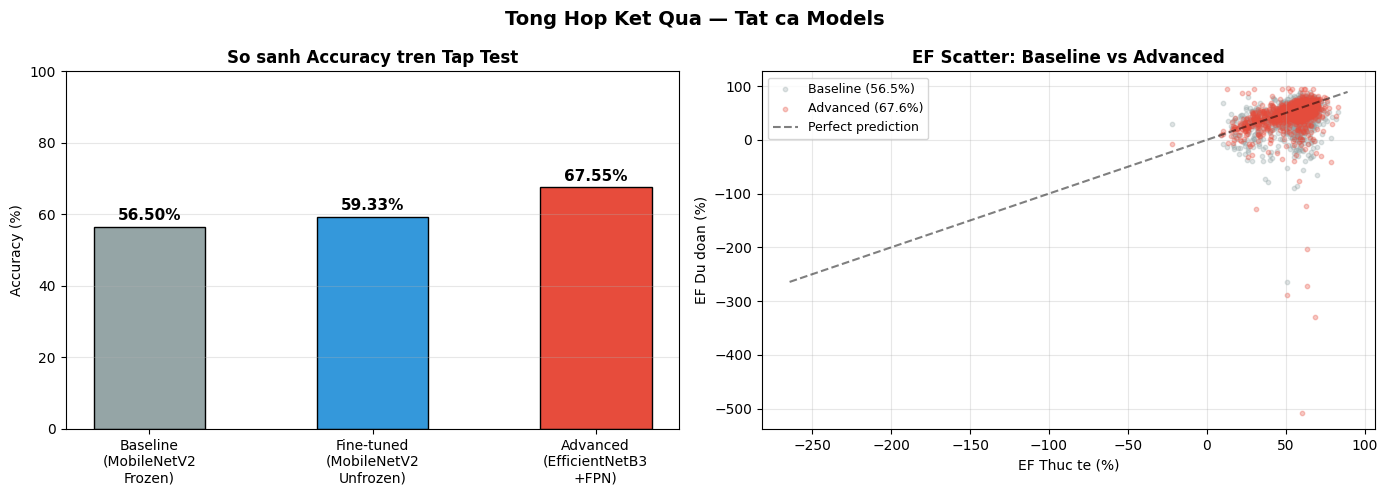


BANG TONG HOP HIEU SUAT TREN TAP TEST
Model                            Accuracy
-------------------------------------------------------
Baseline (Frozen MobileNetV2)      56.50%
Fine-tuned (Unfrozen MobileNetV2)     59.33%
Advanced (EfficientNetB3+FPN)      67.55%


In [110]:
from sklearn.metrics import accuracy_score

# So sánh tất cả models
acc_base = accuracy_score(test_output_df.Actual_HFClass,  test_output_df.Pred_HFClass)
acc_ft   = accuracy_score(test_output_ft.Actual_HFClass,  test_output_ft.Pred_HFClass)
acc_adv  = accuracy_score(test_output_adv.Actual_HFClass, test_output_adv.Pred_HFClass)

models       = ['Baseline\n(MobileNetV2\nFrozen)', 'Fine-tuned\n(MobileNetV2\nUnfrozen)', 'Advanced\n(EfficientNetB3\n+FPN)']
accuracies   = [acc_base*100, acc_ft*100, acc_adv*100]
bar_colors   = ['#95a5a6', '#3498db', '#e74c3c']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = axes[0].bar(models, accuracies, color=bar_colors, edgecolor='black', width=0.5)
axes[0].set_ylim(0, 100)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('So sanh Accuracy tren Tap Test', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

# EF scatter comparison
axes[1].scatter(test_output_df.Actual_EF,  test_output_df.Pred_EF,  alpha=0.3, s=10, c='#95a5a6', label=f'Baseline ({acc_base*100:.1f}%)')
axes[1].scatter(test_output_adv.Actual_EF, test_output_adv.Pred_EF, alpha=0.3, s=10, c='#e74c3c', label=f'Advanced ({acc_adv*100:.1f}%)')
lims = [min(test_output_df.Actual_EF.min(), test_output_df.Pred_EF.min()),
        max(test_output_df.Actual_EF.max(), test_output_df.Pred_EF.max())]
axes[1].plot(lims, lims, 'k--', alpha=0.5, label='Perfect prediction')
axes[1].set_xlabel('EF Thuc te (%)'); axes[1].set_ylabel('EF Du doan (%)')
axes[1].set_title('EF Scatter: Baseline vs Advanced', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.suptitle('Tong Hop Ket Qua — Tat ca Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n{'='*55}")
print(f"BANG TONG HOP HIEU SUAT TREN TAP TEST")
print(f"{'='*55}")
print(f"{'Model':<30} {'Accuracy':>10}")
print(f"{'-'*55}")
print(f"{'Baseline (Frozen MobileNetV2)':<30} {acc_base*100:>9.2f}%")
print(f"{'Fine-tuned (Unfrozen MobileNetV2)':<30} {acc_ft*100:>9.2f}%")
print(f"{'Advanced (EfficientNetB3+FPN)':<30} {acc_adv*100:>9.2f}%")
print(f"{'='*55}")
